# ============================================================================
# ANCHOR SELECTION - 4 CRITERIA
# Jupyter Notebook Implementation
# ============================================================================

# 1. Setup & Configuration


In [54]:
import sympy
print(sympy.__version__)
print(sympy.__file__)
import sympy.printing.str
print("OK sympy.printing.str imported")


1.13.1
C:\Users\HAI NAM\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sympy\__init__.py
OK sympy.printing.str imported


In [55]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import json
import warnings
warnings.filterwarnings('ignore')

# Set style

In [56]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [57]:
class Config:
    """Cấu hình toàn bộ pipeline"""
    
    # ===== PATHS =====
    DATA_ROOT = Path(r"D:\Blockchain fraud detection")
    RESULT_DIR = Path.cwd() / 'result5'
    
    # ===== ANCHOR SELECTION PARAMS =====
    MAX_ANCHORS = 5000          # Tổng số anchor cần chọn
    ALPHA = 1.0                 # Weight cho illicit node
    BETA = 0.5                  # Weight cho illicit neighbors
    GAMMA = 1.0                 # Multiplier cho risk score
    
    # ===== TEMPORAL SPLIT (chuẩn Elliptic) =====
    TRAIN_END = 34
    VAL_END = 41
    TEST_END = 49
    
    # ===== DEGREE BINNING =====
    N_DEGREE_BINS = 5
    DEGREE_BIN_METHOD = 'quantile'  # 'quantile' or 'equal_width'
    
    # ===== SUBGRAPH & SEQUENCE =====
    R_HOP = 2
    TIME_WINDOW = 3
    SEQ_LEN = 5
    
    # ===== OTHER =====
    SEED = 42
    LABELED_ONLY = True

config = Config()

# Create directories
config.RESULT_DIR.mkdir(exist_ok=True, parents=True)
(config.RESULT_DIR / 'graph').mkdir(exist_ok=True)
(config.RESULT_DIR / 'sequence').mkdir(exist_ok=True)

print("✓ Configuration loaded")
print(f"  Data root: {config.DATA_ROOT}")
print(f"  Result dir: {config.RESULT_DIR}")
print(f"  Max anchors: {config.MAX_ANCHORS}")

✓ Configuration loaded
  Data root: D:\Blockchain fraud detection
  Result dir: d:\Blockchain fraud detection\result5
  Max anchors: 5000


In [58]:
# ## 2.1. Load Raw Elliptic Data

# %%
def load_elliptic(data_root: Path):
    """Load Elliptic Bitcoin Dataset"""
    print("="*60)
    print("LOADING ELLIPTIC DATASET")
    print("="*60)
    
    # ===== Features =====
    print("\n1. Loading features...")
    feat = pd.read_csv(
        data_root / "elliptic_txs_features.csv", 
        header=None,
        dtype={0: str, 1: str}
    )
    feat = feat.rename(columns={0: "tx_id", 1: "time_step"})
    feat["tx_id"] = feat["tx_id"].astype(str)
    feat["time_step"] = feat["time_step"].astype(int)
    
    print(f"   Features shape: {feat.shape}")
    print(f"   Feature columns: {feat.columns.tolist()[:5]}... (total: {len(feat.columns)})")
    
    # ===== Classes =====
    print("\n2. Loading classes...")
    classes = pd.read_csv(data_root / "elliptic_txs_classes.csv")
    
    # Handle column names
    if "txId" in classes.columns:
        classes = classes.rename(columns={"txId": "tx_id"})
    
    classes["tx_id"] = classes["tx_id"].astype(str)
    
    # Map labels
    if "label" in classes.columns:
        classes["label"] = classes["label"].astype(str).map({
            "1": "illicit", 
            "2": "licit"
        }).fillna("unknown")
    else:
        classes["label"] = classes["class"].astype(str).map({
            "1": "illicit", 
            "2": "licit"
        }).fillna("unknown")
    
    print(f"   Classes shape: {classes.shape}")
    print(f"   Label distribution:")
    print(classes["label"].value_counts())
    
    # ===== Edges =====
    print("\n3. Loading edges...")
    edges = pd.read_csv(data_root / "elliptic_txs_edgelist.csv")
    edges["txId1"] = edges["txId1"].astype(str)
    edges["txId2"] = edges["txId2"].astype(str)
    
    print(f"   Edges shape: {edges.shape}")
    
    # ===== Merge =====
    print("\n4. Merging features and labels...")
    feat = feat.merge(classes[["tx_id", "label"]], on="tx_id", how="left")
    feat["label"] = feat["label"].fillna("unknown")
    
    print(f"\n✓ Final DataFrame shape: {feat.shape}")
    print(f"✓ Label distribution:")
    print(feat["label"].value_counts())
    
    return feat, classes, edges

# Load data
feat_df, classes_df, edges_df = load_elliptic(config.DATA_ROOT)

LOADING ELLIPTIC DATASET

1. Loading features...
   Features shape: (203769, 167)
   Feature columns: ['tx_id', 'time_step', 2, 3, 4]... (total: 167)

2. Loading classes...
   Classes shape: (203769, 3)
   Label distribution:
label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64

3. Loading edges...
   Edges shape: (234355, 2)

4. Merging features and labels...

✓ Final DataFrame shape: (203769, 168)
✓ Label distribution:
label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


In [59]:
# ## 2.2. Build Full Graph

# %%
def build_graph(feat_df: pd.DataFrame, edges_df: pd.DataFrame) -> nx.DiGraph:
    """Build directed graph from Elliptic data"""
    print("\n" + "="*60)
    print("BUILDING GRAPH")
    print("="*60)
    
    G = nx.DiGraph()
    
    # Add nodes
    print("\n1. Adding nodes...")
    for row in tqdm(feat_df[["tx_id", "time_step", "label"]].itertuples(index=False), 
                    total=len(feat_df), desc="Nodes"):
        G.add_node(
            int(row.tx_id),
            time_step=int(row.time_step),
            label=str(row.label)
        )
    
    # Add edges
    print("\n2. Adding edges...")
    edges_added = 0
    for row in tqdm(edges_df.itertuples(index=False), 
                    total=len(edges_df), desc="Edges"):
        a, b = int(row.txId1), int(row.txId2)
        if a in G and b in G:
            G.add_edge(a, b)
            edges_added += 1
    
    print(f"\n✓ Graph built:")
    print(f"  Nodes: {G.number_of_nodes():,}")
    print(f"  Edges: {G.number_of_edges():,}")
    print(f"  Edges added: {edges_added:,}/{len(edges_df):,}")
    
    return G

# Build graph
G = build_graph(feat_df, edges_df)


BUILDING GRAPH

1. Adding nodes...


Nodes: 100%|██████████| 203769/203769 [00:00<00:00, 359729.37it/s]



2. Adding edges...


Edges: 100%|██████████| 234355/234355 [00:01<00:00, 121092.05it/s]



✓ Graph built:
  Nodes: 203,769
  Edges: 234,355
  Edges added: 234,355/234,355


In [60]:
def filter_candidates(df: pd.DataFrame, labeled_only: bool = True) -> pd.DataFrame:
    """Lọc chỉ giữ lại node có label thật (licit/illicit)"""
    print("\n" + "="*60)
    print("FILTERING CANDIDATES")
    print("="*60)
    
    if labeled_only:
        candidates = df[df['label'].isin(['licit', 'illicit'])].copy()
        print(f"\n✓ Filtered to labeled data only")
    else:
        candidates = df.copy()
        print(f"\n✓ Using all data (including unknown)")
    
    print(f"\nCandidate statistics:")
    print(f"  Total: {len(candidates):,}")
    print(f"  Illicit: {(candidates['label']=='illicit').sum():,}")
    print(f"  Licit: {(candidates['label']=='licit').sum():,}")
    
    if not labeled_only:
        print(f"  Unknown: {(candidates['label']=='unknown').sum():,}")
    
    return candidates

# Filter candidates
candidates_df = filter_candidates(feat_df, labeled_only=config.LABELED_ONLY)

# %% [markdown]
# ## 3.2. Temporal Binning (Fix theo Split Chuẩn)

# %%
def assign_temporal_bin(t: int, train_end: int = 34, val_end: int = 41) -> int:
    """
    Chia temporal bin THEO split chuẩn Elliptic
    
    Train (1-34):  → bins 0-4 (~7 steps/bin)
    Val (35-41):   → bins 5-7 (~2-3 steps/bin)
    Test (42-49):  → bins 8-11 (~2 steps/bin)
    """
    if 1 <= t <= train_end:
        return (t - 1) // 7  # 0-4
    elif train_end < t <= val_end:
        return 5 + (t - train_end - 1) // 2  # 5-7
    else:  # t > val_end
        return 8 + (t - val_end - 1) // 2  # 8-11

def get_split(t: int, train_end: int = 34, val_end: int = 41) -> str:
    """Assign split label"""
    if t <= train_end:
        return 'train'
    elif t <= val_end:
        return 'val'
    else:
        return 'test'

def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add temporal bin and split columns"""
    print("\n" + "="*60)
    print("TEMPORAL BINNING")
    print("="*60)
    
    # Add temporal bin
    df['temporal_bin'] = df['time_step'].apply(
        lambda t: assign_temporal_bin(t, config.TRAIN_END, config.VAL_END)
    )
    
    # Add split
    df['split'] = df['time_step'].apply(
        lambda t: get_split(t, config.TRAIN_END, config.VAL_END)
    )
    
    # Verify
    print("\n✓ Temporal features added")
    print("\nTemporal Bin Distribution by Split:")
    print(df.groupby(['split', 'temporal_bin']).size().unstack(fill_value=0))
    
    print("\nSplit Statistics:")
    for split in ['train', 'val', 'test']:
        split_df = df[df['split'] == split]
        n_illicit = (split_df['label'] == 'illicit').sum()
        n_licit = (split_df['label'] == 'licit').sum()
        ratio = n_illicit / (n_licit + 1e-10)
        print(f"  {split.upper():5s}: {len(split_df):5,} samples | "
              f"Illicit: {n_illicit:4,} | Licit: {n_licit:5,} | "
              f"Ratio: {ratio:.4f}")
    
    return df

# Add temporal features
candidates_df = add_temporal_features(candidates_df)


FILTERING CANDIDATES

✓ Filtered to labeled data only

Candidate statistics:
  Total: 46,564
  Illicit: 4,545
  Licit: 42,019

TEMPORAL BINNING

✓ Temporal features added

Temporal Bin Distribution by Split:
temporal_bin    0     1     2     3     4     5     6     7     8     9   \
split                                                                      
test             0     0     0     0     0     0     0     0  3524  2812   
train         9553  5343  4634  5677  4687     0     0     0     0     0   
val              0     0     0     0     0  3049  1254  2394  1132     0   

temporal_bin    10   11  
split                    
test          1558  947  
train            0    0  
val              0    0  

Split Statistics:
  TRAIN: 29,894 samples | Illicit: 3,462 | Licit: 26,432 | Ratio: 0.1310
  VAL  : 7,829 samples | Illicit:  675 | Licit: 7,154 | Ratio: 0.0944
  TEST : 8,841 samples | Illicit:  408 | Licit: 8,433 | Ratio: 0.0484



COMPUTING DEGREES

Computing node degrees...


Degrees: 100%|██████████| 46564/46564 [00:00<00:00, 666421.80it/s]


✓ Degrees computed

Degree statistics:
count    46564.000000
mean         2.989455
std          7.732555
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max        473.000000
Name: degree, dtype: float64

DEGREE DISTRIBUTION ANALYSIS

1. Degree Statistics by Label:
           count      mean       std  min  25%  50%  75%    max
label                                                          
illicit   4545.0  2.011661  7.177521  1.0  1.0  1.0  2.0  177.0
licit    42019.0  3.095219  7.782942  1.0  1.0  2.0  3.0  473.0

2. Skewness: 17.45
   → Highly skewed! Recommend QUANTILE binning

3. Creating visualizations...



✓ Saved: d:\Blockchain fraud detection\result5\degree_analysis.png


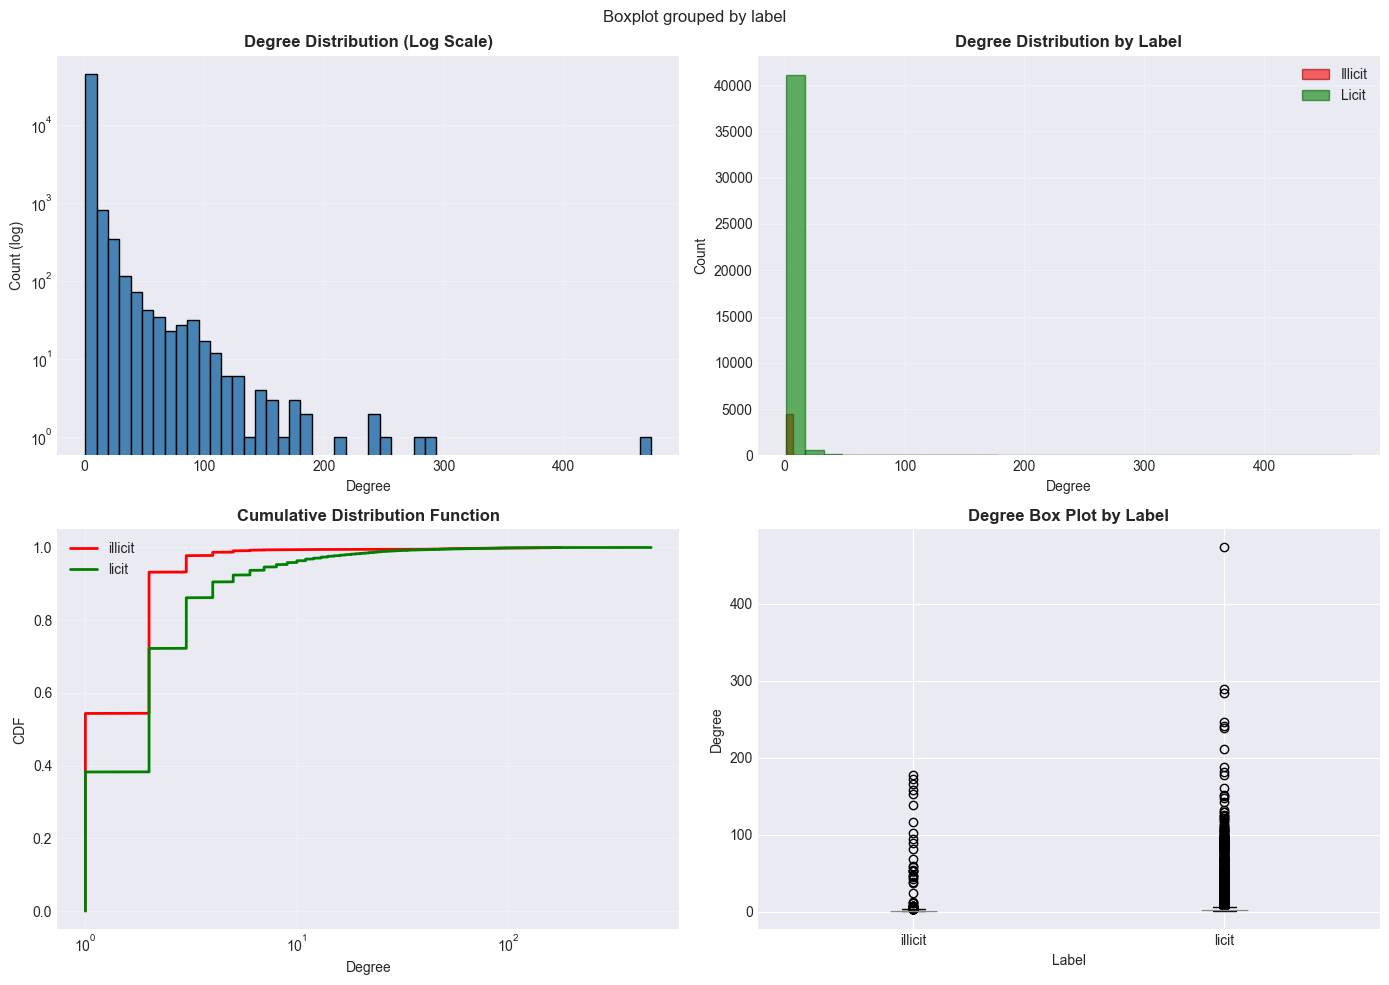


DEGREE BINNING: QUANTILE

✓ Applied QUANTILE binning with 5 bins

Degree Bin Distribution by Label:
degree_bin      0     1     2
label                        
illicit      4236   207   102
licit       30349  5858  5812

✓ Saved: d:\Blockchain fraud detection\result5\degree_bins.png


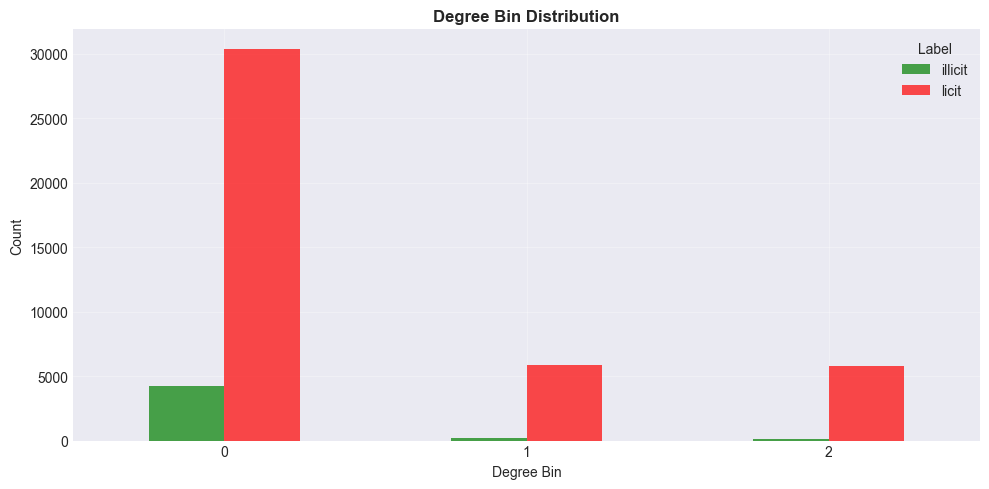

In [61]:
# ## 3.3. Degree Analysis & Binning

# %%
def compute_degrees(df: pd.DataFrame, G: nx.Graph) -> pd.DataFrame:
    """Tính degree cho mỗi node"""
    print("\n" + "="*60)
    print("COMPUTING DEGREES")
    print("="*60)
    
    print("\nComputing node degrees...")
    degrees = []
    for tx_id in tqdm(df['tx_id'], desc="Degrees"):
        node_id = int(tx_id)
        if G.has_node(node_id):
            degrees.append(G.degree(node_id))
        else:
            degrees.append(1)  # Default degree
    
    df['degree'] = degrees
    
    print(f"\n✓ Degrees computed")
    print(f"\nDegree statistics:")
    print(df['degree'].describe())
    
    return df

# Compute degrees
candidates_df = compute_degrees(candidates_df, G)

# %%
def analyze_degree_distribution(df: pd.DataFrame, save_path: str = 'degree_analysis.png'):
    """Phân tích và visualize degree distribution"""
    print("\n" + "="*60)
    print("DEGREE DISTRIBUTION ANALYSIS")
    print("="*60)
    
    # ===== Statistics =====
    print("\n1. Degree Statistics by Label:")
    print(df.groupby('label')['degree'].describe())
    
    # ===== Skewness =====
    skewness = df['degree'].skew()
    print(f"\n2. Skewness: {skewness:.2f}")
    
    if skewness > 2:
        print("   → Highly skewed! Recommend QUANTILE binning")
        recommended_method = 'quantile'
    else:
        print("   → Moderate skew. Can use EQUAL_WIDTH binning")
        recommended_method = 'equal_width'
    
    # ===== Visualization =====
    print("\n3. Creating visualizations...")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Overall histogram (log scale)
    ax = axes[0, 0]
    df['degree'].hist(bins=50, ax=ax, edgecolor='black', log=True, color='steelblue')
    ax.set_title('Degree Distribution (Log Scale)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Degree')
    ax.set_ylabel('Count (log)')
    ax.grid(alpha=0.3)
    
    # Plot 2: By label (linear scale)
    ax = axes[0, 1]
    df[df['label']=='illicit']['degree'].hist(
        bins=30, alpha=0.6, label='Illicit', ax=ax, color='red', edgecolor='darkred'
    )
    df[df['label']=='licit']['degree'].hist(
        bins=30, alpha=0.6, label='Licit', ax=ax, color='green', edgecolor='darkgreen'
    )
    ax.set_title('Degree Distribution by Label', fontsize=12, fontweight='bold')
    ax.set_xlabel('Degree')
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Plot 3: CDF
    ax = axes[1, 0]
    for label, color in [('illicit', 'red'), ('licit', 'green')]:
        sorted_deg = np.sort(df[df['label']==label]['degree'])
        cdf = np.arange(1, len(sorted_deg)+1) / len(sorted_deg)
        ax.plot(sorted_deg, cdf, label=label, color=color, linewidth=2)
    ax.set_title('Cumulative Distribution Function', fontsize=12, fontweight='bold')
    ax.set_xlabel('Degree')
    ax.set_ylabel('CDF')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xscale('log')
    
    # Plot 4: Box plot by label
    ax = axes[1, 1]
    df.boxplot(column='degree', by='label', ax=ax)
    ax.set_title('Degree Box Plot by Label', fontsize=12, fontweight='bold')
    ax.set_xlabel('Label')
    ax.set_ylabel('Degree')
    plt.sca(ax)
    plt.xticks(rotation=0)
    
    plt.tight_layout()
    save_path = config.RESULT_DIR / save_path
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved: {save_path}")
    plt.show()
    
    return recommended_method

# Analyze degree distribution
recommended_bin_method = analyze_degree_distribution(candidates_df)

# %%
def apply_degree_binning(df: pd.DataFrame, method: str = 'quantile', n_bins: int = 5) -> pd.DataFrame:
    """Apply degree binning"""
    print("\n" + "="*60)
    print(f"DEGREE BINNING: {method.upper()}")
    print("="*60)
    
    if method == 'quantile':
        try:
            df['degree_bin'] = pd.qcut(
                df['degree'], 
                q=n_bins, 
                labels=False, 
                duplicates='drop'
            )
            print(f"\n✓ Applied QUANTILE binning with {n_bins} bins")
        except ValueError as e:
            print(f"\n⚠ Quantile binning failed: {e}")
            print("  Falling back to equal_width binning...")
            df['degree_bin'] = pd.cut(df['degree'], bins=n_bins, labels=False)
    else:
        df['degree_bin'] = pd.cut(df['degree'], bins=n_bins, labels=False)
        print(f"\n✓ Applied EQUAL_WIDTH binning with {n_bins} bins")
    
    # Check distribution
    print("\nDegree Bin Distribution by Label:")
    bin_dist = df.groupby(['label', 'degree_bin']).size().unstack(fill_value=0)
    print(bin_dist)
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 5))
    bin_dist.T.plot(kind='bar', ax=ax, color=['green', 'red'], alpha=0.7)
    ax.set_title('Degree Bin Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Degree Bin')
    ax.set_ylabel('Count')
    ax.legend(title='Label')
    ax.grid(alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(config.RESULT_DIR / 'degree_bins.png', dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved: {config.RESULT_DIR / 'degree_bins.png'}")
    plt.show()
    
    return df

# Apply degree binning
candidates_df = apply_degree_binning(
    candidates_df, 
    method=config.DEGREE_BIN_METHOD,
    n_bins=config.N_DEGREE_BINS
)


COMPUTING RISK SCORES
Parameters: α=1.0, β=0.5


Computing risk: 100%|██████████| 46564/46564 [00:01<00:00, 26812.65it/s]



✓ Risk scores computed

Risk Score Statistics by Label:
           count          mean           std  min  25%  50%  75%           max
label                                                                         
illicit   4545.0  9.537954e+08  1.984219e+09  1.0  1.0  1.0  1.0  1.000000e+10
licit    42019.0  4.581261e+07  4.935881e+08  0.0  0.0  0.0  0.0  1.000000e+10

✓ Saved: d:\Blockchain fraud detection\result5\risk_scores.png


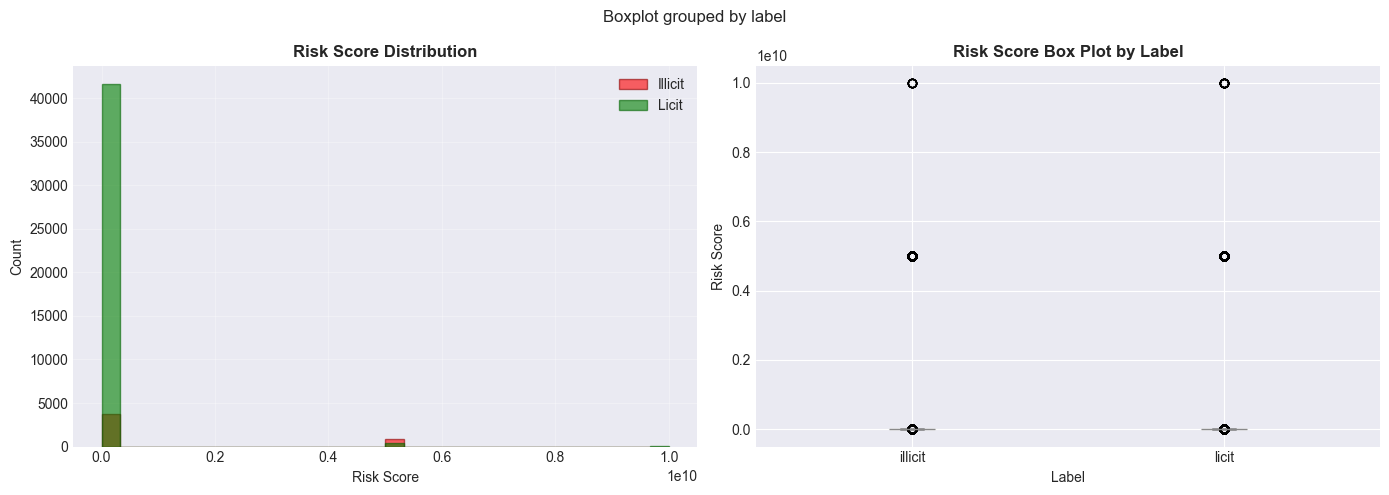

In [62]:
# ## 3.4. Risk Score Computation

# %%
def compute_risk_scores(df: pd.DataFrame, G: nx.Graph, alpha: float = 1.0, beta: float = 0.5) -> pd.DataFrame:
    """
    Tính risk score theo công thức:
    risk(v) = α * 1[v=illicit] + β * (illicit_neighbors / licit_neighbors)
    """
    print("\n" + "="*60)
    print("COMPUTING RISK SCORES")
    print("="*60)
    print(f"Parameters: α={alpha}, β={beta}")
    
    risk_scores = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Computing risk"):
        tx_id = int(row['tx_id'])
        
        # Term 1: bản thân node có illicit không
        is_illicit = 1.0 if row['label'] == 'illicit' else 0.0
        
        # Term 2: tỷ lệ hàng xóm illicit
        if not G.has_node(tx_id):
            neighbor_risk = 0.0
        else:
            neighbors = list(G.neighbors(tx_id))
            
            if len(neighbors) == 0:
                neighbor_risk = 0.0
            else:
                illicit_count = 0
                licit_count = 0
                
                for neighbor in neighbors:
                    neighbor_label = G.nodes[neighbor].get('label', 'unknown')
                    if neighbor_label == 'illicit':
                        illicit_count += 1
                    elif neighbor_label == 'licit':
                        licit_count += 1
                
                # Tránh chia 0
                neighbor_risk = illicit_count / (licit_count + 1e-10)
        
        risk = alpha * is_illicit + beta * neighbor_risk
        risk_scores.append(risk)
    
    df['risk_score'] = risk_scores
    
    # ===== Statistics =====
    print("\n✓ Risk scores computed")
    print("\nRisk Score Statistics by Label:")
    print(df.groupby('label')['risk_score'].describe())
    
    # ===== Visualization =====
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Histogram
    ax = axes[0]
    df[df['label']=='illicit']['risk_score'].hist(
        bins=30, alpha=0.6, label='Illicit', ax=ax, color='red', edgecolor='darkred'
    )
    df[df['label']=='licit']['risk_score'].hist(
        bins=30, alpha=0.6, label='Licit', ax=ax, color='green', edgecolor='darkgreen'
    )
    ax.set_title('Risk Score Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Risk Score')
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Plot 2: Box plot
    ax = axes[1]
    df.boxplot(column='risk_score', by='label', ax=ax)
    ax.set_title('Risk Score Box Plot by Label', fontsize=12, fontweight='bold')
    ax.set_xlabel('Label')
    ax.set_ylabel('Risk Score')
    plt.sca(ax)
    plt.xticks(rotation=0)
    
    plt.tight_layout()
    plt.savefig(config.RESULT_DIR / 'risk_scores.png', dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved: {config.RESULT_DIR / 'risk_scores.png'}")
    plt.show()
    
    return df

# Compute risk scores
candidates_df = compute_risk_scores(candidates_df, G, alpha=config.ALPHA, beta=config.BETA)


COMPUTING ANCHOR WEIGHTS
Parameter: γ=1.0

Processing LICIT class...

Processing ILLICIT class...

✓ Anchor weights computed

Weight Statistics:

w_time:
           count      mean       std       min       25%       50%       75%  \
label                                                                          
illicit   4545.0  0.002640  0.004316  0.001087  0.001155  0.001229  0.002639   
licit    42019.0  0.000286  0.000205  0.000107  0.000200  0.000234  0.000353   

              max  
label              
illicit  0.041667  
licit    0.001170  

w_struct:
           count      mean       std       min       25%       50%       75%  \
label                                                                          
illicit   4545.0  0.000660  0.001684  0.000236  0.000236  0.000236  0.000236   
licit    42019.0  0.000071  0.000062  0.000033  0.000033  0.000033  0.000171   

              max  
label              
illicit  0.009804  
licit    0.000172  

w_risk:
           count      m

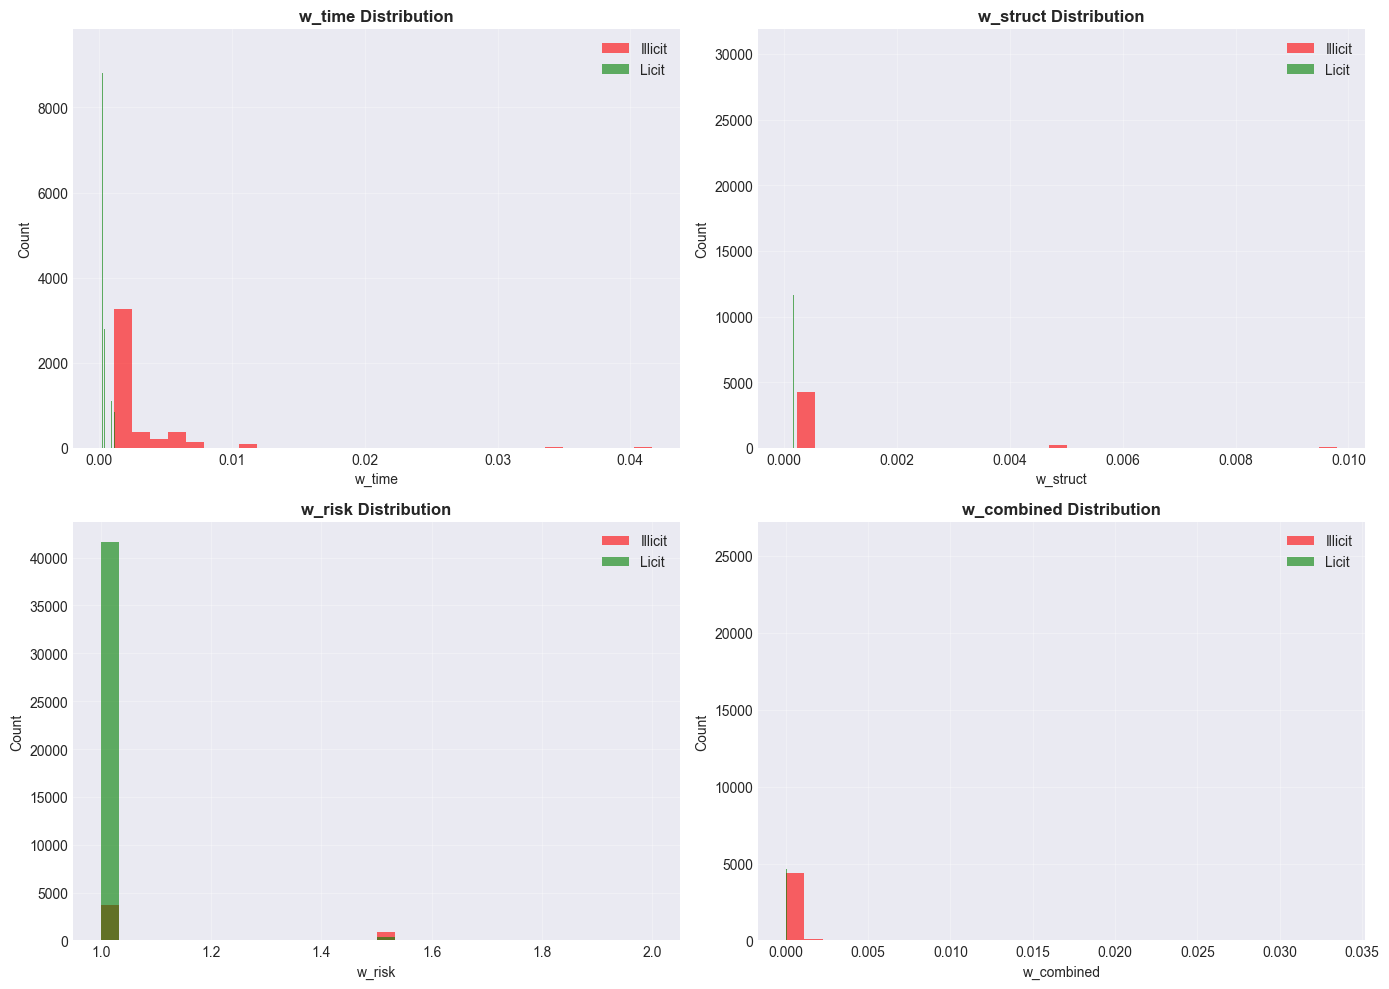

In [63]:
# ## 3.5. Compute 4 Anchor Weights

# %%
def compute_anchor_weights(df: pd.DataFrame, gamma: float = 1.0) -> pd.DataFrame:
    """
    Tính 4 trọng số:
    1. w_time: inverse frequency của temporal_bin
    2. w_struct: inverse frequency của degree_bin
    3. w_risk: 1 + γ * normalized_risk
    4. w_combined: product của 3 cái trên
    """
    print("\n" + "="*60)
    print("COMPUTING ANCHOR WEIGHTS")
    print("="*60)
    print(f"Parameter: γ={gamma}")
    
    # Tính riêng cho từng class
    for label in ['licit', 'illicit']:
        print(f"\nProcessing {label.upper()} class...")
        mask = df['label'] == label
        class_df = df[mask]
        
        # ===== W1: Temporal weight =====
        temporal_counts = class_df['temporal_bin'].value_counts()
        df.loc[mask, 'w_time'] = df.loc[mask, 'temporal_bin'].map(
            lambda x: 1.0 / temporal_counts.get(x, 1)
        )
        
        # ===== W2: Structural weight =====
        degree_counts = class_df['degree_bin'].value_counts()
        df.loc[mask, 'w_struct'] = df.loc[mask, 'degree_bin'].map(
            lambda x: 1.0 / degree_counts.get(x, 1)
        )
        
        # ===== W3: Risk weight =====
        risk_min = class_df['risk_score'].min()
        risk_max = class_df['risk_score'].max()
        risk_range = risk_max - risk_min
        
        if risk_range > 1e-10:
            risk_norm = (class_df['risk_score'] - risk_min) / risk_range
        else:
            risk_norm = pd.Series(0.5, index=class_df.index)
        
        df.loc[mask, 'w_risk'] = 1.0 + gamma * risk_norm
    
    # ===== W_combined =====
    df['w_combined'] = df['w_time'] * df['w_struct'] * df['w_risk']
    
    # Normalize w_combined trong từng class về sum=1
    for label in ['licit', 'illicit']:
        mask = df['label'] == label
        total = df.loc[mask, 'w_combined'].sum()
        if total > 0:
            df.loc[mask, 'w_combined'] /= total
    
    # ===== Statistics =====
    print("\n✓ Anchor weights computed")
    print("\nWeight Statistics:")
    
    for col in ['w_time', 'w_struct', 'w_risk', 'w_combined']:
        print(f"\n{col}:")
        stats = df.groupby('label')[col].describe()
        print(stats)
    
    # ===== Visualization =====
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    weight_cols = ['w_time', 'w_struct', 'w_risk', 'w_combined']
    
    for idx, col in enumerate(weight_cols):
        ax = axes[idx // 2, idx % 2]
        
        df[df['label']=='illicit'][col].hist(
            bins=30, alpha=0.6, label='Illicit', ax=ax, color='red'
        )
        df[df['label']=='licit'][col].hist(
            bins=30, alpha=0.6, label='Licit', ax=ax, color='green'
        )
        
        ax.set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        ax.legend()
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(config.RESULT_DIR / 'anchor_weights.png', dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved: {config.RESULT_DIR / 'anchor_weights.png'}")
    plt.show()
    
    return df

# Compute anchor weights
candidates_df = compute_anchor_weights(candidates_df, gamma=config.GAMMA)


BALANCED ANCHOR SAMPLING
Target: 5,000 anchors

LICIT:
  Available: 42,019
  Sampling: 2,500

ILLICIT:
  Available: 4,545
  Sampling: 2,500

FINAL ANCHOR SET

Total anchors: 5,000
Illicit: 2,500
Licit: 2,500

Distribution by Split:
split
train    2749
val      1201
test     1050
Name: count, dtype: int64

Distribution by Split and Label:
label  illicit  licit
split                
test       324    726
train     1609   1140
val        567    634

✓ Saved: d:\Blockchain fraud detection\result5\anchor_sampling.png


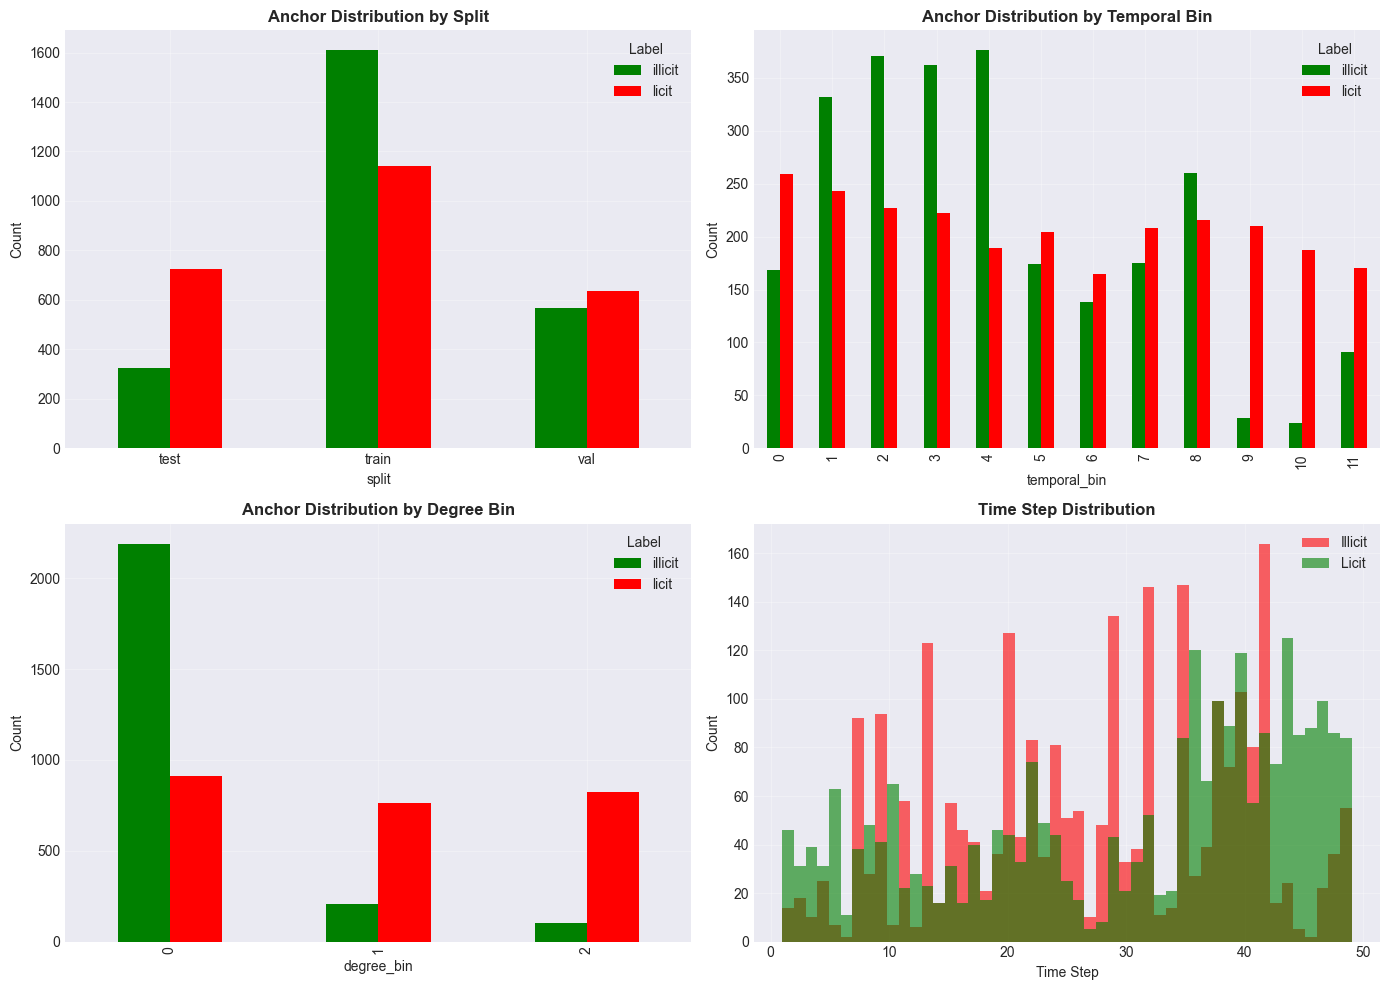

In [64]:
# ## 3.6. Balanced Anchor Sampling

# %%
def balanced_anchor_sampling(df: pd.DataFrame, K_total: int = 5000, seed: int = 42) -> pd.DataFrame:
    """
    Chọn K anchor cân bằng illicit/licit
    Sample theo w_combined (xác suất)
    """
    print("\n" + "="*60)
    print("BALANCED ANCHOR SAMPLING")
    print("="*60)
    print(f"Target: {K_total:,} anchors")
    
    # Chia đều cho 2 class
    K_per_class = K_total // 2
    
    anchor_list = []
    
    for label in ['licit', 'illicit']:
        class_df = df[df['label'] == label].copy()
        
        n_available = len(class_df)
        n_sample = min(K_per_class, n_available)
        
        print(f"\n{label.upper()}:")
        print(f"  Available: {n_available:,}")
        print(f"  Sampling: {n_sample:,}")
        
        # Sample theo w_combined
        sampled = class_df.sample(
            n=n_sample,
            weights='w_combined',
            replace=False,
            random_state=seed
        )
        
        anchor_list.append(sampled)
    
    # Combine
    anchor_df = pd.concat(anchor_list, ignore_index=True)
    
    # ===== Final Statistics =====
    print("\n" + "="*60)
    print("FINAL ANCHOR SET")
    print("="*60)
    
    print(f"\nTotal anchors: {len(anchor_df):,}")
    print(f"Illicit: {(anchor_df['label']=='illicit').sum():,}")
    print(f"Licit: {(anchor_df['label']=='licit').sum():,}")
    
    print("\nDistribution by Split:")
    print(anchor_df['split'].value_counts())
    
    print("\nDistribution by Split and Label:")
    print(anchor_df.groupby(['split', 'label']).size().unstack(fill_value=0))
    
    # ===== Visualization =====
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Split distribution
    ax = axes[0, 0]
    anchor_df.groupby(['split', 'label']).size().unstack().plot(kind='bar', ax=ax, color=['green', 'red'])
    ax.set_title('Anchor Distribution by Split', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.legend(title='Label')
    ax.grid(alpha=0.3)
    plt.sca(ax)
    plt.xticks(rotation=0)
    
    # Plot 2: Temporal bin distribution
    ax = axes[0, 1]
    anchor_df.groupby(['temporal_bin', 'label']).size().unstack().plot(kind='bar', ax=ax, color=['green', 'red'])
    ax.set_title('Anchor Distribution by Temporal Bin', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.legend(title='Label')
    ax.grid(alpha=0.3)
    
    # Plot 3: Degree bin distribution
    ax = axes[1, 0]
    anchor_df.groupby(['degree_bin', 'label']).size().unstack().plot(kind='bar', ax=ax, color=['green', 'red'])
    ax.set_title('Anchor Distribution by Degree Bin', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.legend(title='Label ')
    ax.grid(alpha=0.3)
    # Plot 4: Time step distribution
    ax = axes[1, 1]
    anchor_df[anchor_df['label']=='illicit']['time_step'].hist(bins=49, alpha=0.6, label='Illicit', ax=ax, color='red')
    anchor_df[anchor_df['label']=='licit']['time_step'].hist(bins=49, alpha=0.6, label='Licit', ax=ax, color='green')
    ax.set_title('Time Step Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(config.RESULT_DIR / 'anchor_sampling.png', dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved: {config.RESULT_DIR / 'anchor_sampling.png'}")
    plt.show()

    return anchor_df
anchor_df = balanced_anchor_sampling(candidates_df, K_total=config.MAX_ANCHORS, seed=config.SEED)

In [65]:
def save_anchor_metadata(anchor_df: pd.DataFrame, filename: str = 'anchor_list.csv'):
    """Save anchor list với metadata"""

    print("\n" + "="*60)
    print("SAVING ANCHOR METADATA")
    print("="*60)

    # Select columns
    anchor_meta = anchor_df[
        [
            'tx_id', 'time_step', 'label', 'split',
            'temporal_bin', 'degree', 'degree_bin',
            'risk_score', 'w_time', 'w_struct', 'w_risk', 'w_combined'
        ]
    ].copy()

    # Add id_anchor column
    anchor_meta.insert(
        0,
        'id_anchor',
        anchor_meta['tx_id'].apply(lambda x: f"btc_tx_{int(x)}")
    )

    # Save CSV
    save_path = config.RESULT_DIR / filename
    anchor_meta.to_csv(save_path, index=False)

    print(f"\n✓ Saved anchor list: {save_path}")
    print(f"  Total rows: {len(anchor_meta):,}")

    # Save detailed stats
    stats_file = config.RESULT_DIR / 'anchor_stats.txt'
    with open(stats_file, 'w', encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write("ANCHOR SELECTION STATISTICS\n")
        f.write("="*80 + "\n\n")

        f.write(f"Total Anchors: {len(anchor_meta):,}\n")
        f.write(f"Illicit: {(anchor_meta['label'] == 'illicit').sum():,}\n")
        f.write(f"Licit: {(anchor_meta['label'] == 'licit').sum():,}\n\n")

        f.write("Distribution by Split:\n")
        f.write(str(anchor_meta['split'].value_counts()) + "\n\n")

        f.write("Distribution by Split and Label:\n")
        f.write(
            str(
                anchor_meta
                .groupby(['split', 'label'])
                .size()
                .unstack(fill_value=0)
            ) + "\n\n"
        )

        f.write("Temporal Bin Distribution:\n")
        f.write(str(anchor_meta.groupby(['split', 'temporal_bin']).size()) + "\n\n")

        f.write("Degree Bin Distribution:\n")
        f.write(str(anchor_meta.groupby(['label', 'degree_bin']).size()) + "\n\n")

        f.write("Risk Score Stats:\n")
        f.write(str(anchor_meta.groupby('label')['risk_score'].describe()) + "\n\n")

        f.write("Weight Stats:\n")
        for col in ['w_time', 'w_struct', 'w_risk', 'w_combined']:
            f.write(f"\n{col}:\n")
            f.write(str(anchor_meta.groupby('label')[col].describe()) + "\n")

    print(f"✓ Saved detailed stats: {stats_file}")

    return anchor_meta


In [66]:
anchor_meta = save_anchor_metadata(anchor_df, 'anchor_list.csv')

print("\n" + "="*60)
print("SAMPLE ANCHOR DATA")
print("="*60)
print(anchor_meta.head(10))



SAVING ANCHOR METADATA

✓ Saved anchor list: d:\Blockchain fraud detection\result5\anchor_list.csv
  Total rows: 5,000
✓ Saved detailed stats: d:\Blockchain fraud detection\result5\anchor_stats.txt

SAMPLE ANCHOR DATA
          id_anchor      tx_id  time_step  label  split  temporal_bin  degree  \
0  btc_tx_163823030  163823030         29  licit  train             4       3   
1    btc_tx_3311935    3311935         48  licit   test            11       1   
2   btc_tx_73230565   73230565         42  licit   test             8       1   
3  btc_tx_149168097  149168097         39  licit    val             7      34   
4  btc_tx_349684229  349684229         12  licit  train             1       2   
5  btc_tx_322440936  322440936         12  licit  train             1       1   
6  btc_tx_225688593  225688593          5  licit  train             0       6   
7   btc_tx_87732051   87732051         46  licit   test            10       3   
8  btc_tx_148814759  148814759         39  licit    

In [67]:
def create_triview_meta(anchor_df: pd.DataFrame):
    """Tạo meta.csv cho tri-view construction"""

    print("\n" + "="*60)
    print("CREATING TRI-VIEW META")
    print("="*60)

    meta_rows = []
    for row in anchor_df.itertuples(index=False):
        meta_rows.append({
            "id_anchor": f"btc_tx_{int(row.tx_id)}",
            "chain": "BTC",
            "anchor_type": "transaction",
            "t_anchor": int(row.time_step),
            "label": str(row.label)
        })

    meta_df = pd.DataFrame(meta_rows)

    meta_path = config.RESULT_DIR / "meta.csv"
    meta_df.to_csv(meta_path, index=False)

    print(f"\n✓ Saved meta.csv: {meta_path}")
    print(f"  Total rows: {len(meta_df):,}")
    print("\nSample rows:")
    print(meta_df.head())

    return meta_df


In [68]:
meta_df = create_triview_meta(anchor_df)



CREATING TRI-VIEW META

✓ Saved meta.csv: d:\Blockchain fraud detection\result5\meta.csv
  Total rows: 5,000

Sample rows:
          id_anchor chain  anchor_type  t_anchor  label
0  btc_tx_163823030   BTC  transaction        29  licit
1    btc_tx_3311935   BTC  transaction        48  licit
2   btc_tx_73230565   BTC  transaction        42  licit
3  btc_tx_149168097   BTC  transaction        39  licit
4  btc_tx_349684229   BTC  transaction        12  licit


In [69]:
def compare_anchor_vs_full(anchor_df: pd.DataFrame, full_df: pd.DataFrame):
    """So sánh phân phối anchor vs full dataset"""

    print("\n" + "="*60)
    print("COMPARISON: ANCHOR VS FULL DATASET")
    print("="*60)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # ===== Illicit =====
    for col, ax in zip(
        ['time_step', 'degree', 'risk_score'],
        axes[0]
    ):
        full_df[full_df['label'] == 'illicit'][col].hist(
            alpha=0.3, bins=30, ax=ax, label='Full Illicit'
        )
        anchor_df[anchor_df['label'] == 'illicit'][col].hist(
            alpha=0.6, bins=30, ax=ax, label='Anchor Illicit'
        )
        ax.set_title(f'{col}: Illicit')
        ax.legend()
        ax.grid(alpha=0.3)
        if col == 'degree':
            ax.set_yscale('log')

    # ===== Licit =====
    for col, ax in zip(
        ['time_step', 'degree'],
        axes[1][:2]
    ):
        full_df[full_df['label'] == 'licit'][col].hist(
            alpha=0.3, bins=30, ax=ax, label='Full Licit'
        )
        anchor_df[anchor_df['label'] == 'licit'][col].hist(
            alpha=0.6, bins=30, ax=ax, label='Anchor Licit'
        )
        ax.set_title(f'{col}: Licit')
        ax.legend()
        ax.grid(alpha=0.3)
        if col == 'degree':
            ax.set_yscale('log')

    # ===== Summary =====
    axes[1][2].axis('off')

    summary = f"""
FULL DATASET:
  Total: {len(full_df):,}
  Illicit: {(full_df['label']=='illicit').sum():,}
  Licit: {(full_df['label']=='licit').sum():,}

ANCHORS:
  Total: {len(anchor_df):,}
  Illicit: {(anchor_df['label']=='illicit').sum():,}
  Licit: {(anchor_df['label']=='licit').sum():,}
"""
    axes[1][2].text(
        0.05, 0.5, summary,
        fontsize=10,
        fontfamily='monospace',
        bbox=dict(boxstyle='round', alpha=0.3)
    )

    plt.tight_layout()
    save_path = config.RESULT_DIR / 'anchor_vs_full_comparison.png'
    plt.savefig(save_path, dpi=150)
    plt.show()

    print(f"\n✓ Saved: {save_path}")



COMPARISON: ANCHOR VS FULL DATASET


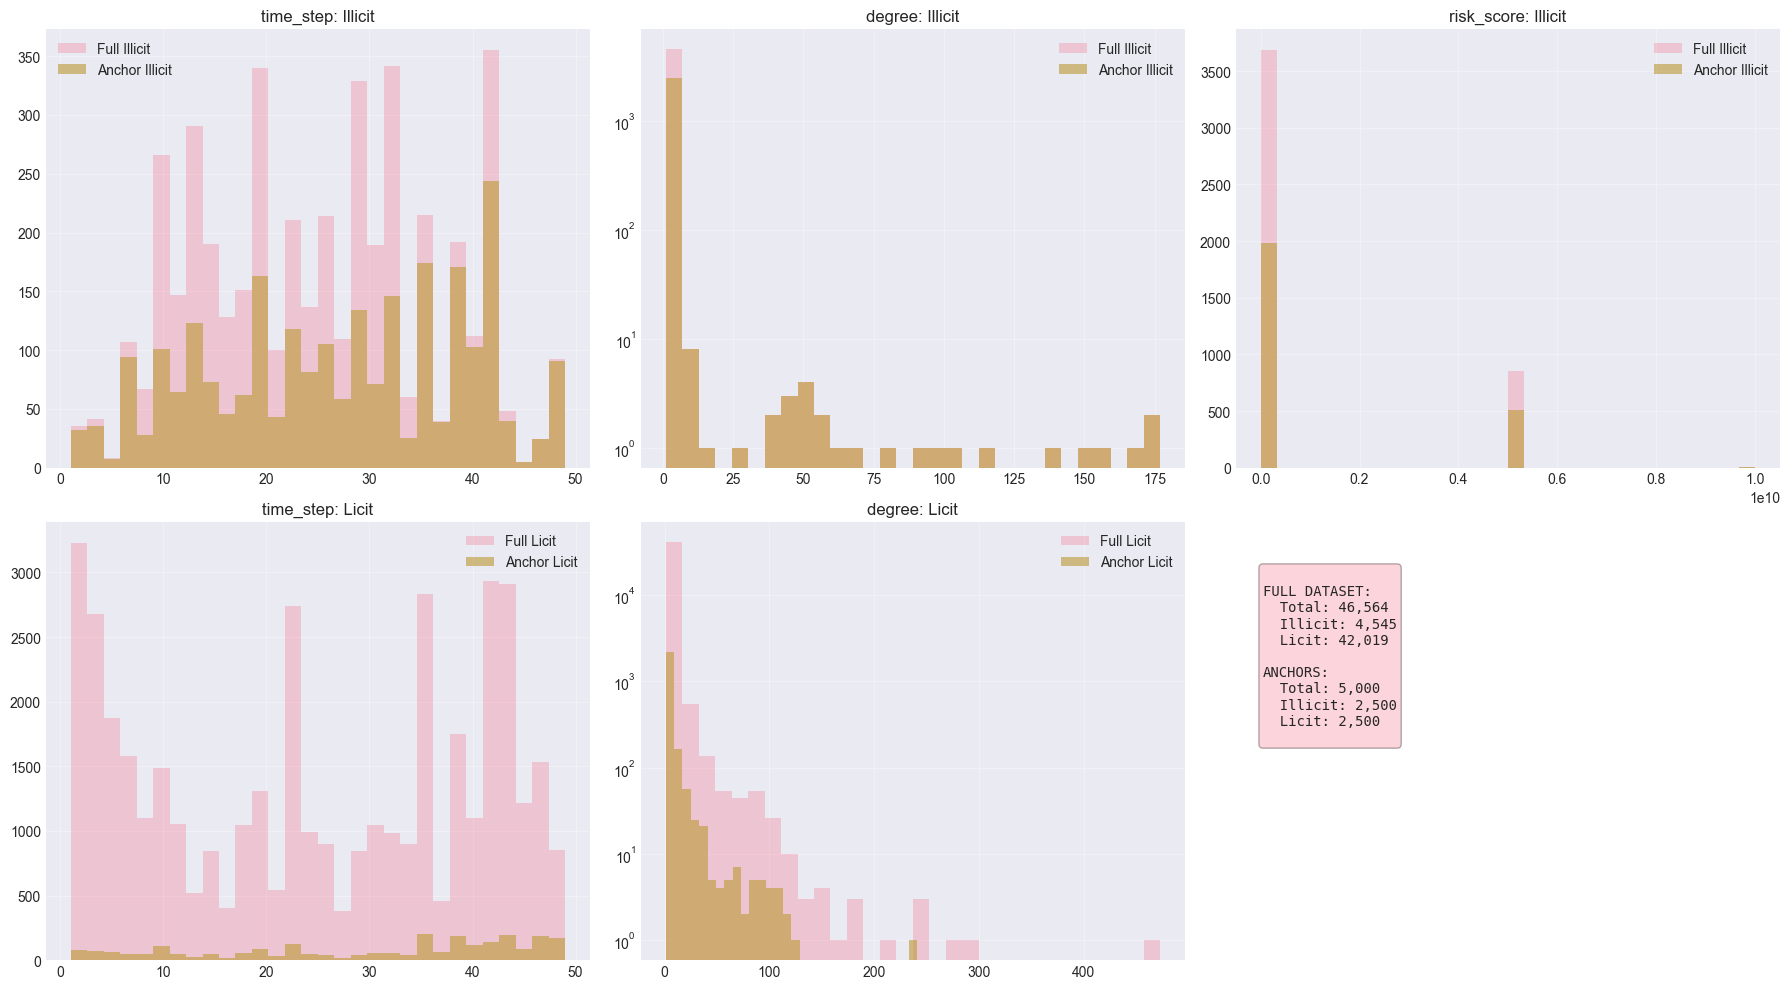


✓ Saved: d:\Blockchain fraud detection\result5\anchor_vs_full_comparison.png


In [70]:
compare_anchor_vs_full(anchor_df, candidates_df)


## XGB

In [71]:
# %% [markdown]
# ## 5.1.1. Load Anchor Metadata & Features

# anchor_meta: từ bước Save Results
# feat_df    : tabular features theo tx_id

tab_df = anchor_meta.merge(
    feat_df,
    on='tx_id',
    how='left'
)

print(f"Total anchors: {len(tab_df):,}")
print("Missing feature rows:", tab_df.isna().any(axis=1).sum())



Total anchors: 5,000
Missing feature rows: 0


In [72]:
print(tab_df.columns.tolist())


['id_anchor', 'tx_id', 'time_step_x', 'label_x', 'split', 'temporal_bin', 'degree', 'degree_bin', 'risk_score', 'w_time', 'w_struct', 'w_risk', 'w_combined', 'time_step_y', 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 'label_y']


In [73]:
# Giữ label đúng
tab_df = tab_df.rename(columns={
    'label_x': 'label',
    'time_step_x': 'time_step'
})

# Drop cột dư
tab_df = tab_df.drop(columns=[
    'label_y',
    'time_step_y'
])


In [74]:
tab_df['y'] = (tab_df['label'] == 'illicit').astype(int)

tab_df[['label', 'y']].value_counts()


label    y
illicit  1    2500
licit    0    2500
Name: count, dtype: int64

In [75]:
assert 'label' in tab_df.columns
assert 'split' in tab_df.columns
assert 'y' in tab_df.columns
assert tab_df['y'].isin([0,1]).all()

tab_df[['split', 'label']].value_counts()


split  label  
train  illicit    1609
       licit      1140
test   licit       726
val    licit       634
       illicit     567
test   illicit     324
Name: count, dtype: int64

In [76]:
# %% [markdown]
# ## 5.1.3 Feature Selection

NON_FEATURE_COLS = [
    'id_anchor',
    'tx_id',
    'label',
    'y',
    'split',
    'time_step',
    'temporal_bin',
    'degree_bin'
]

FEATURE_COLS = [
    c for c in tab_df.columns
    if c not in NON_FEATURE_COLS
    and isinstance(c, (int, np.integer))  # features 2..166
]

print(f"Total tabular features: {len(FEATURE_COLS)}")
FEATURE_COLS[:10]


Total tabular features: 165


[2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

In [77]:
# %% [markdown]
# ## 5.1.4 Use Existing Split

def get_split(df, split):
    X = df[df['split'] == split][FEATURE_COLS]
    y = df[df['split'] == split]['y']
    return X, y

X_train, y_train = get_split(tab_df, 'train')
X_val,   y_val   = get_split(tab_df, 'val')
X_test,  y_test  = get_split(tab_df, 'test')

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)


Train: (2749, 165)
Val:   (1201, 165)
Test:  (1050, 165)


In [78]:
# %% [markdown]
# ## 5.1.5 XGBoost Model

import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    n_jobs=-1
)


In [79]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score


In [80]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val, label=y_val)
dtest  = xgb.DMatrix(X_test, label=y_test)


In [81]:
params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "max_depth": 6,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42,
    "nthread": -1
}


In [82]:
evals = [
    (dtrain, "train"),
    (dval, "val")
]

xgb_model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=500,
    evals=evals,
    early_stopping_rounds=30,
    verbose_eval=50
)


[0]	train-auc:0.98309	val-auc:0.93935
[50]	train-auc:0.99963	val-auc:0.97277
[100]	train-auc:0.99999	val-auc:0.97499
[125]	train-auc:1.00000	val-auc:0.97504


In [83]:
print("Best iteration:", xgb_model.best_iteration)
print("Best AUC:", xgb_model.best_score)


Best iteration: 95
Best AUC: 0.9751834604621145


In [84]:
y_val_pred  = xgb_model.predict(dval)
y_test_pred = xgb_model.predict(dtest)

val_auc  = roc_auc_score(y_val, y_val_pred)
test_auc = roc_auc_score(y_test, y_test_pred)

print(f"VAL  AUC: {val_auc:.4f}")
print(f"TEST AUC: {test_auc:.4f}")


VAL  AUC: 0.9750
TEST AUC: 0.8559


In [85]:
tab_df.loc[tab_df['split'] == 'train', 'p_tab'] = xgb_model.predict(dtrain)
tab_df.loc[tab_df['split'] == 'val',   'p_tab'] = y_val_pred
tab_df.loc[tab_df['split'] == 'test',  'p_tab'] = y_test_pred


In [86]:
tab_df[['id_anchor', 'split', 'y', 'p_tab']].head()


,id_anchor,split,y,p_tab
0,btc_tx_163823030,train,0,0.081830
1,btc_tx_3311935,test,0,0.019524
2,btc_tx_73230565,test,0,0.021232
3,btc_tx_149168097,val,0,0.012323
4,btc_tx_349684229,train,0,0.004468


In [87]:
# %% [markdown]
# ## Save XGBoost Model & Predictions for Fusion

# %%
import pandas as pd
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# Create output directory
OUTPUT_DIR = Path('result5/models')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print("\n" + "="*60)
print("SAVING XGBOOST MODEL & PREDICTIONS")
print("="*60)



SAVING XGBOOST MODEL & PREDICTIONS


In [88]:
# %% [markdown]
# ### 1. Save XGBoost Model

# %%
# Save model
model_path = OUTPUT_DIR / 'xgboost_model.json'
xgb_model.save_model(str(model_path))
print(f"\n✓ Model saved: {model_path}")


✓ Model saved: result5\models\xgboost_model.json


In [89]:
# %% [markdown]
# ### 2. Create Predictions DataFrames

# %%
def create_predictions_df(df, split_name, X, y_true, y_pred_proba):
    """
    Create predictions dataframe for a given split
    
    Args:
        df: original dataframe với id_anchor
        split_name: 'train', 'val', or 'test'
        X: features
        y_true: true labels
        y_pred_proba: predicted probabilities
    
    Returns:
        pred_df: DataFrame with [id_anchor, true_label, pred_label, pred_prob]
    """
    # Get id_anchor for this split
    split_df = df[df['split'] == split_name].reset_index(drop=True)
    
    # Binary predictions
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # Create dataframe
    pred_df = pd.DataFrame({
        'id_anchor': split_df['id_anchor'].values,
        'true_label': y_true.values,
        'pred_label': y_pred,
        'pred_prob': y_pred_proba
    })
    
    return pred_df

# Create predictions for all splits
print("\n📊 Creating predictions dataframes...")

# Train predictions
y_train_pred = xgb_model.predict(dtrain)
train_pred_df = create_predictions_df(tab_df, 'train', X_train, y_train, y_train_pred)
print(f"  Train: {len(train_pred_df):,} samples")

# Validation predictions
val_pred_df = create_predictions_df(tab_df, 'val', X_val, y_val, y_val_pred)
print(f"  Val:   {len(val_pred_df):,} samples")

# Test predictions
test_pred_df = create_predictions_df(tab_df, 'test', X_test, y_test, y_test_pred)
print(f"  Test:  {len(test_pred_df):,} samples")


📊 Creating predictions dataframes...
  Train: 2,749 samples
  Val:   1,201 samples
  Test:  1,050 samples


In [90]:
# %% [markdown]
# ### 3. Save Predictions to CSV

# %%
print("\n💾 Saving predictions to CSV...")

# Save train predictions
train_path = OUTPUT_DIR / 'xgboost_predictions_train.csv'
train_pred_df.to_csv(train_path, index=False)
print(f"  ✓ Saved: {train_path}")

# Save validation predictions
val_path = OUTPUT_DIR / 'xgboost_predictions_val.csv'
val_pred_df.to_csv(val_path, index=False)
print(f"  ✓ Saved: {val_path}")

# Save test predictions
test_path = OUTPUT_DIR / 'xgboost_predictions_test.csv'
test_pred_df.to_csv(test_path, index=False)
print(f"  ✓ Saved: {test_path}")


💾 Saving predictions to CSV...
  ✓ Saved: result5\models\xgboost_predictions_train.csv
  ✓ Saved: result5\models\xgboost_predictions_val.csv
  ✓ Saved: result5\models\xgboost_predictions_test.csv


In [91]:
# %% [markdown]
# ### 4. Evaluation Metrics

# %%
def evaluate_predictions(pred_df, split_name):
    """Evaluate predictions and print metrics"""
    
    y_true = pred_df['true_label'].values
    y_pred = pred_df['pred_label'].values
    y_prob = pred_df['pred_prob'].values
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    
    print(f"\n{'='*60}")
    print(f"{split_name.upper()} SET METRICS")
    print(f"{'='*60}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"AP:        {ap:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"  [[TN={cm[0,0]:5d}, FP={cm[0,1]:5d}]")
    print(f"   [FN={cm[1,0]:5d}, TP={cm[1,1]:5d}]]")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'ap': ap
    }

# Evaluate all splits
train_metrics = evaluate_predictions(train_pred_df, 'Train')
val_metrics = evaluate_predictions(val_pred_df, 'Validation')
test_metrics = evaluate_predictions(test_pred_df, 'Test')


TRAIN SET METRICS
Accuracy:  0.9996
Precision: 0.9994
Recall:    1.0000
F1 Score:  0.9997
AUC-ROC:   1.0000
AP:        1.0000

Confusion Matrix:
  [[TN= 1139, FP=    1]
   [FN=    0, TP= 1609]]

VALIDATION SET METRICS
Accuracy:  0.9084
Precision: 0.9030
Recall:    0.9030
F1 Score:  0.9030
AUC-ROC:   0.9750
AP:        0.9772

Confusion Matrix:
  [[TN=  579, FP=   55]
   [FN=   55, TP=  512]]

TEST SET METRICS
Accuracy:  0.7724
Precision: 0.6923
Recall:    0.4722
F1 Score:  0.5615
AUC-ROC:   0.8559
AP:        0.7494

Confusion Matrix:
  [[TN=  658, FP=   68]
   [FN=  171, TP=  153]]



✓ Saved plot: result5\models\xgboost_evaluation.png


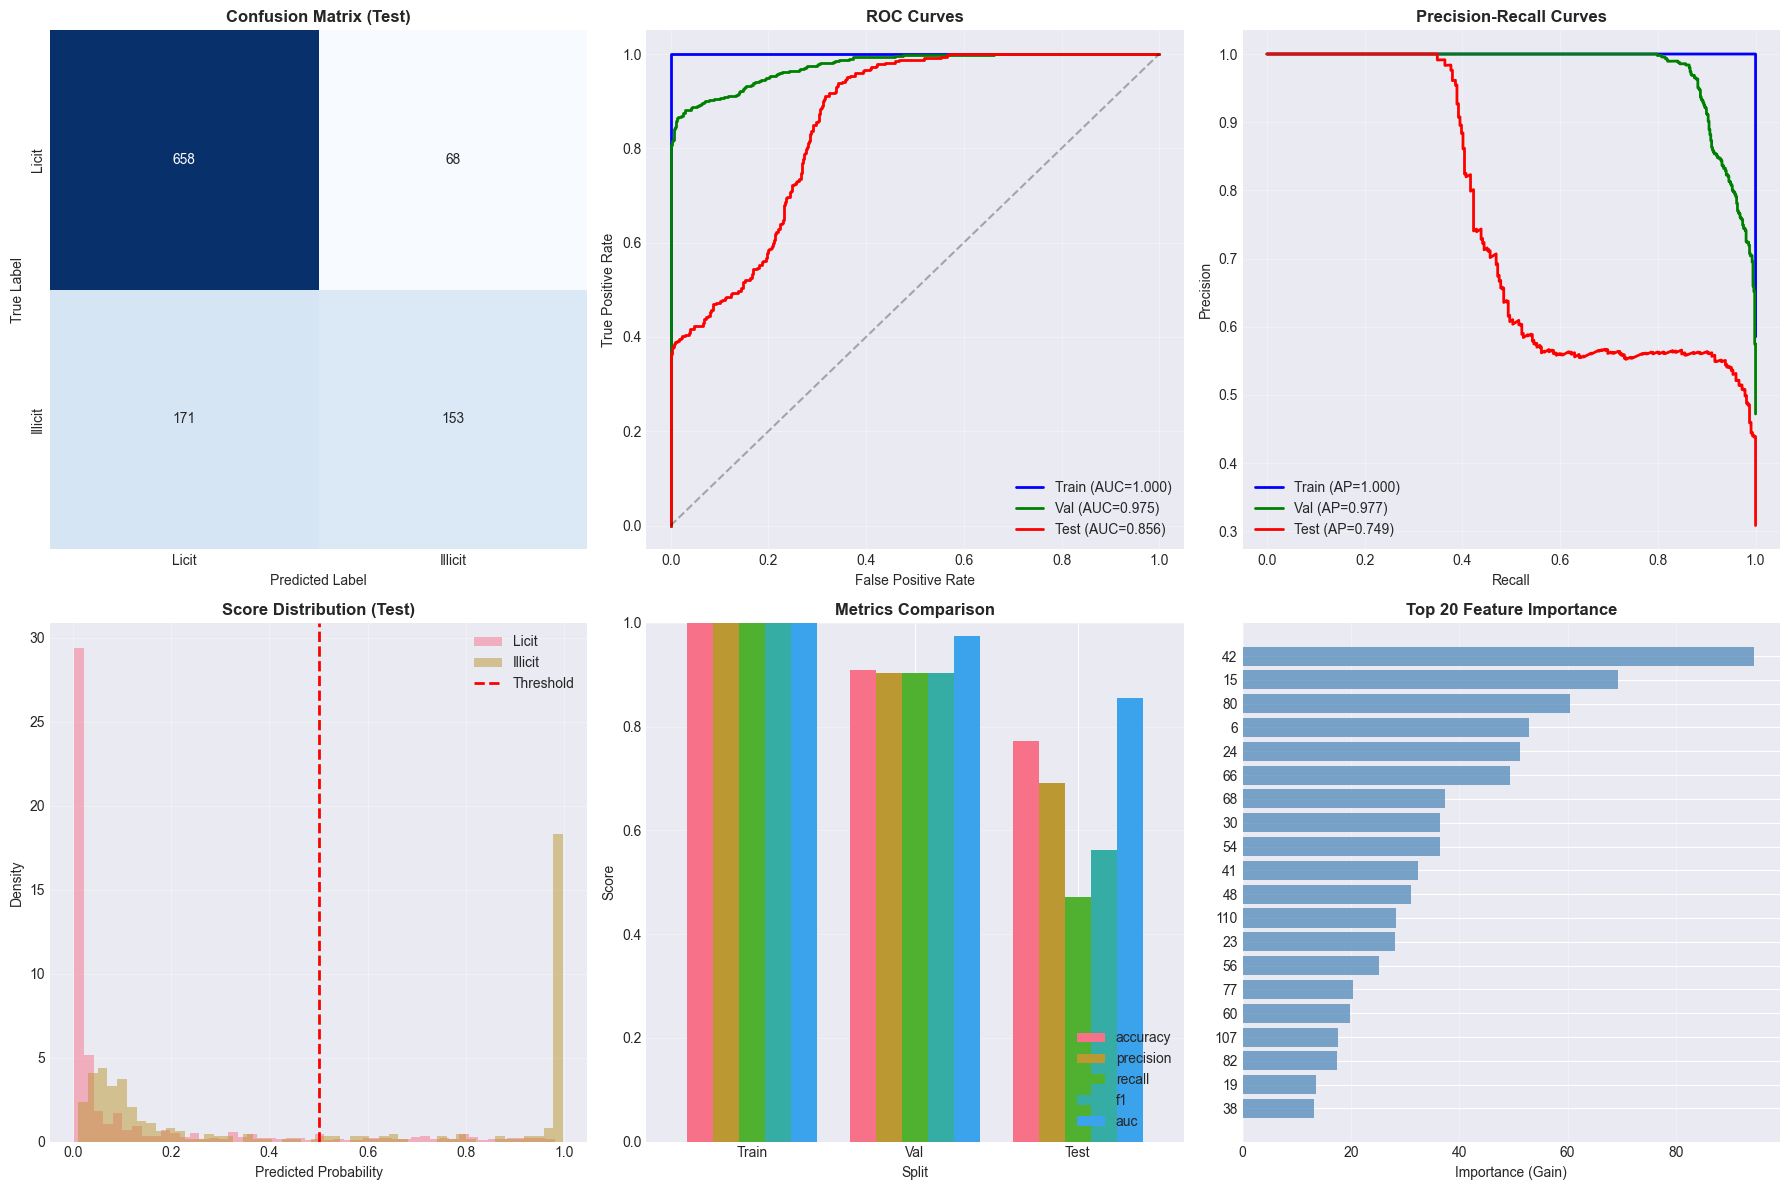

In [92]:
# %% [markdown]
# ### 5. Visualization

# %%
def plot_xgboost_results(train_pred_df, val_pred_df, test_pred_df, save_dir):
    """Plot XGBoost results"""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Confusion Matrix - Test
    ax = axes[0, 0]
    y_true = test_pred_df['true_label'].values
    y_pred = test_pred_df['pred_label'].values
    cm = confusion_matrix(y_true, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title('Confusion Matrix (Test)', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.set_xticklabels(['Licit', 'Illicit'])
    ax.set_yticklabels(['Licit', 'Illicit'])
    
    # 2. ROC Curve
    from sklearn.metrics import roc_curve
    ax = axes[0, 1]
    
    for pred_df, split_name, color in [
        (train_pred_df, 'Train', 'blue'),
        (val_pred_df, 'Val', 'green'),
        (test_pred_df, 'Test', 'red')
    ]:
        y_true = pred_df['true_label'].values
        y_prob = pred_df['pred_prob'].values
        
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        
        ax.plot(fpr, tpr, label=f'{split_name} (AUC={auc:.3f})', linewidth=2, color=color)
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title('ROC Curves', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # 3. Precision-Recall Curve
    from sklearn.metrics import precision_recall_curve
    ax = axes[0, 2]
    
    for pred_df, split_name, color in [
        (train_pred_df, 'Train', 'blue'),
        (val_pred_df, 'Val', 'green'),
        (test_pred_df, 'Test', 'red')
    ]:
        y_true = pred_df['true_label'].values
        y_prob = pred_df['pred_prob'].values
        
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        ap = average_precision_score(y_true, y_prob)
        
        ax.plot(recall, precision, label=f'{split_name} (AP={ap:.3f})', linewidth=2, color=color)
    
    ax.set_title('Precision-Recall Curves', fontweight='bold')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # 4. Score Distribution - Test
    ax = axes[1, 0]
    
    for label, label_name in [(0, 'Licit'), (1, 'Illicit')]:
        mask = test_pred_df['true_label'] == label
        scores = test_pred_df.loc[mask, 'pred_prob']
        ax.hist(scores, bins=50, alpha=0.5, label=label_name, density=True)
    
    ax.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Threshold')
    ax.set_title('Score Distribution (Test)', fontweight='bold')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # 5. Metrics Comparison
    ax = axes[1, 1]
    
    metrics_data = {
        'Train': train_metrics,
        'Val': val_metrics,
        'Test': test_metrics
    }
    
    metrics_df = pd.DataFrame(metrics_data).T
    metrics_df[['accuracy', 'precision', 'recall', 'f1', 'auc']].plot(
        kind='bar', ax=ax, width=0.8
    )
    ax.set_title('Metrics Comparison', fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_xlabel('Split')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3, axis='y')
    ax.set_ylim([0, 1])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    
    # 6. Feature Importance (Top 20)
    ax = axes[1, 2]
    
    importance_dict = xgb_model.get_score(importance_type='gain')
    
    if importance_dict:
        # Sort by importance
        importance_items = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)[:20]
        features, importances = zip(*importance_items)
        
        ax.barh(range(len(features)), importances, color='steelblue', alpha=0.7)
        ax.set_yticks(range(len(features)))
        ax.set_yticklabels(features)
        ax.set_xlabel('Importance (Gain)')
        ax.set_title('Top 20 Feature Importance', fontweight='bold')
        ax.grid(alpha=0.3, axis='x')
        ax.invert_yaxis()
    
    plt.tight_layout()
    
    # Save
    save_path = save_dir / 'xgboost_evaluation.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved plot: {save_path}")
    
    plt.show()

# Plot results
plot_xgboost_results(train_pred_df, val_pred_df, test_pred_df, OUTPUT_DIR)

In [93]:
# %% [markdown]
# ### 6. Save Summary Report

# %%
print("\n💾 Saving summary report...")

report_path = OUTPUT_DIR / 'xgboost_report.txt'

with open(report_path, 'w') as f:
    f.write("="*60 + "\n")
    f.write("XGBOOST MODEL REPORT\n")
    f.write("="*60 + "\n\n")
    
    f.write("Model Configuration:\n")
    f.write(f"  Objective: binary:logistic\n")
    f.write(f"  Max depth: {params['max_depth']}\n")
    f.write(f"  Learning rate: {params['eta']}\n")
    f.write(f"  Subsample: {params['subsample']}\n")
    f.write(f"  Colsample bytree: {params['colsample_bytree']}\n")
    f.write(f"  Best iteration: {xgb_model.best_iteration}\n")
    f.write(f"  Best score: {xgb_model.best_score:.4f}\n\n")
    
    f.write("Dataset Sizes:\n")
    f.write(f"  Train: {len(train_pred_df):,} samples\n")
    f.write(f"  Val:   {len(val_pred_df):,} samples\n")
    f.write(f"  Test:  {len(test_pred_df):,} samples\n\n")
    
    f.write("Performance Metrics:\n")
    f.write("\n  TRAIN SET:\n")
    for metric, value in train_metrics.items():
        f.write(f"    {metric:12s}: {value:.6f}\n")
    
    f.write("\n  VALIDATION SET:\n")
    for metric, value in val_metrics.items():
        f.write(f"    {metric:12s}: {value:.6f}\n")
    
    f.write("\n  TEST SET:\n")
    for metric, value in test_metrics.items():
        f.write(f"    {metric:12s}: {value:.6f}\n")
    
    # Classification report
    y_true = test_pred_df['true_label'].values
    y_pred = test_pred_df['pred_label'].values
    
    f.write("\n" + "="*60 + "\n")
    f.write("CLASSIFICATION REPORT (TEST SET)\n")
    f.write("="*60 + "\n\n")
    f.write(classification_report(
        y_true, y_pred, 
        target_names=['Licit', 'Illicit'],
        digits=4
    ))

print(f"  ✓ Saved: {report_path}")

# %% [markdown]
# ### 7. Summary

# %%
print("\n" + "="*80)
print(" "*25 + "✓ XGBOOST COMPLETE!")
print("="*80)

print("\n📁 Saved Files:")
print(f"  ✓ Model:       {model_path}")
print(f"  ✓ Train pred:  {train_path}")
print(f"  ✓ Val pred:    {val_path}")
print(f"  ✓ Test pred:   {test_path}")
print(f"  ✓ Plot:        {OUTPUT_DIR / 'xgboost_evaluation.png'}")
print(f"  ✓ Report:      {report_path}")

print("\n📊 Test Set Performance:")
print(f"  Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"  Precision: {test_metrics['precision']:.4f}")
print(f"  Recall:    {test_metrics['recall']:.4f}")
print(f"  F1 Score:  {test_metrics['f1']:.4f}")
print(f"  AUC-ROC:   {test_metrics['auc']:.4f}")
print(f"  AP:        {test_metrics['ap']:.4f}")

print("\n🚀 Ready for fusion! You can now run the fusion code.")


💾 Saving summary report...
  ✓ Saved: result5\models\xgboost_report.txt

                         ✓ XGBOOST COMPLETE!

📁 Saved Files:
  ✓ Model:       result5\models\xgboost_model.json
  ✓ Train pred:  result5\models\xgboost_predictions_train.csv
  ✓ Val pred:    result5\models\xgboost_predictions_val.csv
  ✓ Test pred:   result5\models\xgboost_predictions_test.csv
  ✓ Plot:        result5\models\xgboost_evaluation.png
  ✓ Report:      result5\models\xgboost_report.txt

📊 Test Set Performance:
  Accuracy:  0.7724
  Precision: 0.6923
  Recall:    0.4722
  F1 Score:  0.5615
  AUC-ROC:   0.8559
  AP:        0.7494

🚀 Ready for fusion! You can now run the fusion code.


# Sequence

In [94]:
# %% [markdown]
# # 1. Setup & Imports

# %%
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [95]:
# %% [markdown]
# # 2. Configuration

# %%
class SequenceConfig:
    """Configuration for Sequence GRU model"""
    
    # Paths
    RESULT_DIR = Path('result5')
    SEQUENCE_DIR = RESULT_DIR / 'sequence'
    MODEL_DIR = RESULT_DIR / 'models'
    META_PATH = RESULT_DIR / 'meta.csv'
    
    # Model architecture
    INPUT_DIM = 5           # Số features trong sequence (d_s)
    HIDDEN_DIM = 128        # Hidden dimension của GRU
    NUM_LAYERS = 2          # Số layers GRU
    DROPOUT = 0.3           # Dropout rate
    BIDIRECTIONAL = True    # Bidirectional GRU
    
    # Training params
    BATCH_SIZE = 64
    LEARNING_RATE = 0.001
    NUM_EPOCHS = 50
    PATIENCE = 10           # Early stopping patience
    
    # Sequence params
    SEQ_LEN = 5             # Độ dài sequence (L)
    
    # Other
    NUM_WORKERS = 0         # Set to 0 khi preload vào RAM

config = SequenceConfig()
config.MODEL_DIR.mkdir(exist_ok=True, parents=True)

print("✓ Configuration loaded")
print(f"  Sequence dir: {config.SEQUENCE_DIR}")
print(f"  Model dir: {config.MODEL_DIR}")
print(f"  Device: {device}")

✓ Configuration loaded
  Sequence dir: result5\sequence
  Model dir: result5\models
  Device: cuda


In [96]:
# %% [markdown]
# # 3. Optimized Dataset with Preloading

# %%
class OptimizedSequenceDataset(Dataset):
    """
    ⚡ OPTIMIZED Dataset - Preload toàn bộ sequences vào RAM
    Tăng tốc training lên 10-100x so với load từng file
    """
    
    def __init__(self, meta_df: pd.DataFrame, sequence_dir: Path, preload: bool = True):
        """
        Args:
            meta_df: DataFrame chứa metadata (id_anchor, label, split)
            sequence_dir: Thư mục chứa sequence files
            preload: Nếu True, load tất cả vào RAM ngay lập tức
        """
        self.meta_df = meta_df.reset_index(drop=True)
        self.sequence_dir = sequence_dir
        
        # Convert labels to numeric
        self.label_map = {'licit': 0, 'illicit': 1}
        self.meta_df['label_id'] = self.meta_df['label'].map(self.label_map)
        
        # ✅ PRELOAD ALL SEQUENCES INTO RAM
        if preload:
            self._preload_sequences()
        else:
            self.sequences = None
    
    def _preload_sequences(self):
        """Load tất cả sequences vào memory một lần"""
        print(f"\n⚡ Preloading {len(self.meta_df):,} sequences into RAM...")
        
        self.sequences = {}
        failed_count = 0
        shape_issues = 0
        
        for idx in tqdm(range(len(self.meta_df)), desc="Loading sequences"):
            id_anchor = self.meta_df.iloc[idx]['id_anchor']
            seq_file = self.sequence_dir / f"id={id_anchor}.npz"
            
            if seq_file.exists():
                try:
                    data = np.load(seq_file)
                    sequence = data['features']  # Shape: (L, d_s)
                    
                    # ✅ FIX: Đảm bảo số features = INPUT_DIM
                    if sequence.shape[1] != config.INPUT_DIM:
                        # Nếu ít features hơn -> pad với zeros
                        if sequence.shape[1] < config.INPUT_DIM:
                            pad_features = config.INPUT_DIM - sequence.shape[1]
                            padding = np.zeros((sequence.shape[0], pad_features), dtype=np.float32)
                            sequence = np.hstack([sequence, padding])
                        # Nếu nhiều features hơn -> truncate
                        else:
                            sequence = sequence[:, :config.INPUT_DIM]
                        shape_issues += 1
                    
                    # Pad hoặc truncate về đúng SEQ_LEN
                    if len(sequence) < config.SEQ_LEN:
                        # Pad with zeros
                        pad_len = config.SEQ_LEN - len(sequence)
                        padding = np.zeros((pad_len, config.INPUT_DIM), dtype=np.float32)
                        sequence = np.vstack([padding, sequence])
                    elif len(sequence) > config.SEQ_LEN:
                        # Truncate (lấy L cuối)
                        sequence = sequence[-config.SEQ_LEN:]
                    
                    # Đảm bảo shape cuối cùng đúng
                    assert sequence.shape == (config.SEQ_LEN, config.INPUT_DIM), \
                        f"Wrong shape: {sequence.shape}, expected ({config.SEQ_LEN}, {config.INPUT_DIM})"
                    
                    self.sequences[id_anchor] = sequence.astype(np.float32)
                    
                except Exception as e:
                    # Nếu file lỗi, tạo dummy sequence
                    self.sequences[id_anchor] = np.zeros(
                        (config.SEQ_LEN, config.INPUT_DIM), 
                        dtype=np.float32
                    )
                    failed_count += 1
            else:
                # Nếu không có file, tạo dummy sequence
                self.sequences[id_anchor] = np.zeros(
                    (config.SEQ_LEN, config.INPUT_DIM), 
                    dtype=np.float32
                )
                failed_count += 1
        
        # Print summary
        print(f"✓ Preloading complete!")
        print(f"  Loaded: {len(self.sequences):,} sequences")
        if shape_issues > 0:
            print(f"  Fixed shape issues: {shape_issues:,} files")
        if failed_count > 0:
            print(f"  Failed/Missing: {failed_count:,} files (created dummy sequences)")
        
        # Calculate memory usage
        total_bytes = sum(seq.nbytes for seq in self.sequences.values())
        total_mb = total_bytes / (1024 * 1024)
        print(f"  Memory usage: {total_mb:.2f} MB")
    
    def __len__(self):
        return len(self.meta_df)
    
    def __getitem__(self, idx):
        """
        Returns:
            sequence: torch.Tensor of shape (L, d_s) - sequence features
            label: torch.Tensor of shape (1,) - binary label
            id_anchor: str - anchor ID
        """
        row = self.meta_df.iloc[idx]
        id_anchor = row['id_anchor']
        label = row['label_id']
        
        # ✅ Lấy từ RAM - CỰC NHANH!
        if self.sequences is not None:
            sequence = self.sequences[id_anchor]
        else:
            # Fallback: load từ file (chậm)
            seq_file = self.sequence_dir / f"id={id_anchor}.npz"
            if seq_file.exists():
                try:
                    data = np.load(seq_file)
                    sequence = data['features']
                    
                    # ✅ FIX: Đảm bảo số features = INPUT_DIM
                    if sequence.shape[1] != config.INPUT_DIM:
                        if sequence.shape[1] < config.INPUT_DIM:
                            pad_features = config.INPUT_DIM - sequence.shape[1]
                            padding = np.zeros((sequence.shape[0], pad_features), dtype=np.float32)
                            sequence = np.hstack([sequence, padding])
                        else:
                            sequence = sequence[:, :config.INPUT_DIM]
                    
                    if len(sequence) < config.SEQ_LEN:
                        pad_len = config.SEQ_LEN - len(sequence)
                        padding = np.zeros((pad_len, config.INPUT_DIM), dtype=np.float32)
                        sequence = np.vstack([padding, sequence])
                    elif len(sequence) > config.SEQ_LEN:
                        sequence = sequence[-config.SEQ_LEN:]
                except:
                    sequence = np.zeros((config.SEQ_LEN, config.INPUT_DIM), dtype=np.float32)
            else:
                sequence = np.zeros((config.SEQ_LEN, config.INPUT_DIM), dtype=np.float32)
        
        # Convert to tensor
        sequence = torch.FloatTensor(sequence)  # (L, d_s)
        label = torch.LongTensor([label])       # (1,)
        
        return sequence, label, id_anchor


In [97]:
# %% [markdown]
# # 4. Create DataLoaders

# %%
def create_dataloaders(meta_path: Path, sequence_dir: Path, batch_size: int = 64):
    """Create train/val/test dataloaders với preloading"""
    
    print("\n" + "="*60)
    print("CREATING DATALOADERS")
    print("="*60)
    
    # Load metadata
    meta_df = pd.read_csv(meta_path)
    
    # Add split column if not exists (based on t_anchor)
    if 'split' not in meta_df.columns:
        def get_split(t):
            if t <= 34:
                return 'train'
            elif t <= 41:
                return 'val'
            else:
                return 'test'
        meta_df['split'] = meta_df['t_anchor'].apply(get_split)
    
    # Split datasets
    train_df = meta_df[meta_df['split'] == 'train'].reset_index(drop=True)
    val_df = meta_df[meta_df['split'] == 'val'].reset_index(drop=True)
    test_df = meta_df[meta_df['split'] == 'test'].reset_index(drop=True)
    
    print("\nDataset splits:")
    print(f"  Train: {len(train_df):,} samples")
    print(f"  Val:   {len(val_df):,} samples")
    print(f"  Test:  {len(test_df):,} samples")
    print(f"  Total: {len(meta_df):,} samples")
    
    # ✅ Create datasets with preloading
    print("\n" + "-"*60)
    print("TRAIN SET")
    print("-"*60)
    train_dataset = OptimizedSequenceDataset(train_df, sequence_dir, preload=True)
    
    print("\n" + "-"*60)
    print("VALIDATION SET")
    print("-"*60)
    val_dataset = OptimizedSequenceDataset(val_df, sequence_dir, preload=True)
    
    print("\n" + "-"*60)
    print("TEST SET")
    print("-"*60)
    test_dataset = OptimizedSequenceDataset(test_df, sequence_dir, preload=True)
    
    # Create dataloaders
    # Note: num_workers=0 khi đã preload vào RAM
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=config.NUM_WORKERS,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=config.NUM_WORKERS,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=config.NUM_WORKERS,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    print("\n✓ All dataloaders created successfully!")
    
    return train_loader, val_loader, test_loader, meta_df

# %%
# Create dataloaders
print("\n" + "="*80)
print(" "*25 + "INITIALIZING DATALOADERS")
print("="*80)

train_loader, val_loader, test_loader, meta_df = create_dataloaders(
    config.META_PATH,
    config.SEQUENCE_DIR,
    config.BATCH_SIZE
)

print("\n✓ Dataloaders ready!")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")


                         INITIALIZING DATALOADERS

CREATING DATALOADERS

Dataset splits:
  Train: 2,749 samples
  Val:   1,201 samples
  Test:  1,050 samples
  Total: 5,000 samples

------------------------------------------------------------
TRAIN SET
------------------------------------------------------------

⚡ Preloading 2,749 sequences into RAM...


Loading sequences: 100%|██████████| 2749/2749 [01:03<00:00, 42.98it/s]


✓ Preloading complete!
  Loaded: 2,749 sequences
  Fixed shape issues: 960 files
  Memory usage: 0.26 MB

------------------------------------------------------------
VALIDATION SET
------------------------------------------------------------

⚡ Preloading 1,201 sequences into RAM...


Loading sequences: 100%|██████████| 1201/1201 [00:22<00:00, 53.32it/s]


✓ Preloading complete!
  Loaded: 1,201 sequences
  Fixed shape issues: 634 files
  Memory usage: 0.11 MB

------------------------------------------------------------
TEST SET
------------------------------------------------------------

⚡ Preloading 1,050 sequences into RAM...


Loading sequences: 100%|██████████| 1050/1050 [00:18<00:00, 56.69it/s]

✓ Preloading complete!
  Loaded: 1,050 sequences
  Fixed shape issues: 726 files
  Memory usage: 0.10 MB

✓ All dataloaders created successfully!

✓ Dataloaders ready!
  Train batches: 43
  Val batches: 19
  Test batches: 17


In [98]:
# %% [markdown]
# # 5. GRU Model

# %%
class SequenceGRU(nn.Module):
    """
    GRU model cho sequence classification
    
    Architecture:
        Input: s_a ∈ R^(L × d_s)
        GRU/LSTM → last hidden state → FC → logit
        Output: p_seq(a) = σ(logit(a))
    """
    
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        num_layers: int = 2,
        dropout: float = 0.3,
        bidirectional: bool = True
    ):
        super(SequenceGRU, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        
        # GRU layer
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )
        
        # Fully connected layers
        fc_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
        
        self.fc = nn.Sequential(
            nn.Linear(fc_input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)  # Binary classification logit
        )
        
    def forward(self, x):
        """
        Args:
            x: (batch_size, seq_len, input_dim)
        
        Returns:
            logits: (batch_size, 1)
            probs: (batch_size, 1)
        """
        # GRU forward
        # output: (batch_size, seq_len, hidden_dim * num_directions)
        # hidden: (num_layers * num_directions, batch_size, hidden_dim)
        output, hidden = self.gru(x)
        
        # Use last hidden state
        if self.bidirectional:
            # Concatenate forward and backward hidden states
            hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)  # (batch_size, hidden_dim*2)
        else:
            hidden = hidden[-1]  # (batch_size, hidden_dim)
        
        # Fully connected
        logits = self.fc(hidden)  # (batch_size, 1)
        probs = torch.sigmoid(logits)  # (batch_size, 1)
        
        return logits, probs

# Initialize model
model = SequenceGRU(
    input_dim=config.INPUT_DIM,
    hidden_dim=config.HIDDEN_DIM,
    num_layers=config.NUM_LAYERS,
    dropout=config.DROPOUT,
    bidirectional=config.BIDIRECTIONAL
).to(device)

print("\n" + "="*60)
print("MODEL ARCHITECTURE")
print("="*60)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


MODEL ARCHITECTURE
SequenceGRU(
  (gru): GRU(5, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 441,345
Trainable parameters: 441,345


In [99]:
# %% [markdown]
# # 6. Training Functions

# %%
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with tqdm(dataloader, desc="Training", leave=False) as pbar:
        for sequences, labels, _ in pbar:
            # Move to device
            sequences = sequences.to(device)  # (batch, seq_len, input_dim)
            labels = labels.to(device).float()  # (batch, 1)
            
            # Forward
            optimizer.zero_grad()
            logits, probs = model(sequences)
            
            # Loss
            loss = criterion(logits, labels)
            
            # Backward
            loss.backward()
            optimizer.step()
            
            # Metrics
            total_loss += loss.item()
            preds = (probs > 0.5).float()
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # Update progress bar
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Calculate metrics
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    
    return avg_loss, accuracy

def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    
    total_loss = 0
    all_preds = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        with tqdm(dataloader, desc="Validation", leave=False) as pbar:
            for sequences, labels, _ in pbar:
                # Move to device
                sequences = sequences.to(device)
                labels = labels.to(device).float()
                
                # Forward
                logits, probs = model(sequences)
                
                # Loss
                loss = criterion(logits, labels)
                total_loss += loss.item()
                
                # Collect predictions
                preds = (probs > 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Calculate metrics
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    
    # Additional metrics
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    
    try:
        auc = roc_auc_score(all_labels, all_probs)
        ap = average_precision_score(all_labels, all_probs)
    except:
        auc = 0.0
        ap = 0.0
    
    metrics = {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'ap': ap
    }
    
    return metrics

In [100]:
import sympy
print(sympy.__version__)
print(sympy.__file__)


1.13.1
C:\Users\HAI NAM\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sympy\__init__.py


In [101]:
# %% [markdown]
# # 7. Training Loop

# %%
def train_model(
    model,
    train_loader,
    val_loader,
    num_epochs: int = 50,
    learning_rate: float = 0.001,
    patience: int = 10,
    save_path: Path = None
):
    """Complete training loop with early stopping"""
    
    # Loss and optimizer
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=True
    )
    
    # Training history
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'val_f1': [],
        'val_auc': []
    }
    
    best_val_loss = float('inf')
    best_val_f1 = 0.0
    patience_counter = 0
    
    print("\n" + "="*60)
    print("TRAINING SEQUENCE GRU MODEL")
    print("="*60)
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 60)
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_metrics = validate_epoch(model, val_loader, criterion, device)
        
        # Update history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_auc'].append(val_metrics['auc'])
        
        # Print metrics
        print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['accuracy']:.4f}")
        print(f"Val F1: {val_metrics['f1']:.4f} | Val AUC: {val_metrics['auc']:.4f}")
        print(f"Val Precision: {val_metrics['precision']:.4f} | Val Recall: {val_metrics['recall']:.4f}")
        
        # Learning rate scheduler
        scheduler.step(val_metrics['loss'])
        
        # Early stopping based on F1
        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            best_val_loss = val_metrics['loss']
            patience_counter = 0
            
            # Save best model
            if save_path:
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_metrics': val_metrics,
                    'history': history
                }, save_path)
                print(f"✓ Saved best model (F1: {best_val_f1:.4f})")
        else:
            patience_counter += 1
            
        # Early stopping
        if patience_counter >= patience:
            print(f"\n✗ Early stopping triggered after {epoch+1} epochs")
            break
    
    print("\n" + "="*60)
    print("TRAINING COMPLETE")
    print("="*60)
    print(f"Best Val Loss: {best_val_loss:.4f}")
    print(f"Best Val F1: {best_val_f1:.4f}")
    
    return history

# Ép MODEL_DIR về đúng: result/models
config.MODEL_DIR = Path("result5/models")
config.MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_save_path = config.MODEL_DIR / "sequence_gru_best.pth"

print("✓ Model will be saved to:", model_save_path)

history = train_model(
    model,
    train_loader,
    val_loader,
    num_epochs=config.NUM_EPOCHS,
    learning_rate=config.LEARNING_RATE,
    patience=config.PATIENCE,
    save_path=model_save_path
)

✓ Model will be saved to: result5\models\sequence_gru_best.pth

TRAINING SEQUENCE GRU MODEL

Epoch 1/50
------------------------------------------------------------



Train Loss: 0.3488 | Train Acc: 0.9120
Val Loss: 0.0600 | Val Acc: 0.9950
Val F1: 0.9947 | Val AUC: 1.0000
Val Precision: 1.0000 | Val Recall: 0.9894
✓ Saved best model (F1: 0.9947)

Epoch 2/50
------------------------------------------------------------



Train Loss: 0.2261 | Train Acc: 0.9305
Val Loss: 0.0886 | Val Acc: 0.9958
Val F1: 0.9956 | Val AUC: 1.0000
Val Precision: 1.0000 | Val Recall: 0.9912
✓ Saved best model (F1: 0.9956)

Epoch 3/50
------------------------------------------------------------



Train Loss: 0.2323 | Train Acc: 0.9280
Val Loss: 0.0584 | Val Acc: 0.9983
Val F1: 0.9982 | Val AUC: 1.0000
Val Precision: 1.0000 | Val Recall: 0.9965
✓ Saved best model (F1: 0.9982)

Epoch 4/50
------------------------------------------------------------



Train Loss: 0.2299 | Train Acc: 0.9276
Val Loss: 0.0265 | Val Acc: 1.0000
Val F1: 1.0000 | Val AUC: 1.0000
Val Precision: 1.0000 | Val Recall: 1.0000
✓ Saved best model (F1: 1.0000)

Epoch 5/50
------------------------------------------------------------


...


Train Loss: 0.2062 | Train Acc: 0.9356
Val Loss: 0.0509 | Val Acc: 0.9967
Val F1: 0.9965 | Val AUC: 1.0000
Val Precision: 1.0000 | Val Recall: 0.9929

Epoch 11/50
------------------------------------------------------------



Train Loss: 0.2020 | Train Acc: 0.9352
Val Loss: 0.0482 | Val Acc: 0.9992
Val F1: 0.9991 | Val AUC: 1.0000
Val Precision: 1.0000 | Val Recall: 0.9982

Epoch 12/50
------------------------------------------------------------



Train Loss: 0.1953 | Train Acc: 0.9363
Val Loss: 0.0411 | Val Acc: 0.9983
Val F1: 0.9982 | Val AUC: 1.0000
Val Precision: 1.0000 | Val Recall: 0.9965

Epoch 13/50
------------------------------------------------------------



Train Loss: 0.1951 | Train Acc: 0.9345
Val Loss: 0.0391 | Val Acc: 0.9992
Val F1: 0.9991 | Val AUC: 1.0000
Val Precision: 1.0000 | Val Recall: 0.9982

Epoch 14/50
------------------------------------------------------------



Train Loss: 0.1942 | Train Acc: 0.9363
Val Loss: 0.0580 | Val Acc: 0.9967
Val F1: 0.9965 | Val AUC: 1.0000
Val Precision: 1.0000 | Val Recall: 0.9929

✗ Early stopping triggered after 14 epochs

TRAINING COMPLETE
Best Val Loss: 0.0265
Best Val F1: 1.0000


✓ Saved: result5\models\training_history.png


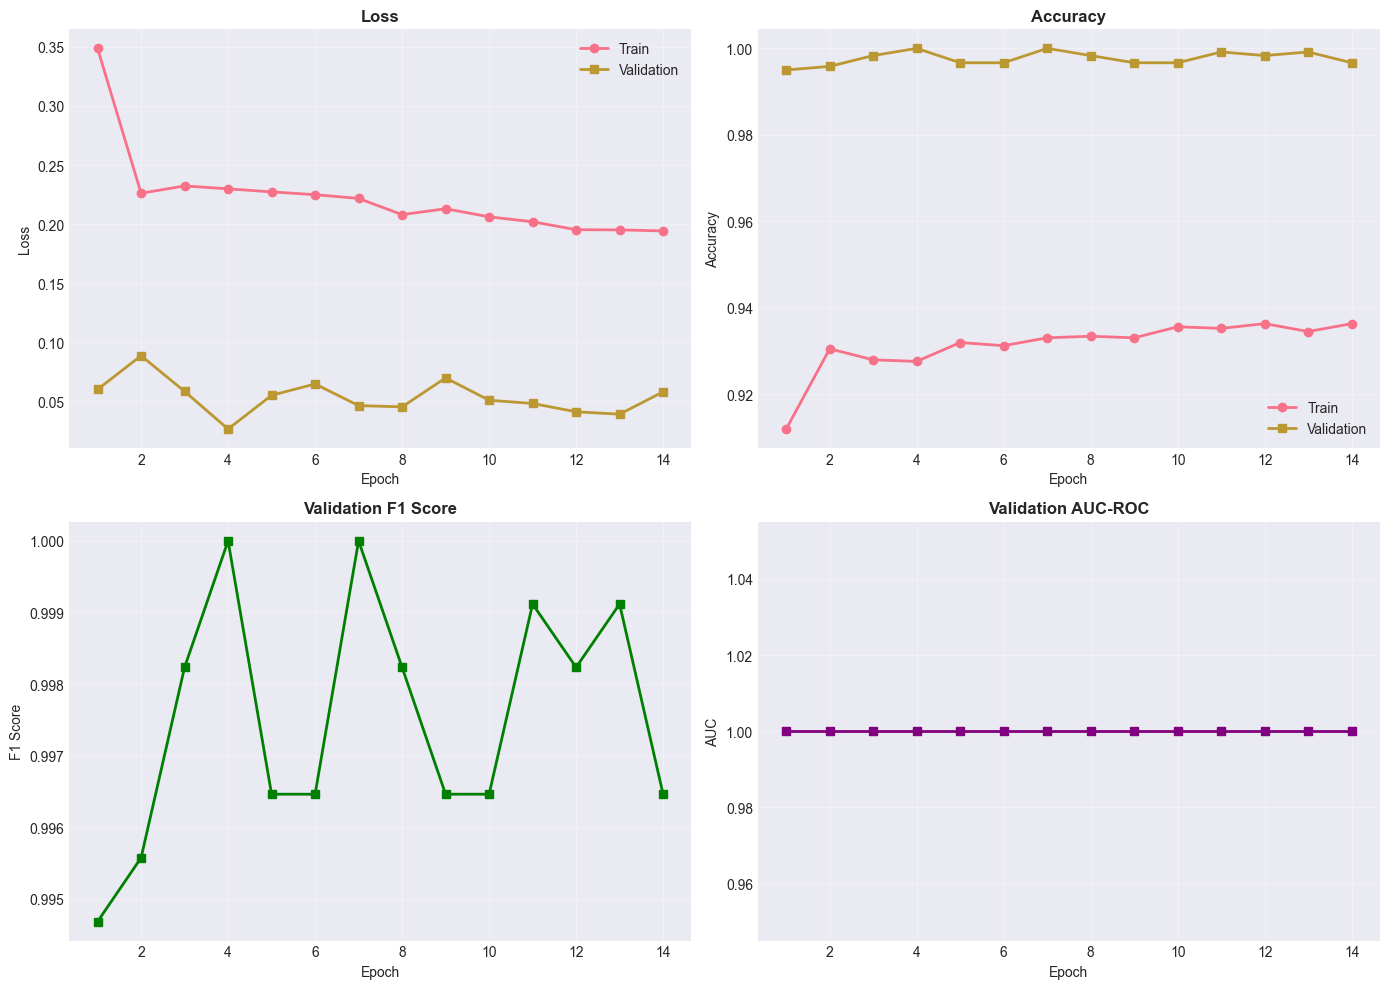

In [102]:
# %% [markdown]
# # 8. Evaluation & Visualization

# %%
def plot_training_history(history, save_path=None):
    """Plot training history"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss
    ax = axes[0, 0]
    ax.plot(epochs, history['train_loss'], 'o-', label='Train', linewidth=2)
    ax.plot(epochs, history['val_loss'], 's-', label='Validation', linewidth=2)
    ax.set_title('Loss', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Accuracy
    ax = axes[0, 1]
    ax.plot(epochs, history['train_acc'], 'o-', label='Train', linewidth=2)
    ax.plot(epochs, history['val_acc'], 's-', label='Validation', linewidth=2)
    ax.set_title('Accuracy', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # F1 Score
    ax = axes[1, 0]
    ax.plot(epochs, history['val_f1'], 's-', color='green', linewidth=2)
    ax.set_title('Validation F1 Score', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F1 Score')
    ax.grid(alpha=0.3)
    
    # AUC
    ax = axes[1, 1]
    ax.plot(epochs, history['val_auc'], 's-', color='purple', linewidth=2)
    ax.set_title('Validation AUC-ROC', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('AUC')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")
    
    plt.show()

# Plot training history
plot_training_history(history, config.MODEL_DIR / 'training_history.png')

# %%
def evaluate_model(model, dataloader, device, split_name='Test'):
    """Comprehensive evaluation"""
    model.eval()
    
    all_preds = []
    all_probs = []
    all_labels = []
    all_ids = []
    
    print(f"\nEvaluating on {split_name} set...")
    
    with torch.no_grad():
        for sequences, labels, ids in tqdm(dataloader, desc=f"Evaluating {split_name}"):
            sequences = sequences.to(device)
            labels = labels.to(device).float()
            
            logits, probs = model(sequences)
            preds = (probs > 0.5).float()
            
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_ids.extend(ids)
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    
    try:
        auc = roc_auc_score(all_labels, all_probs)
        ap = average_precision_score(all_labels, all_probs)
    except:
        auc = 0.0
        ap = 0.0
    
    # Print results
    print("\n" + "="*60)
    print(f"{split_name.upper()} SET RESULTS")
    print("="*60)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"AP:        {ap:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{split_name} Set - Confusion Matrix', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.set_xticklabels(['Licit', 'Illicit'])
    ax.set_yticklabels(['Licit', 'Illicit'])
    
    save_path = config.MODEL_DIR / f'confusion_matrix_{split_name.lower()}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved confusion matrix: {save_path}")
    plt.show()
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(
        all_labels, all_preds,
        target_names=['Licit', 'Illicit'],
        digits=4
    ))
    
    # Return predictions
    results_df = pd.DataFrame({
        'id_anchor': all_ids,
        'true_label': all_labels,
        'pred_label': all_preds,
        'pred_prob': all_probs
    })
    
    return results_df, {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'ap': ap
    }


✓ Loaded best model from epoch 4
   Best Val F1: 1.0000
   Best Val AUC: 1.0000

Evaluating on Test set...


Evaluating Test: 100%|██████████| 17/17 [00:00<00:00, 166.19it/s]


TEST SET RESULTS
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
AUC-ROC:   1.0000
AP:        1.0000



✓ Saved confusion matrix: result5\models\confusion_matrix_test.png


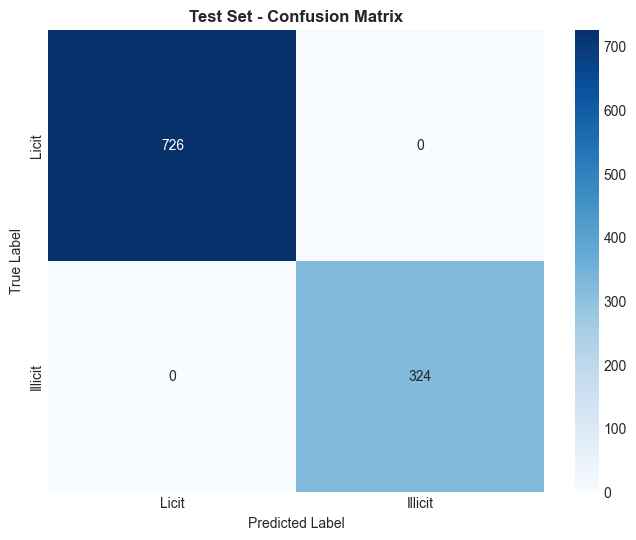


Classification Report:
              precision    recall  f1-score   support

       Licit     1.0000    1.0000    1.0000       726
     Illicit     1.0000    1.0000    1.0000       324

    accuracy                         1.0000      1050
   macro avg     1.0000    1.0000    1.0000      1050
weighted avg     1.0000    1.0000    1.0000      1050


✓ Saved predictions: result5\models\sequence_predictions_test.csv

                         ⚡ TRAINING COMPLETE! ⚡

Model saved to: result5\models\sequence_gru_best.pth
Predictions saved to: result5\models\sequence_predictions_test.csv

🎯 Test F1 Score: 1.0000
🎯 Test AUC-ROC: 1.0000

💡 Với preloading, training nhanh hơn 10-100x!


In [103]:
# %% [markdown]
# # 9. Load Best Model & Final Evaluation

# %%
# Load best model (chỉ chạy sau khi đã train xong)
if model_save_path.exists():
    checkpoint = torch.load(model_save_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"\n✓ Loaded best model from epoch {checkpoint['epoch']+1}")
    print(f"   Best Val F1: {checkpoint['val_metrics']['f1']:.4f}")
    print(f"   Best Val AUC: {checkpoint['val_metrics']['auc']:.4f}")
    
    # Evaluate on test set
    test_results_df, test_metrics = evaluate_model(model, test_loader, device, 'Test')
    
    # Save predictions
    predictions_path = config.MODEL_DIR / 'sequence_predictions_test.csv'
    test_results_df.to_csv(predictions_path, index=False)
    print(f"\n✓ Saved predictions: {predictions_path}")
    
    # %%
    print("\n" + "="*80)
    print(" "*25 + "⚡ TRAINING COMPLETE! ⚡")
    print("="*80)
    print(f"\nModel saved to: {model_save_path}")
    print(f"Predictions saved to: {predictions_path}")
    print(f"\n🎯 Test F1 Score: {test_metrics['f1']:.4f}")
    print(f"🎯 Test AUC-ROC: {test_metrics['auc']:.4f}")
    print(f"\n💡 Với preloading, training nhanh hơn 10-100x!")
else:
    print(f"\n⚠️  Model file not found: {model_save_path}")
    print("   Please train the model first by running the training cell above.")

## Graph


In [104]:
# %% [markdown]
# # 1. Setup & Imports

# %%
import json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

In [105]:
# %% [markdown]
# # 2. Configuration

# %%
class BuildGraphConfig:
    """Configuration for building graph"""
    
    RESULT_DIR = Path('result5')
    GRAPH_DIR = RESULT_DIR / 'graph'
    META_PATH = RESULT_DIR / 'meta.csv'
    
    # Output files
    NODE_FEATURES_FILE = GRAPH_DIR / 'node_features.npz'
    EDGE_INDEX_FILE = GRAPH_DIR / 'edge_index.npz'
    NODE_MAPPING_FILE = GRAPH_DIR / 'node_mapping.csv'
    GRAPH_STATS_FILE = GRAPH_DIR / 'graph_stats.txt'

config = BuildGraphConfig()

print("✓ Configuration loaded")
print(f"  Graph dir: {config.GRAPH_DIR}")
print(f"  Output files will be saved to: {config.GRAPH_DIR}")


✓ Configuration loaded
  Graph dir: result5\graph
  Output files will be saved to: result5\graph


In [106]:
# %% [markdown]
# # 3. Load All JSON Files and Merge

# %%
def load_and_merge_subgraphs(graph_dir: Path):
    """
    Load tất cả JSON files và merge thành 1 graph lớn
    
    JSON structure:
    {
        "nodes": [node_ids],
        "edges": [[src, tgt], ...],
        "node_features": {node_id: {features}},
        "edge_features": {}
    }
    
    Returns:
        all_nodes: dict {node_id: features_dict}
        all_edges: set of (src, tgt) tuples
        anchor_nodes: set of anchor node IDs
    """
    print("\n" + "="*60)
    print("LOADING AND MERGING SUBGRAPHS")
    print("="*60)
    
    json_files = list(graph_dir.glob("*.json"))
    print(f"\nFound {len(json_files):,} JSON files (subgraphs)")
    
    all_nodes = {}  # node_id -> features dict
    all_edges = set()  # Set of (src, tgt) tuples to avoid duplicates
    anchor_nodes = set()  # Set of anchor node IDs
    
    failed = 0
    
    for json_file in tqdm(json_files, desc="Loading subgraphs"):
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
            
            # Extract anchor ID from filename
            # Filename: id=btc_tx_XXXXX.json -> anchor = XXXXX
            anchor_id = json_file.stem  # id=btc_tx_2534
            if anchor_id.startswith("id="):
                anchor_id = anchor_id[3:]  # btc_tx_2534
            
            # Parse anchor node ID (thường là số cuối trong nodes)
            # Hoặc lấy từ filename
            if 'nodes' in data and len(data['nodes']) > 0:
                # Anchor thường là node cuối cùng trong list
                anchor_node_id = data['nodes'][-1]
                anchor_nodes.add(anchor_node_id)
            
            # Merge nodes
            if 'node_features' in data:
                for node_id_str, features in data['node_features'].items():
                    node_id = int(node_id_str)  # Convert string to int
                    
                    if node_id not in all_nodes:
                        all_nodes[node_id] = features
                    else:
                        # Node đã tồn tại, merge features (lấy features mới nhất)
                        all_nodes[node_id].update(features)
            
            # Merge edges
            if 'edges' in data:
                for edge in data['edges']:
                    if len(edge) == 2:
                        src, tgt = edge
                        all_edges.add((int(src), int(tgt)))
            
        except Exception as e:
            failed += 1
            if failed <= 5:
                print(f"\n  Failed to load {json_file.name}: {e}")
    
    print(f"\n✓ Merged all subgraphs!")
    print(f"  Unique nodes: {len(all_nodes):,}")
    print(f"  Unique edges: {len(all_edges):,}")
    print(f"  Anchor nodes: {len(anchor_nodes):,}")
    if failed > 0:
        print(f"  Failed files: {failed}")
    
    return all_nodes, all_edges, anchor_nodes

# Load and merge
all_nodes, all_edges, anchor_nodes = load_and_merge_subgraphs(config.GRAPH_DIR)

# Show sample node features
if all_nodes:
    sample_node_id = list(all_nodes.keys())[0]
    sample_features = all_nodes[sample_node_id]
    
    print("\n" + "="*60)
    print("SAMPLE NODE FEATURES")
    print("="*60)
    print(f"\nNode ID: {sample_node_id}")
    print(f"Features: {sample_features}")
    print(f"\nFeature keys: {list(sample_features.keys())}")


LOADING AND MERGING SUBGRAPHS

Found 46,564 JSON files (subgraphs)


Loading subgraphs: 100%|██████████| 46564/46564 [15:47<00:00, 49.15it/s]


✓ Merged all subgraphs!
  Unique nodes: 63,697
  Unique edges: 62,433
  Anchor nodes: 30,140

SAMPLE NODE FEATURES

Node ID: 100002363
Features: {'time_step': 21, 'label': 'licit', 'degree': 3}

Feature keys: ['time_step', 'label', 'degree']


In [107]:
# %% [markdown]
# # 4. Create Node Feature Matrix

# %%
def create_node_feature_matrix(all_nodes: dict, anchor_nodes: set):
    """
    Tạo node feature matrix
    
    Features từ JSON:
    - time_step: int
    - label: "licit" / "illicit"
    - degree: int
    
    Sẽ tạo thêm:
    - is_anchor: 0/1
    - label_numeric: 0 (licit) / 1 (illicit)
    
    Returns:
        features: numpy array (num_nodes, num_features)
        node_to_idx: dict {node_id: index}
        feature_names: list of feature names
    """
    print("\n" + "="*60)
    print("CREATING NODE FEATURE MATRIX")
    print("="*60)
    
    # Sort node IDs for consistent ordering
    sorted_node_ids = sorted(all_nodes.keys())
    node_to_idx = {node_id: idx for idx, node_id in enumerate(sorted_node_ids)}
    
    # Feature names
    feature_names = [
        'time_step',
        'degree',
        'is_anchor',
        'is_illicit'  # 0 = licit, 1 = illicit
    ]
    
    num_nodes = len(sorted_node_ids)
    num_features = len(feature_names)
    
    print(f"\nBuilding feature matrix...")
    print(f"  Nodes: {num_nodes:,}")
    print(f"  Features: {num_features}")
    print(f"  Feature names: {feature_names}")
    
    features = np.zeros((num_nodes, num_features), dtype=np.float32)
    
    for node_id in tqdm(sorted_node_ids, desc="Creating features"):
        idx = node_to_idx[node_id]
        node_feats = all_nodes[node_id]
        
        # Extract features
        features[idx, 0] = node_feats.get('time_step', 0)
        features[idx, 1] = node_feats.get('degree', 0)
        features[idx, 2] = 1 if node_id in anchor_nodes else 0
        
        # Label (only for labeled nodes)
        label = node_feats.get('label', 'licit')
        features[idx, 3] = 1 if label == 'illicit' else 0
    
    # Statistics
    print(f"\n✓ Feature matrix created!")
    print(f"  Shape: {features.shape}")
    print(f"  Data type: {features.dtype}")
    print(f"  Memory: {features.nbytes / (1024**2):.2f} MB")
    
    print(f"\nFeature statistics:")
    for i, name in enumerate(feature_names):
        col = features[:, i]
        print(f"  {name}:")
        print(f"    Min: {col.min():.2f}, Max: {col.max():.2f}")
        print(f"    Mean: {col.mean():.2f}, Std: {col.std():.2f}")
    
    return features, node_to_idx, feature_names

# Create features
node_features, node_to_idx, feature_names = create_node_feature_matrix(
    all_nodes, anchor_nodes
)


CREATING NODE FEATURE MATRIX

Building feature matrix...
  Nodes: 63,697
  Features: 4
  Feature names: ['time_step', 'degree', 'is_anchor', 'is_illicit']


Creating features: 100%|██████████| 63697/63697 [00:00<00:00, 505380.94it/s]


✓ Feature matrix created!
  Shape: (63697, 4)
  Data type: float32
  Memory: 0.97 MB

Feature statistics:
  time_step:
    Min: 1.00, Max: 49.00
    Mean: 24.88, Std: 15.35
  degree:
    Min: 1.00, Max: 473.00
    Mean: 2.95, Std: 7.32
  is_anchor:
    Min: 0.00, Max: 1.00
    Mean: 0.47, Std: 0.50
  is_illicit:
    Min: 0.00, Max: 1.00
    Mean: 0.07, Std: 0.26


In [108]:
# %% [markdown]
# # 5. Create Edge Index

# %%
def create_edge_index(all_edges: set, node_to_idx: dict):
    """
    Tạo edge index từ edge set
    
    Returns:
        edge_index: numpy array (2, num_edges)
    """
    print("\n" + "="*60)
    print("CREATING EDGE INDEX")
    print("="*60)
    
    valid_edges = []
    invalid_count = 0
    
    print(f"\nProcessing {len(all_edges):,} edges...")
    
    for src, tgt in tqdm(all_edges, desc="Processing edges"):
        # Check if both nodes exist
        if src in node_to_idx and tgt in node_to_idx:
            src_idx = node_to_idx[src]
            tgt_idx = node_to_idx[tgt]
            valid_edges.append([src_idx, tgt_idx])
        else:
            invalid_count += 1
    
    # Convert to numpy array: shape (2, num_edges)
    edge_index = np.array(valid_edges, dtype=np.int64).T
    
    print(f"\n✓ Edge index created!")
    print(f"  Shape: {edge_index.shape}")
    print(f"  Valid edges: {edge_index.shape[1]:,}")
    print(f"  Invalid edges: {invalid_count:,}")
    print(f"  Data type: {edge_index.dtype}")
    print(f"  Memory: {edge_index.nbytes / (1024**2):.2f} MB")
    
    # Edge statistics
    if edge_index.shape[1] > 0:
        degrees = np.bincount(edge_index[0])
        print(f"\nDegree statistics:")
        print(f"  Min degree: {degrees.min()}")
        print(f"  Max degree: {degrees.max()}")
        print(f"  Mean degree: {degrees.mean():.2f}")
        print(f"  Median degree: {np.median(degrees):.2f}")
    
    return edge_index

# Create edge index
edge_index = create_edge_index(all_edges, node_to_idx)


CREATING EDGE INDEX

Processing 62,433 edges...


Processing edges: 100%|██████████| 62433/62433 [00:00<00:00, 62572.22it/s]



✓ Edge index created!
  Shape: (2, 62433)
  Valid edges: 62,433
  Invalid edges: 0
  Data type: int64
  Memory: 0.95 MB

Degree statistics:
  Min degree: 0
  Max degree: 472
  Mean degree: 0.98
  Median degree: 1.00


In [109]:
# %% [markdown]
# # 6. Create Undirected Graph (Optional)

# %%
def make_undirected(edge_index: np.ndarray):
    """
    Convert directed graph to undirected
    Add reverse edges
    """
    print("\n" + "="*60)
    print("MAKING GRAPH UNDIRECTED")
    print("="*60)
    
    # Add reverse edges
    reverse_edges = edge_index[[1, 0], :]  # Swap source and target
    
    # Concatenate
    undirected_edges = np.concatenate([edge_index, reverse_edges], axis=1)
    
    # Remove duplicates
    unique_edges = np.unique(undirected_edges, axis=1)
    
    print(f"\n✓ Undirected graph created!")
    print(f"  Original edges: {edge_index.shape[1]:,}")
    print(f"  With reverse: {undirected_edges.shape[1]:,}")
    print(f"  After dedup: {unique_edges.shape[1]:,}")
    
    return unique_edges

# Make undirected (GraphSAGE usually works better with undirected graphs)
edge_index_undirected = make_undirected(edge_index)

# Use undirected version
edge_index = edge_index_undirected


MAKING GRAPH UNDIRECTED

✓ Undirected graph created!
  Original edges: 62,433
  With reverse: 124,866
  After dedup: 124,866


In [110]:
# %% [markdown]
# # 7. Save Graph Data

# %%
def save_graph_data(
    node_features: np.ndarray,
    edge_index: np.ndarray,
    node_to_idx: dict,
    feature_names: list,
    anchor_nodes: set,
    config: BuildGraphConfig
):
    """Save all graph data"""
    
    print("\n" + "="*60)
    print("SAVING GRAPH DATA")
    print("="*60)
    
    # 1. Node features
    print("\n💾 Saving node features...")
    np.savez_compressed(
        config.NODE_FEATURES_FILE,
        features=node_features,
        feature_names=np.array(feature_names)
    )
    print(f"   ✓ Saved: {config.NODE_FEATURES_FILE}")
    print(f"     Shape: {node_features.shape}")
    
    # 2. Edge index
    print("\n💾 Saving edge index...")
    np.savez_compressed(
        config.EDGE_INDEX_FILE,
        edge_index=edge_index
    )
    print(f"   ✓ Saved: {config.EDGE_INDEX_FILE}")
    print(f"     Shape: {edge_index.shape}")
    
    # 3. Node mapping
    print("\n💾 Saving node mapping...")
    mapping_df = pd.DataFrame({
        'node_id': list(node_to_idx.keys()),
        'node_idx': list(node_to_idx.values())
    })
    mapping_df = mapping_df.sort_values('node_idx').reset_index(drop=True)
    
    # Add is_anchor column
    mapping_df['is_anchor'] = mapping_df['node_id'].apply(
        lambda x: 1 if x in anchor_nodes else 0
    )
    
    mapping_df.to_csv(config.NODE_MAPPING_FILE, index=False)
    print(f"   ✓ Saved: {config.NODE_MAPPING_FILE}")
    print(f"     Nodes: {len(mapping_df):,}")
    print(f"     Anchors: {mapping_df['is_anchor'].sum():,}")
    
    # 4. Statistics
    print("\n💾 Saving statistics...")
    stats = []
    stats.append("="*60)
    stats.append("ELLIPTIC GRAPH STATISTICS")
    stats.append("="*60)
    stats.append(f"\n📊 Graph Structure:")
    stats.append(f"  Total nodes: {node_features.shape[0]:,}")
    stats.append(f"  Total edges: {edge_index.shape[1]:,}")
    stats.append(f"  Anchor nodes: {len(anchor_nodes):,}")
    stats.append(f"  Regular nodes: {node_features.shape[0] - len(anchor_nodes):,}")
    
    stats.append(f"\n📊 Features:")
    stats.append(f"  Features per node: {node_features.shape[1]}")
    stats.append(f"  Feature names:")
    for i, name in enumerate(feature_names, 1):
        stats.append(f"    {i}. {name}")
    
    stats.append(f"\n📊 Degree Statistics:")
    degrees = np.bincount(edge_index[0])
    stats.append(f"  Min degree: {degrees.min()}")
    stats.append(f"  Max degree: {degrees.max()}")
    stats.append(f"  Mean degree: {degrees.mean():.2f}")
    stats.append(f"  Median degree: {np.median(degrees):.2f}")
    
    stats.append(f"\n📊 Label Distribution:")
    num_illicit = node_features[:, 3].sum()
    num_licit = node_features.shape[0] - num_illicit
    stats.append(f"  Licit: {num_licit:,} ({num_licit/node_features.shape[0]*100:.1f}%)")
    stats.append(f"  Illicit: {int(num_illicit):,} ({num_illicit/node_features.shape[0]*100:.1f}%)")
    
    stats.append(f"\n📊 Memory Usage:")
    stats.append(f"  Node features: {node_features.nbytes / (1024**2):.2f} MB")
    stats.append(f"  Edge index: {edge_index.nbytes / (1024**2):.2f} MB")
    stats.append(f"  Total: {(node_features.nbytes + edge_index.nbytes) / (1024**2):.2f} MB")
    
# ✅ write stats with UTF-8 so emojis work on Windows
    with open(config.GRAPH_STATS_FILE, 'w', encoding='utf-8') as f:
        f.write('\n'.join(stats))

    
    print(f"   ✓ Saved: {config.GRAPH_STATS_FILE}")
    
    print("\n" + "="*60)
    print("✓ ALL GRAPH DATA SAVED SUCCESSFULLY!")
    print("="*60)

# Save everything
save_graph_data(
    node_features,
    edge_index,
    node_to_idx,
    feature_names,
    anchor_nodes,
    config
)


SAVING GRAPH DATA

💾 Saving node features...
   ✓ Saved: result5\graph\node_features.npz
     Shape: (63697, 4)

💾 Saving edge index...
   ✓ Saved: result5\graph\edge_index.npz
     Shape: (2, 124866)

💾 Saving node mapping...
   ✓ Saved: result5\graph\node_mapping.csv
     Nodes: 63,697
     Anchors: 30,140

💾 Saving statistics...
   ✓ Saved: result5\graph\graph_stats.txt

✓ ALL GRAPH DATA SAVED SUCCESSFULLY!


In [111]:
# %% [markdown]
# # 8. Verification & Summary

# %%
print("\n" + "="*60)
print("VERIFICATION")
print("="*60)

# Load and verify
print("\n🔍 Verifying saved files...")

# 1. Node features
data = np.load(config.NODE_FEATURES_FILE)
loaded_features = data['features']
loaded_feature_names = data['feature_names']
print(f"\n✓ Node features:")
print(f"  Shape: {loaded_features.shape}")
print(f"  Features: {list(loaded_feature_names)}")

# 2. Edge index
data = np.load(config.EDGE_INDEX_FILE)
loaded_edges = data['edge_index']
print(f"\n✓ Edge index:")
print(f"  Shape: {loaded_edges.shape}")

# 3. Node mapping
loaded_mapping = pd.read_csv(config.NODE_MAPPING_FILE)
print(f"\n✓ Node mapping:")
print(f"  Total nodes: {len(loaded_mapping):,}")
print(f"  Anchor nodes: {loaded_mapping['is_anchor'].sum():,}")

# 4. Show statistics
print("\n" + "="*60)
with open(config.GRAPH_STATS_FILE, 'r') as f:
    print(f.read())

print("\n" + "="*60)
print("🎉 GRAPH DATA IS READY!")
print("="*60)
print("\nFiles created:")
print(f"  ✓ {config.NODE_FEATURES_FILE}")
print(f"  ✓ {config.EDGE_INDEX_FILE}")
print(f"  ✓ {config.NODE_MAPPING_FILE}")
print(f"  ✓ {config.GRAPH_STATS_FILE}")
print("\nYou can now run the GraphSAGE training code! 🚀")


VERIFICATION

🔍 Verifying saved files...

✓ Node features:
  Shape: (63697, 4)
  Features: [np.str_('time_step'), np.str_('degree'), np.str_('is_anchor'), np.str_('is_illicit')]

✓ Edge index:
  Shape: (2, 124866)

✓ Node mapping:
  Total nodes: 63,697
  Anchor nodes: 30,140

ELLIPTIC GRAPH STATISTICS

ðŸ“Š Graph Structure:
  Total nodes: 63,697
  Total edges: 124,866
  Anchor nodes: 30,140
  Regular nodes: 33,557

ðŸ“Š Features:
  Features per node: 4
  Feature names:
    1. time_step
    2. degree
    3. is_anchor
    4. is_illicit

ðŸ“Š Degree Statistics:
  Min degree: 0
  Max degree: 473
  Mean degree: 1.96
  Median degree: 1.00

ðŸ“Š Label Distribution:
  Licit: 59,152.0 (92.9%)
  Illicit: 4,545 (7.1%)

ðŸ“Š Memory Usage:
  Node features: 0.97 MB
  Edge index: 1.91 MB
  Total: 2.88 MB

🎉 GRAPH DATA IS READY!

Files created:
  ✓ result5\graph\node_features.npz
  ✓ result5\graph\edge_index.npz
  ✓ result5\graph\node_mapping.csv
  ✓ result5\graph\graph_stats.txt

You can now run the

In [112]:
# %% [markdown]
# # LOAD GRAPH DATA

# %%
class GraphData:
    def __init__(self, data, node_to_idx):
        self.data = data
        self.node_to_idx = node_to_idx


def load_graph_data(config, device):
    # Load node features
    feat_data = np.load(config.NODE_FEATURES_FILE)
    x = torch.tensor(feat_data['features'], dtype=torch.float)

    # Load edge index
    edge_data = np.load(config.EDGE_INDEX_FILE)
    edge_index = torch.tensor(edge_data['edge_index'], dtype=torch.long)

    # Load node mapping
    mapping_df = pd.read_csv(config.NODE_MAPPING_FILE)
    node_to_idx = dict(zip(mapping_df['node_id'], mapping_df['node_idx']))

    # Create PyG Data
    from torch_geometric.data import Data
    data = Data(x=x, edge_index=edge_index)

    data = data.to(device)

    print("✓ Graph loaded successfully")
    print(f"  Nodes: {data.num_nodes:,}")
    print(f"  Edges: {data.num_edges:,}")
    print(f"  Feature dim: {data.num_node_features}")

    return GraphData(data=data, node_to_idx=node_to_idx)


# LOAD GRAPH
graph_data = load_graph_data(config, device)


✓ Graph loaded successfully
  Nodes: 63,697
  Edges: 124,866
  Feature dim: 4


In [113]:
# %% [markdown]
# # 4. Dataset for Anchors

# %%
class AnchorDataset(Dataset):
    """
    Dataset cho anchors với labels
    Mỗi sample là một anchor node
    """
    
    def __init__(self, meta_df: pd.DataFrame, graph_data: GraphData):
        """
        Args:
            meta_df: DataFrame chứa (id_anchor, label, split)
            graph_data: GraphData object chứa full graph
        """
        self.meta_df = meta_df.reset_index(drop=True)
        self.graph_data = graph_data
        
        # Convert labels
        self.label_map = {'licit': 0, 'illicit': 1}
        self.meta_df['label_id'] = self.meta_df['label'].map(self.label_map)
        
        print(f"📦 Created AnchorDataset with {len(self.meta_df):,} anchors")
    
    def __len__(self):
        return len(self.meta_df)
    
    def __getitem__(self, idx):
        """
        Returns:
            anchor_idx: int - node index trong graph
            label: int - binary label
            id_anchor: str - anchor ID
        """
        row = self.meta_df.iloc[idx]
        id_anchor = row['id_anchor']
        label = row['label_id']
        
        # Get node index
        anchor_idx = self.graph_data.node_to_idx.get(id_anchor, 0)
        
        return anchor_idx, label, id_anchor

def create_anchor_dataloaders(meta_path: Path, graph_data: GraphData, batch_size: int = 512):
    """Create train/val/test dataloaders for anchors"""
    
    print("\n" + "="*60)
    print("CREATING ANCHOR DATALOADERS")
    print("="*60)
    
    # Load metadata
    meta_df = pd.read_csv(meta_path)
    
    # Add split column if not exists
    if 'split' not in meta_df.columns:
        def get_split(t):
            if t <= 34:
                return 'train'
            elif t <= 41:
                return 'val'
            else:
                return 'test'
        meta_df['split'] = meta_df['t_anchor'].apply(get_split)
    
    # Split datasets
    train_df = meta_df[meta_df['split'] == 'train'].reset_index(drop=True)
    val_df = meta_df[meta_df['split'] == 'val'].reset_index(drop=True)
    test_df = meta_df[meta_df['split'] == 'test'].reset_index(drop=True)
    
    print("\nDataset splits:")
    print(f"  Train: {len(train_df):,} anchors")
    print(f"  Val:   {len(val_df):,} anchors")
    print(f"  Test:  {len(test_df):,} anchors")
    
    # Create datasets
    train_dataset = AnchorDataset(train_df, graph_data)
    val_dataset = AnchorDataset(val_df, graph_data)
    test_dataset = AnchorDataset(test_df, graph_data)
    
    # Create dataloaders (regular DataLoader, not PyG)
    from torch.utils.data import DataLoader
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    
    print("\n✓ Dataloaders created!")
    
    return train_loader, val_loader, test_loader, meta_df

# Create dataloaders
train_loader, val_loader, test_loader, meta_df = create_anchor_dataloaders(
    config.META_PATH,
    graph_data,
    batch_size=512   # hoặc 256 nếu GPU/RAM yếu
)


CREATING ANCHOR DATALOADERS

Dataset splits:
  Train: 2,749 anchors
  Val:   1,201 anchors
  Test:  1,050 anchors
📦 Created AnchorDataset with 2,749 anchors
📦 Created AnchorDataset with 1,201 anchors
📦 Created AnchorDataset with 1,050 anchors

✓ Dataloaders created!


In [114]:
# %% [markdown]
# # 5. GraphSAGE Model (CÁCH A – KHÔNG DÙNG CONFIG)

# %%
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

# ================================
# GraphSAGE Model
# ================================
class GraphSAGEModel(nn.Module):
    """
    GraphSAGE model cho node classification
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        num_layers: int = 3,
        dropout: float = 0.3
    ):
        super(GraphSAGEModel, self).__init__()

        self.dropout = dropout

        # GraphSAGE layers
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(input_dim, hidden_dim))

        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))

        # BatchNorm
        self.bns = nn.ModuleList(
            [nn.BatchNorm1d(hidden_dim) for _ in range(num_layers)]
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)  # Binary
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        return x  # (num_nodes, hidden_dim)

    def predict_anchors(self, node_embeddings, anchor_indices):
        anchor_embs = node_embeddings[anchor_indices]
        logits = self.classifier(anchor_embs)
        probs = torch.sigmoid(logits)
        return logits, probs


# ================================
# INIT MODEL (KHÔNG DÙNG CONFIG)
# ================================

# 🔹 input_dim lấy trực tiếp từ graph
input_dim = graph_data.data.x.size(1)
print(f"✓ input_dim (from graph): {input_dim}")

# 🔹 Hyperparameters (bạn có thể chỉnh)
hidden_dim = 128
num_layers = 3
dropout = 0.3

model = GraphSAGEModel(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    dropout=dropout
).to(device)

# ================================
# MODEL INFO
# ================================
print("\n" + "="*60)
print("MODEL ARCHITECTURE")
print("="*60)
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# ================================
# MOVE GRAPH TO DEVICE
# ================================
graph_data.data = graph_data.data.to(device)
print(f"\n✓ Graph moved to {device}")


✓ input_dim (from graph): 4

MODEL ARCHITECTURE
GraphSAGEModel(
  (convs): ModuleList(
    (0): SAGEConv(4, 128, aggr=mean)
    (1-2): 2 x SAGEConv(128, 128, aggr=mean)
  )
  (bns): ModuleList(
    (0-2): 3 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 92,545
Trainable parameters: 92,545

✓ Graph moved to cuda


In [115]:
# %% [markdown]
# # 6. Training Functions (FIX BACKWARD)

# %%
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

def train_epoch(model, data, dataloader, criterion, optimizer, device):
    """
    ✅ Fix lỗi: backward nhiều lần trên cùng graph.
    Forward whole-graph 1 lần → accumulate loss → backward 1 lần.
    """
    model.train()
    optimizer.zero_grad()

    # Forward toàn bộ graph 1 lần
    node_embeddings = model(data)

    loss_sum = torch.tensor(0.0, device=device)
    total_loss_value = 0.0

    all_preds = []
    all_labels = []

    with tqdm(dataloader, desc="Training", leave=False) as pbar:
        for anchor_indices, labels, _ in pbar:
            anchor_indices = anchor_indices.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            logits, probs = model.predict_anchors(node_embeddings, anchor_indices)
            loss = criterion(logits, labels)

            # Accumulate loss tensor (để backward 1 lần)
            loss_sum = loss_sum + loss
            total_loss_value += loss.item()

            preds = (probs > 0.5).float()
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    # Backward 1 lần duy nhất
    loss_sum.backward()
    optimizer.step()

    avg_loss = total_loss_value / max(1, len(dataloader))
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc


def validate_epoch(model, data, dataloader, criterion, device):
    """Validate for one epoch"""
    model.eval()

    with torch.no_grad():
        # Forward pass qua toàn bộ graph
        node_embeddings = model(data)

        total_loss = 0.0
        all_preds = []
        all_probs = []
        all_labels = []

        with tqdm(dataloader, desc="Validation", leave=False) as pbar:
            for anchor_indices, labels, _ in pbar:
                anchor_indices = anchor_indices.to(device)
                labels = labels.to(device).float().unsqueeze(1)

                logits, probs = model.predict_anchors(node_embeddings, anchor_indices)
                loss = criterion(logits, labels)
                total_loss += loss.item()

                preds = (probs > 0.5).float()
                all_preds.extend(preds.detach().cpu().numpy())
                all_probs.extend(probs.detach().cpu().numpy())
                all_labels.extend(labels.detach().cpu().numpy())

                pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / max(1, len(dataloader))
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    # AUC/AP đôi khi lỗi nếu chỉ có 1 class trong batch/val
    try:
        auc = roc_auc_score(all_labels, all_probs)
        ap = average_precision_score(all_labels, all_probs)
    except Exception:
        auc = 0.0
        ap = 0.0

    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'ap': ap
    }


In [116]:
# %% [markdown]
# # 7. Training Loop (FULL - SAVE TO D:\Blockchain fraud detection\result\models)

# %%
from pathlib import Path
import torch
import torch.nn as nn

def train_model(
    model,
    graph_data,
    train_loader,
    val_loader,
    device,
    num_epochs: int = 100,
    learning_rate: float = 1e-3,
    patience: int = 15,
    save_path: Path = None
):
    """Complete training loop with early stopping (best by Val F1)"""

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'val_f1': [],
        'val_auc': []
    }

    best_val_f1 = -1.0
    patience_counter = 0

    print("\n" + "="*60)
    print("TRAINING GRAPHSAGE MODEL")
    print("="*60)
    print(f"Device: {device}")
    if save_path is not None:
        print(f"Best checkpoint path: {save_path}")

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 60)

        train_loss, train_acc = train_epoch(
            model=model,
            data=graph_data.data,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        val_metrics = validate_epoch(
            model=model,
            data=graph_data.data,
            dataloader=val_loader,
            criterion=criterion,
            device=device
        )

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_auc'].append(val_metrics['auc'])

        print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_metrics['loss']:.4f} | Val   Acc: {val_metrics['accuracy']:.4f}")
        print(f"Val   F1  : {val_metrics['f1']:.4f} | Val   AUC: {val_metrics['auc']:.4f}")

        scheduler.step(val_metrics['loss'])

        # Early stopping theo Val F1
        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            patience_counter = 0

            if save_path is not None:
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_metrics': val_metrics,
                    'history': history
                }, save_path)
                print(f"✓ Saved best model (Val F1: {best_val_f1:.4f})")
        else:
            patience_counter += 1
            print(f"Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\n✗ Early stopping at epoch {epoch+1}")
            break

    print("\n" + "="*60)
    print("TRAINING COMPLETE")
    print("="*60)
    print(f"Best Val F1: {best_val_f1:.4f}")

    return history


# =========================
# RUN TRAINING (YOUR PATH)
# =========================
MODEL_DIR = Path(r"D:\Blockchain fraud detection\result5\models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_save_path = MODEL_DIR / "graphsage_best.pth"

NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
PATIENCE = 15

print(f"✓ Will save best checkpoint to: {model_save_path}")

history = train_model(
    model=model,
    graph_data=graph_data,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    patience=PATIENCE,
    save_path=model_save_path
)


✓ Will save best checkpoint to: D:\Blockchain fraud detection\result5\models\graphsage_best.pth

TRAINING GRAPHSAGE MODEL
Device: cuda
Best checkpoint path: D:\Blockchain fraud detection\result5\models\graphsage_best.pth

Epoch 1/100
------------------------------------------------------------



Train Loss: 0.6922 | Train Acc: 0.5151
Val   Loss: 0.6971 | Val   Acc: 0.5279
Val   F1  : 0.0000 | Val   AUC: 0.5000
✓ Saved best model (Val F1: 0.0000)

Epoch 2/100
------------------------------------------------------------



Train Loss: 0.6932 | Train Acc: 0.5013
Val   Loss: 0.6963 | Val   Acc: 0.5279
Val   F1  : 0.0000 | Val   AUC: 0.5000
Patience: 1/15

Epoch 3/100
------------------------------------------------------------



Train Loss: 0.6894 | Train Acc: 0.5533
Val   Loss: 0.6950 | Val   Acc: 0.5279
Val   F1  : 0.0000 | Val   AUC: 0.5000
Patience: 2/15

Epoch 4/100
------------------------------------------------------------



Train Loss: 0.6863 | Train Acc: 0.5762
Val   Loss: 0.6930 | Val   Acc: 0.4721
Val   F1  : 0.6414 | Val   AUC: 0.5000
✓ Saved best model (Val F1: 0.6414)

Epoch 5/100
------------------------------------------------------------


...


Train Loss: 0.6806 | Train Acc: 0.5853
Val   Loss: 0.6799 | Val   Acc: 0.4721
Val   F1  : 0.6414 | Val   AUC: 0.5000
Patience: 11/15

Epoch 16/100
------------------------------------------------------------



Train Loss: 0.6819 | Train Acc: 0.5857
Val   Loss: 0.6804 | Val   Acc: 0.4721
Val   F1  : 0.6414 | Val   AUC: 0.5000
Patience: 12/15

Epoch 17/100
------------------------------------------------------------



Train Loss: 0.6798 | Train Acc: 0.5853
Val   Loss: 0.6810 | Val   Acc: 0.4721
Val   F1  : 0.6414 | Val   AUC: 0.5000
Patience: 13/15

Epoch 18/100
------------------------------------------------------------



Train Loss: 0.6801 | Train Acc: 0.5853
Val   Loss: 0.6814 | Val   Acc: 0.4721
Val   F1  : 0.6414 | Val   AUC: 0.5000
Patience: 14/15

Epoch 19/100
------------------------------------------------------------



Train Loss: 0.6775 | Train Acc: 0.5853
Val   Loss: 0.6815 | Val   Acc: 0.4721
Val   F1  : 0.6414 | Val   AUC: 0.5000
Patience: 15/15

✗ Early stopping at epoch 19

TRAINING COMPLETE
Best Val F1: 0.6414


✓ Saved training history plot to: D:\Blockchain fraud detection\result5\models\graphsage_training_history.png


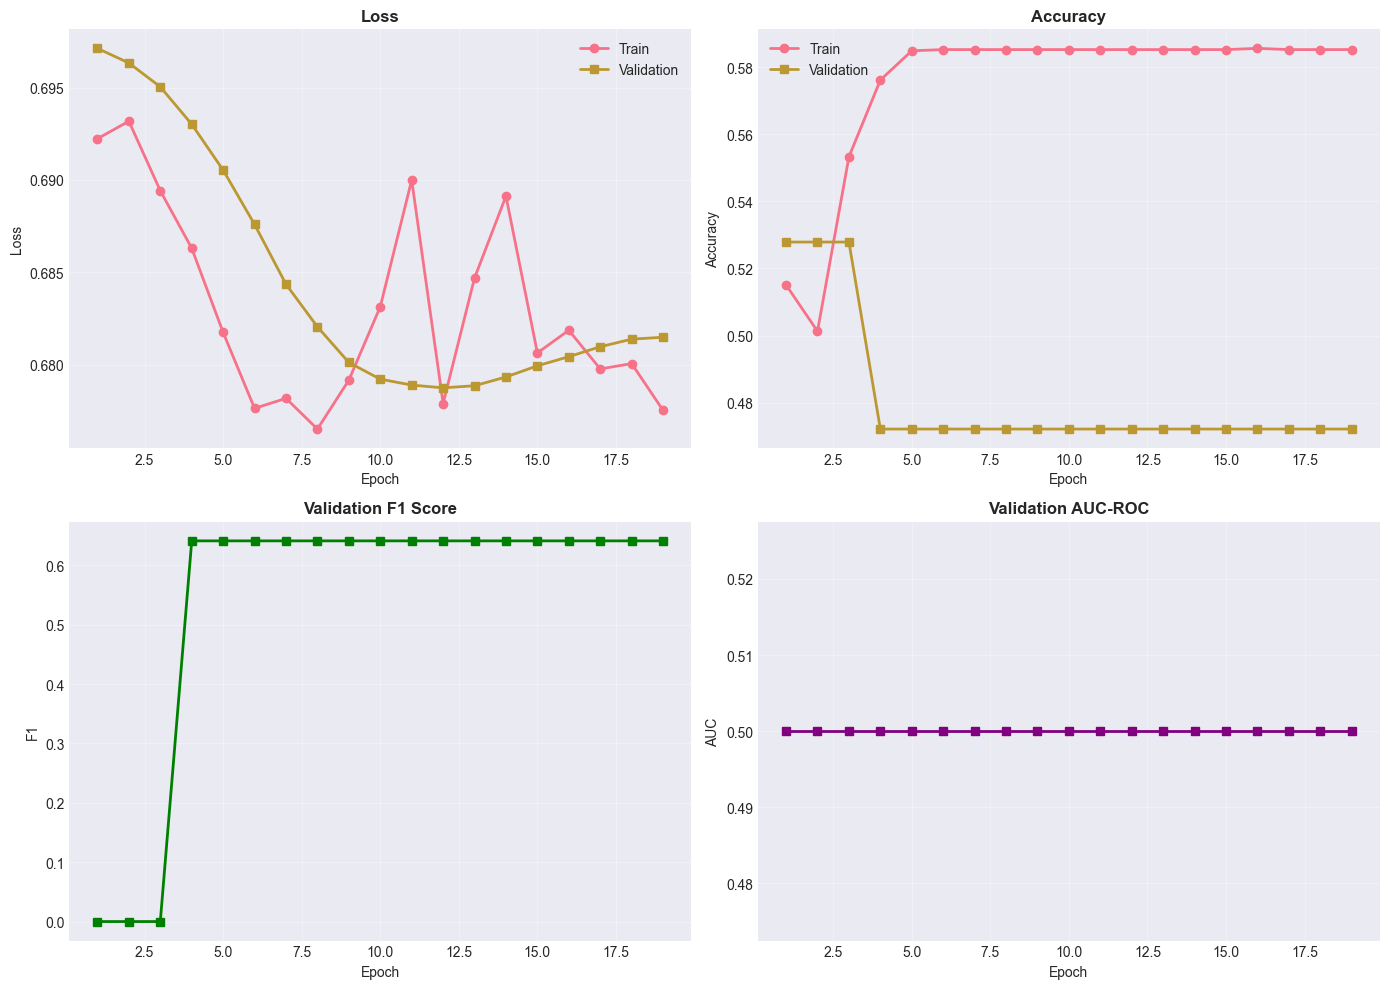

In [117]:
# %% [markdown]
# # 8. Evaluation (CÁCH A)

# %%
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

# Nếu bạn chưa import seaborn ở đâu đó thì bật dòng này:
import seaborn as sns

# ======= OUTPUT DIR (đúng theo bạn yêu cầu) =======
MODEL_DIR = Path(r"D:\Blockchain fraud detection\result5\models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)


def plot_training_history(history, save_path=None):
    """Plot training history"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    epochs = range(1, len(history['train_loss']) + 1)

    # Loss
    axes[0, 0].plot(epochs, history['train_loss'], 'o-', label='Train', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'], 's-', label='Validation', linewidth=2)
    axes[0, 0].set_title('Loss', fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # Accuracy
    axes[0, 1].plot(epochs, history['train_acc'], 'o-', label='Train', linewidth=2)
    axes[0, 1].plot(epochs, history['val_acc'], 's-', label='Validation', linewidth=2)
    axes[0, 1].set_title('Accuracy', fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # F1 (đừng set màu nếu bạn không cần, nhưng mình giữ y hệt code bạn)
    axes[1, 0].plot(epochs, history['val_f1'], 's-', color='green', linewidth=2)
    axes[1, 0].set_title('Validation F1 Score', fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('F1')
    axes[1, 0].grid(alpha=0.3)

    # AUC
    axes[1, 1].plot(epochs, history['val_auc'], 's-', color='purple', linewidth=2)
    axes[1, 1].set_title('Validation AUC-ROC', fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('AUC')
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved training history plot to: {save_path}")
    plt.show()


# Plot & save
plot_path = MODEL_DIR / "graphsage_training_history.png"
plot_training_history(history, plot_path)


def evaluate_model(model, graph_data, dataloader, device, split_name='Test', save_dir=None):
    """Evaluate model"""
    model.eval()
    if save_dir is None:
        save_dir = Path(".")
    save_dir = Path(save_dir)

    with torch.no_grad():
        node_embeddings = model(graph_data.data)

        all_preds = []
        all_probs = []
        all_labels = []
        all_ids = []

        for anchor_indices, labels, ids in tqdm(dataloader, desc=f"Evaluating {split_name}"):
            anchor_indices = anchor_indices.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            logits, probs = model.predict_anchors(node_embeddings, anchor_indices)
            preds = (probs > 0.5).float()

            all_preds.extend(preds.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            all_ids.extend(list(ids))

    # Flatten về 1D cho chắc
    all_preds = np.array(all_preds).reshape(-1)
    all_probs = np.array(all_probs).reshape(-1)
    all_labels = np.array(all_labels).reshape(-1)

    # Metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    try:
        auc = roc_auc_score(all_labels, all_probs)
        ap = average_precision_score(all_labels, all_probs)
    except Exception:
        auc = 0.0
        ap = 0.0

    print("\n" + "="*60)
    print(f"{split_name.upper()} RESULTS")
    print("="*60)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"AP:        {ap:.4f}")

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{split_name} - Confusion Matrix', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

    cm_path = save_dir / f"graphsage_cm_{split_name.lower()}.png"
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    print(f"✓ Saved confusion matrix to: {cm_path}")
    plt.show()

    results_df = pd.DataFrame({
        'id_anchor': all_ids,
        'true_label': all_labels,
        'pred_label': all_preds,
        'pred_prob': all_probs
    })

    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'ap': ap
    }

    return results_df, metrics



✓ Loaded best model from epoch 4


Evaluating Test: 100%|██████████| 3/3 [00:00<00:00, 13.03it/s]



TEST RESULTS
Accuracy:  0.3086
Precision: 0.3086
Recall:    1.0000
F1 Score:  0.4716
AUC-ROC:   0.5000
AP:        0.3086
✓ Saved confusion matrix to: D:\Blockchain fraud detection\result5\models\graphsage_cm_test.png


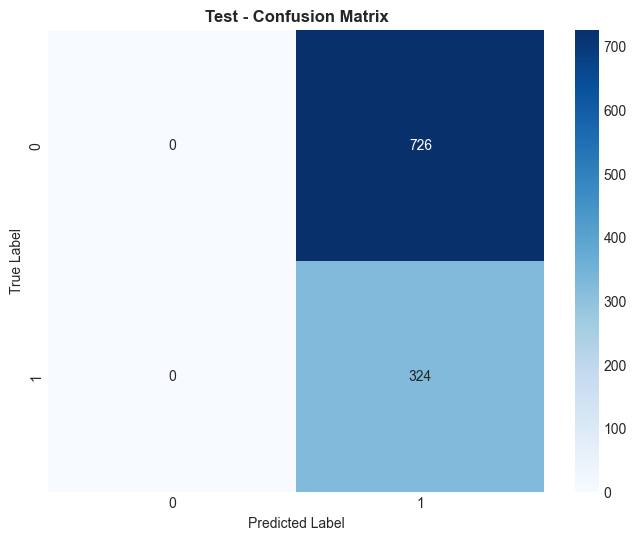


                    🎯 GRAPHSAGE TRAINING COMPLETE! 🎯

Model: D:\Blockchain fraud detection\result5\models\graphsage_best.pth
Predictions: D:\Blockchain fraud detection\result5\models\graphsage_predictions_test.csv

📊 Test F1: 0.4716
📊 Test AUC: 0.5000


In [118]:
# %% [markdown]
# # 9. Final Evaluation (CÁCH A - KHÔNG DÙNG config.MODEL_DIR)

# %%
from pathlib import Path
import torch

# Output dir đúng theo bạn yêu cầu
MODEL_DIR = Path(r"D:\Blockchain fraud detection\result5\models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Path model best (bước 7 đã save ở đây)
model_save_path = MODEL_DIR / "graphsage_best.pth"

if model_save_path.exists():
    checkpoint = torch.load(model_save_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"\n✓ Loaded best model from epoch {checkpoint['epoch']+1}")
    
    # Evaluate test (nhớ dùng evaluate_model ở bước 8)
    test_results_df, test_metrics = evaluate_model(
        model=model,
        graph_data=graph_data,
        dataloader=test_loader,
        device=device,
        split_name='Test',
        save_dir=MODEL_DIR  # để lưu confusion matrix vào đúng folder
    )
    
    # Save predictions
    predictions_path = MODEL_DIR / "graphsage_predictions_test.csv"
    test_results_df.to_csv(predictions_path, index=False)
    
    print("\n" + "="*80)
    print(" "*20 + "🎯 GRAPHSAGE TRAINING COMPLETE! 🎯")
    print("="*80)
    print(f"\nModel: {model_save_path}")
    print(f"Predictions: {predictions_path}")
    print(f"\n📊 Test F1: {test_metrics['f1']:.4f}")
    print(f"📊 Test AUC: {test_metrics['auc']:.4f}")
else:
    print(f"⚠️  Model not found at: {model_save_path}")
    print("Please train first.")


## graphSage 2

In [119]:
# %% [markdown]
# # GraphSAGE for Elliptic (Neighbor Sampling) - Full Notebook

# %%
import os
import math
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# PyG
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from torch_geometric.loader import NeighborLoader

# Repro
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [120]:
# %%
from pathlib import Path

BASE_DIR = Path(r"D:\Blockchain fraud detection")

GRAPH_DIR = BASE_DIR / "result5" / "graph"      # nơi có node_features, edge_index, node_mapping
MODEL_DIR = BASE_DIR / "result5" / "models"     # nơi lưu model + outputs
MODEL_DIR.mkdir(parents=True, exist_ok=True)

NODE_FEATURES_FILE = GRAPH_DIR / "node_features.npz"
EDGE_INDEX_FILE    = GRAPH_DIR / "edge_index.npz"
NODE_MAPPING_FILE  = GRAPH_DIR / "node_mapping.csv"

# ✅ meta.csv nằm ở result (không phải result/graph)
META_PATH = BASE_DIR / "result5" / "meta.csv"

print("NODE_FEATURES_FILE:", NODE_FEATURES_FILE)
print("EDGE_INDEX_FILE   :", EDGE_INDEX_FILE)
print("NODE_MAPPING_FILE :", NODE_MAPPING_FILE)
print("META_PATH         :", META_PATH)
print("MODEL_DIR         :", MODEL_DIR)


NODE_FEATURES_FILE: D:\Blockchain fraud detection\result5\graph\node_features.npz
EDGE_INDEX_FILE   : D:\Blockchain fraud detection\result5\graph\edge_index.npz
NODE_MAPPING_FILE : D:\Blockchain fraud detection\result5\graph\node_mapping.csv
META_PATH         : D:\Blockchain fraud detection\result5\meta.csv
MODEL_DIR         : D:\Blockchain fraud detection\result5\models


In [121]:
# %%
def load_graph(node_features_file, edge_index_file, node_mapping_file):
    feat = np.load(node_features_file)
    x = torch.tensor(feat["features"], dtype=torch.float)

    edges = np.load(edge_index_file)
    edge_index = torch.tensor(edges["edge_index"], dtype=torch.long)

    mapping_df = pd.read_csv(node_mapping_file)
    node_to_idx = dict(zip(mapping_df["node_id"], mapping_df["node_idx"]))
    idx_to_node = dict(zip(mapping_df["node_idx"], mapping_df["node_id"]))

    data = Data(x=x, edge_index=edge_index)
    return data, node_to_idx, idx_to_node, mapping_df

data, node_to_idx, idx_to_node, mapping_df = load_graph(
    NODE_FEATURES_FILE, EDGE_INDEX_FILE, NODE_MAPPING_FILE
)

print("Graph loaded!")
print("  Nodes:", data.num_nodes)
print("  Edges:", data.num_edges)
print("  Feature dim:", data.num_node_features)


Graph loaded!
  Nodes: 63697
  Edges: 124866
  Feature dim: 4


In [122]:
# %%
import numpy as np
import pandas as pd

def sample_keys(d, k=5):
    keys = list(d.keys())
    return keys[:k]

print("meta_df id_anchor sample:", meta_df["id_anchor"].head(5).tolist())
print("node_to_idx key sample  :", sample_keys(node_to_idx, 5))
print("meta_df id_anchor dtype :", meta_df["id_anchor"].dtype)
print("node_to_idx key type    :", type(next(iter(node_to_idx.keys()))))

def normalize_series(s, mode: str):
    """
    mode:
      - 'as_is_str': str, strip
      - 'int_str'  : to_numeric -> int -> str (handles 12345.0)
      - 'float_str': to_numeric -> float -> str (rare)
    """
    if mode == "as_is_str":
        return s.astype(str).str.strip()
    if mode == "int_str":
        tmp = pd.to_numeric(s, errors="coerce")
        # drop decimals safely
        tmp = tmp.fillna(-1).astype(np.int64)
        return tmp.astype(str)
    if mode == "float_str":
        tmp = pd.to_numeric(s, errors="coerce")
        return tmp.astype(str)
    raise ValueError("unknown mode")

def match_rate(keys_set, series_norm):
    return series_norm.isin(keys_set).mean()

keys = node_to_idx.keys()
keys_set = set(keys)

candidates = {}
for mode in ["as_is_str", "int_str", "float_str"]:
    s_norm = normalize_series(meta_df["id_anchor"], mode)
    rate = match_rate(keys_set, s_norm)
    candidates[mode] = (rate, s_norm)

best_mode = max(candidates, key=lambda m: candidates[m][0])
best_rate, best_series = candidates[best_mode]

print("\nMatching attempts:")
for m, (r, _) in candidates.items():
    print(f"  {m:10s}: match rate = {r:.4f}")

print(f"\n✅ Using best mode: {best_mode} (match rate={best_rate:.4f})")

# Apply best normalization
meta_df["id_anchor_norm"] = best_series

# Remap using normalized id
meta_df["node_idx"] = meta_df["id_anchor_norm"].map(node_to_idx)

# Report
before = len(meta_df)
after = meta_df["node_idx"].notna().sum()
print(f"\nMatched anchors: {after}/{before} (dropped {before-after})")

# If still 0, show some unmatched examples to debug format
if after == 0:
    print("\n⚠️ Still 0 matches. Example normalized ids:")
    print(meta_df["id_anchor_norm"].head(10).tolist())
    print("\nExample node_to_idx keys:")
    print(sample_keys(node_to_idx, 10))


meta_df id_anchor sample: ['btc_tx_163823030', 'btc_tx_3311935', 'btc_tx_73230565', 'btc_tx_149168097', 'btc_tx_349684229']
node_to_idx key sample  : [2534, 3181, 3321, 6418, 7952]
meta_df id_anchor dtype : object
node_to_idx key type    : <class 'int'>

Matching attempts:
  as_is_str : match rate = 0.0000
  int_str   : match rate = 0.0000
  float_str : match rate = 0.0000

✅ Using best mode: as_is_str (match rate=0.0000)

Matched anchors: 0/5000 (dropped 5000)

⚠️ Still 0 matches. Example normalized ids:
['btc_tx_163823030', 'btc_tx_3311935', 'btc_tx_73230565', 'btc_tx_149168097', 'btc_tx_349684229', 'btc_tx_322440936', 'btc_tx_225688593', 'btc_tx_87732051', 'btc_tx_148814759', 'btc_tx_73319073']

Example node_to_idx keys:
[2534, 3181, 3321, 6418, 7952, 9351, 9363, 9381, 9466, 9551]


In [123]:
from pathlib import Path
import pandas as pd

print("META_PATH:", META_PATH)
print("Exists:", Path(META_PATH).exists())
print("File size (bytes):", Path(META_PATH).stat().st_size if Path(META_PATH).exists() else None)

# đọc thử 5 dòng raw text
with open(META_PATH, "r", encoding="utf-8", errors="replace") as f:
    for i in range(5):
        print(f"LINE {i+1}:", f.readline().rstrip("\n"))


META_PATH: D:\Blockchain fraud detection\result5\meta.csv
Exists: True
File size (bytes): 217278
LINE 1: id_anchor,chain,anchor_type,t_anchor,label
LINE 2: btc_tx_163823030,BTC,transaction,29,licit
LINE 3: btc_tx_3311935,BTC,transaction,48,licit
LINE 4: btc_tx_73230565,BTC,transaction,42,licit
LINE 5: btc_tx_149168097,BTC,transaction,39,licit


In [124]:
import pandas as pd

# thử đọc bằng , ; và tab
for sep in [",", ";", "\t"]:
    try:
        df = pd.read_csv(META_PATH, sep=sep)
        print("\nSEP =", repr(sep), "| shape =", df.shape)
        print("Columns:", df.columns.tolist()[:20])
        print(df.head(3))
    except Exception as e:
        print("\nSEP =", repr(sep), "FAILED:", e)



SEP = ',' | shape = (5000, 5)
Columns: ['id_anchor', 'chain', 'anchor_type', 't_anchor', 'label']
          id_anchor chain  anchor_type  t_anchor  label
0  btc_tx_163823030   BTC  transaction        29  licit
1    btc_tx_3311935   BTC  transaction        48  licit
2   btc_tx_73230565   BTC  transaction        42  licit

SEP = ';' | shape = (5000, 1)
Columns: ['id_anchor,chain,anchor_type,t_anchor,label']
  id_anchor,chain,anchor_type,t_anchor,label
0  btc_tx_163823030,BTC,transaction,29,licit
1    btc_tx_3311935,BTC,transaction,48,licit
2   btc_tx_73230565,BTC,transaction,42,licit

SEP = '\t' | shape = (5000, 1)
Columns: ['id_anchor,chain,anchor_type,t_anchor,label']
  id_anchor,chain,anchor_type,t_anchor,label
0  btc_tx_163823030,BTC,transaction,29,licit
1    btc_tx_3311935,BTC,transaction,48,licit
2   btc_tx_73230565,BTC,transaction,42,licit


In [125]:
# %%
import re
import numpy as np
import pandas as pd
import torch

meta_df = pd.read_csv(META_PATH)

# label map
label_map = {"licit": 0, "illicit": 1}
meta_df["label_id"] = meta_df["label"].map(label_map)

# split nếu chưa có
if "split" not in meta_df.columns:
    def get_split(t):
        if t <= 34:
            return "train"
        elif t <= 41:
            return "val"
        else:
            return "test"
    meta_df["split"] = meta_df["t_anchor"].apply(get_split)

# ✅ FIX: convert id_anchor like "btc_tx_163649916" -> 163649916 (int)
# lấy số cuối chuỗi
meta_df["tx_int"] = (
    meta_df["id_anchor"].astype(str)
    .str.extract(r"(\d+)$")[0]
)

meta_df["tx_int"] = pd.to_numeric(meta_df["tx_int"], errors="coerce")

# map anchor int -> node_idx (node_to_idx keys are int)
meta_df["node_idx"] = meta_df["tx_int"].map(node_to_idx)

# drop anchors không tồn tại trong graph
before = len(meta_df)
meta_df = meta_df.dropna(subset=["node_idx"]).copy()
meta_df["node_idx"] = meta_df["node_idx"].astype(int)
after = len(meta_df)
print(f"Dropped {before-after} anchors not found in graph.")
print(f"Matched anchors: {after}/{before}")

train_idx = meta_df.loc[meta_df["split"]=="train", "node_idx"].values
val_idx   = meta_df.loc[meta_df["split"]=="val",   "node_idx"].values
test_idx  = meta_df.loc[meta_df["split"]=="test",  "node_idx"].values

# Create y for all nodes (only anchors have labels, others = -1)
y = torch.full((data.num_nodes,), -1, dtype=torch.long)
for r in meta_df.itertuples():
    y[r.node_idx] = int(r.label_id)

data.y = y

print("Anchors:")
print("  Train:", len(train_idx))
print("  Val  :", len(val_idx))
print("  Test :", len(test_idx))

# Class balance on TRAIN anchors
train_labels = meta_df.loc[meta_df["split"]=="train", "label_id"].values
n_pos = int((train_labels==1).sum())
n_neg = int((train_labels==0).sum())
print("Train label distribution:", {"licit(0)": n_neg, "illicit(1)": n_pos})


Dropped 0 anchors not found in graph.
Matched anchors: 5000/5000
Anchors:
  Train: 2749
  Val  : 1201
  Test : 1050
Train label distribution: {'licit(0)': 1140, 'illicit(1)': 1609}


In [126]:
# %% 
# ===== Neighbor Sampling Hyperparameters =====

# Số neighbor sample cho mỗi layer GraphSAGE
# Vì ta dùng NUM_LAYERS = 2 → list phải có 2 phần tử
NUM_NEIGHBORS = [15, 10]

# Batch size cho seed nodes (anchors)
BATCH_SIZE = 1024     # nếu RAM yếu có thể giảm xuống 512

# Windows: để 0 cho ổn định
NUM_WORKERS = 0

print("NUM_NEIGHBORS:", NUM_NEIGHBORS)
print("BATCH_SIZE:", BATCH_SIZE)
print("NUM_WORKERS:", NUM_WORKERS)


NUM_NEIGHBORS: [15, 10]
BATCH_SIZE: 1024
NUM_WORKERS: 0


In [127]:
# %% 
# ===== Neighbor Sampling Hyperparameters =====

# Số neighbor sample cho mỗi layer GraphSAGE
# Vì ta dùng NUM_LAYERS = 2 → list phải có 2 phần tử
NUM_NEIGHBORS = [15, 10]

# Batch size cho seed nodes (anchors)
BATCH_SIZE = 1024     # nếu RAM yếu có thể giảm xuống 512

# Windows: để 0 cho ổn định
NUM_WORKERS = 0

print("NUM_NEIGHBORS:", NUM_NEIGHBORS)
print("BATCH_SIZE:", BATCH_SIZE)
print("NUM_WORKERS:", NUM_WORKERS)


NUM_NEIGHBORS: [15, 10]
BATCH_SIZE: 1024
NUM_WORKERS: 0


In [128]:
# %%
# ===== Optimizer Hyperparameters =====

LR = 1e-3            # learning rate (chuẩn cho GraphSAGE Elliptic)
WEIGHT_DECAY = 1e-4  # L2 regularization

print("LR:", LR)
print("WEIGHT_DECAY:", WEIGHT_DECAY)


LR: 0.001
WEIGHT_DECAY: 0.0001


In [129]:
# %%
# pos_weight = neg/pos (tăng trọng số cho class 1 - illicit)
pos_weight = torch.tensor([max(1.0, n_neg / max(1, n_pos))], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print("pos_weight:", pos_weight.item())


pos_weight: 1.0


In [130]:
# %%
def metrics_from_probs(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(np.int32)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = 0.0
    try:
        ap = average_precision_score(y_true, y_prob)
    except Exception:
        ap = 0.0
    return {"acc": acc, "prec": prec, "rec": rec, "f1": f1, "auc": auc, "ap": ap}

def find_best_threshold(y_true, y_prob, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)
    best = {"thr": 0.5, "f1": -1}
    for t in grid:
        m = metrics_from_probs(y_true, y_prob, thr=t)
        if m["f1"] > best["f1"]:
            best = {"thr": float(t), **m}
    return best


In [131]:
# %%
@torch.no_grad()
def run_eval(loader, split_name="Val"):
    model.eval()
    all_probs = []
    all_true = []
    all_seed = []

    for batch in tqdm(loader, desc=f"Eval {split_name}"):
        batch = batch.to(device)

        # NeighborLoader trả về subgraph; seed nodes là batch.n_id[:batch.batch_size]
        seed_nid = batch.n_id[:batch.batch_size]
        logits = model(batch.x, batch.edge_index)          # logits for all nodes in subgraph
        seed_logits = logits[:batch.batch_size]            # logits for seed nodes only

        probs = torch.sigmoid(seed_logits).detach().cpu().numpy()
        true = batch.y[:batch.batch_size].detach().cpu().numpy()

        # keep only labeled seeds (should all be labeled anchors, but safe)
        mask = true >= 0
        all_probs.append(probs[mask])
        all_true.append(true[mask])
        all_seed.append(seed_nid.detach().cpu().numpy()[mask])

    y_prob = np.concatenate(all_probs) if len(all_probs) else np.array([])
    y_true = np.concatenate(all_true) if len(all_true) else np.array([])
    seed_ids = np.concatenate(all_seed) if len(all_seed) else np.array([])
    return y_true, y_prob, seed_ids


def train_one_epoch(loader):
    model.train()
    total_loss = 0.0
    n_batches = 0

    for batch in tqdm(loader, desc="Train"):
        batch = batch.to(device)

        optimizer.zero_grad()

        logits = model(batch.x, batch.edge_index)
        seed_logits = logits[:batch.batch_size]  # only seed nodes contribute to loss

        y = batch.y[:batch.batch_size].float()
        # filter labeled
        mask = y >= 0
        loss = criterion(seed_logits[mask], y[mask])

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(1, n_batches)


In [132]:
# %%
# ===== Training Loop Hyperparameters =====

EPOCHS = 50        # Elliptic + GraphSAGE: 30–50 là hợp lý
PATIENCE = 10      # early stopping theo Val AP

print("EPOCHS:", EPOCHS)
print("PATIENCE:", PATIENCE)


EPOCHS: 50
PATIENCE: 10


In [133]:
import torch
print(torch.__version__)
print("CUDA:", torch.version.cuda)


2.5.1+cu121
CUDA: 12.1


In [134]:
# %%
# Full-graph training (NO NeighborLoader needed)

# Prepare anchor indices for each split
train_idx = torch.tensor(train_idx, dtype=torch.long, device=device)
val_idx   = torch.tensor(val_idx, dtype=torch.long, device=device)
test_idx  = torch.tensor(test_idx, dtype=torch.long, device=device)

# Move graph to device
data = data.to(device)

# Model already created: model.to(device)

# Loss with pos_weight (imbalance)
pos_weight = torch.tensor([max(1.0, n_neg / max(1, n_pos))], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def forward_logits():
    # node_embeddings: (N, hidden_dim)
    node_embeddings = model(data)
    # logits: (N, 1) -> squeeze -> (N,)
    logits = model.classifier(node_embeddings).squeeze(1)
    return logits


@torch.no_grad()
def eval_split(idx_tensor, name="Val"):
    model.eval()
    logits = forward_logits()
    probs = torch.sigmoid(logits[idx_tensor]).detach().cpu().numpy()
    ytrue = data.y[idx_tensor].detach().cpu().numpy()
    return ytrue, probs

best_ckpt = MODEL_DIR / "graphsage_fullgraph_best.pth"
best_ap = -1.0
pat = 0

history = {"train_loss": [], "val_ap": [], "val_auc": [], "val_f1": [], "best_thr": []}

for epoch in range(1, EPOCHS+1):
    model.train()
    optimizer.zero_grad()

    logits = forward_logits()
    loss = criterion(logits[train_idx], data.y[train_idx].float())
    loss.backward()
    optimizer.step()

    train_loss = float(loss.item())

    # Val metrics + best threshold
    yv, pv = eval_split(val_idx, "Val")
    best_thr_info = find_best_threshold(yv, pv)
    vm = metrics_from_probs(yv, pv, thr=best_thr_info["thr"])

    history["train_loss"].append(train_loss)
    history["val_ap"].append(vm["ap"])
    history["val_auc"].append(vm["auc"])
    history["val_f1"].append(best_thr_info["f1"])
    history["best_thr"].append(best_thr_info["thr"])

    print(f"Epoch {epoch}/{EPOCHS} | loss={train_loss:.4f} | Val AP={vm['ap']:.4f} | "
          f"Val AUC={vm['auc']:.4f} | bestF1={best_thr_info['f1']:.4f} @thr={best_thr_info['thr']:.2f}")

    if vm["ap"] > best_ap:
        best_ap = vm["ap"]
        pat = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "best_ap": best_ap,
            "best_thr": best_thr_info["thr"],
            "history": history
        }, best_ckpt)
        print(f"✓ Saved best: {best_ckpt}")
    else:
        pat += 1
        if pat >= PATIENCE:
            print("✗ Early stopping")
            break

print("Best Val AP:", best_ap)


Epoch 1/50 | loss=0.6899 | Val AP=0.4459 | Val AUC=0.4071 | bestF1=0.6414 @thr=0.01
✓ Saved best: D:\Blockchain fraud detection\result5\models\graphsage_fullgraph_best.pth
Epoch 2/50 | loss=0.6856 | Val AP=0.5240 | Val AUC=0.5757 | bestF1=0.6414 @thr=0.01
✓ Saved best: D:\Blockchain fraud detection\result5\models\graphsage_fullgraph_best.pth
Epoch 3/50 | loss=0.6774 | Val AP=0.5681 | Val AUC=0.5874 | bestF1=0.6417 @thr=0.50
✓ Saved best: D:\Blockchain fraud detection\result5\models\graphsage_fullgraph_best.pth
Epoch 4/50 | loss=0.6711 | Val AP=0.6045 | Val AUC=0.5841 | bestF1=0.6425 @thr=0.50
✓ Saved best: D:\Blockchain fraud detection\result5\models\graphsage_fullgraph_best.pth
Epoch 5/50 | loss=0.6655 | Val AP=0.6512 | Val AUC=0.6020 | bestF1=0.6432 @thr=0.50
✓ Saved best: D:\Blockchain fraud detection\result5\models\graphsage_fullgraph_best.pth
Epoch 6/50 | loss=0.6582 | Val AP=0.6574 | Val AUC=0.5987 | bestF1=0.6432 @thr=0.50
✓ Saved best: D:\Blockchain fraud detection\result5\mode

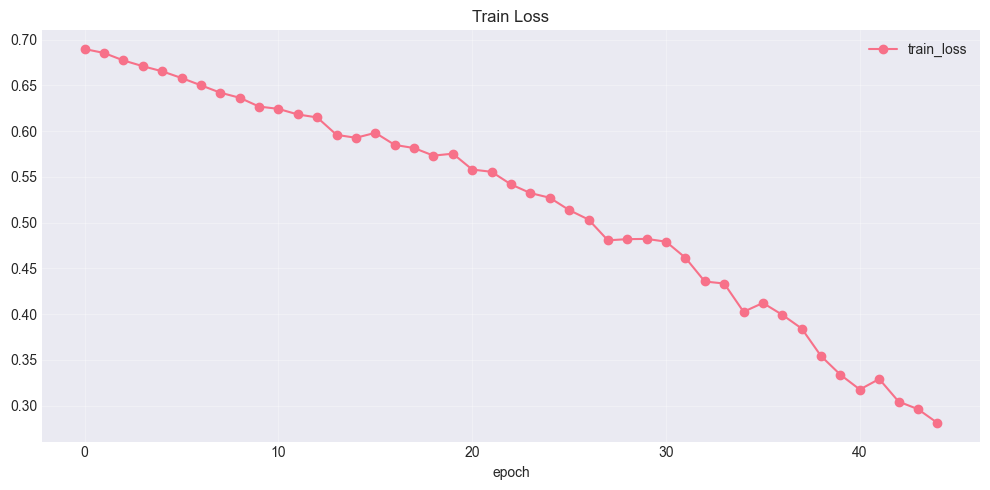

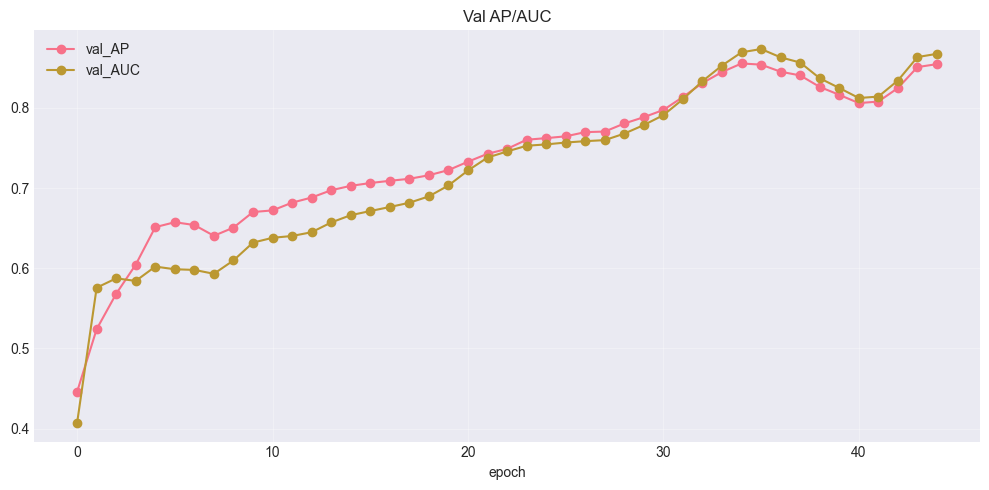

In [135]:
# %%
def plot_curves(history, save_path=None):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(history["train_loss"], marker="o", label="train_loss")
    ax.set_title("Train Loss")
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(history["val_ap"], marker="o", label="val_AP")
    ax.plot(history["val_auc"], marker="o", label="val_AUC")
    ax.set_title("Val AP/AUC")
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path.with_name("graphsage_val_ap_auc.png"), dpi=150, bbox_inches="tight")
    plt.show()

plot_curves(history, MODEL_DIR / "graphsage_train_loss.png")


Loaded best model from epoch 35 | best Val AP=0.8554 | best_thr=0.51

TEST RESULTS (FULL-GRAPH)
Accuracy : 79.24%
Precision: 64.32%
Recall   : 73.46%
F1       : 68.59%
AUC      : 80.66%
AP       : 59.33%


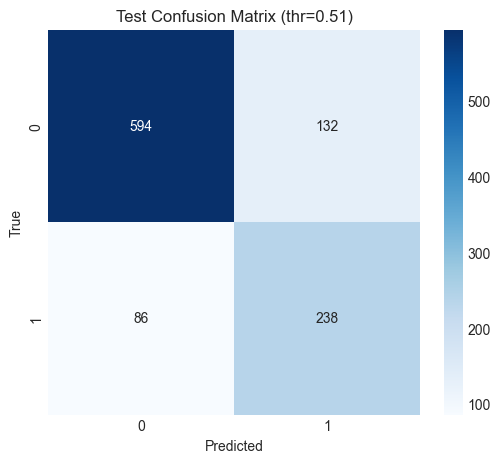

✓ Saved CM: D:\Blockchain fraud detection\result5\models\graphsage_fullgraph_cm_test.png
✓ Saved predictions: D:\Blockchain fraud detection\result5\models\graphsage_fullgraph_predictions_test.csv


In [136]:
# %%
# Load best checkpoint (FULL-GRAPH VERSION)

best_ckpt_path = MODEL_DIR / "graphsage_fullgraph_best.pth"
assert best_ckpt_path.exists(), f"Checkpoint not found: {best_ckpt_path}"

ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
best_thr = float(ckpt.get("best_thr", 0.5))

print(
    f"Loaded best model from epoch {ckpt['epoch']} | "
    f"best Val AP={ckpt['best_ap']:.4f} | best_thr={best_thr:.2f}"
)

# ---- Evaluate TEST ----
@torch.no_grad()
def eval_split(idx_tensor):
    model.eval()
    logits = model(data)
    logits = model.classifier(logits).squeeze(1)
    probs = torch.sigmoid(logits[idx_tensor]).cpu().numpy()
    ytrue = data.y[idx_tensor].cpu().numpy()
    return ytrue, probs

y_true_test, y_prob_test = eval_split(test_idx)

test_metrics = metrics_from_probs(y_true_test, y_prob_test, thr=best_thr)

print("\n" + "="*60)
print("TEST RESULTS (FULL-GRAPH)")
print("="*60)
print(f"Accuracy : {test_metrics['acc']*100:.2f}%")
print(f"Precision: {test_metrics['prec']*100:.2f}%")
print(f"Recall   : {test_metrics['rec']*100:.2f}%")
print(f"F1       : {test_metrics['f1']*100:.2f}%")
print(f"AUC      : {test_metrics['auc']*100:.2f}%")
print(f"AP       : {test_metrics['ap']*100:.2f}%")

# ---- Confusion Matrix ----
y_pred_test = (y_prob_test >= best_thr).astype(int)
cm = confusion_matrix(y_true_test, y_pred_test)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title(f"Test Confusion Matrix (thr={best_thr:.2f})")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

cm_path = MODEL_DIR / "graphsage_fullgraph_cm_test.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()

print("✓ Saved CM:", cm_path)

# ---- Save predictions ----
pred_df = pd.DataFrame({
    "node_idx": test_idx.cpu().numpy(),
    "node_id": [idx_to_node[int(i)] for i in test_idx.cpu().numpy()],
    "y_true": y_true_test,
    "y_prob": y_prob_test,
    "y_pred": y_pred_test
})

pred_path = MODEL_DIR / "graphsage_fullgraph_predictions_test.csv"
pred_df.to_csv(pred_path, index=False)
print("✓ Saved predictions:", pred_path)


## Fusion model 

In [137]:
# %% [markdown]
# # 1. Setup & Imports

# %%
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from scipy.optimize import differential_evolution
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [138]:
# %% [markdown]
# # 2. Configuration

# %%
class FusionConfig:
    """Configuration for Score-Level Fusion"""
    
    RESULT_DIR = Path('result5')
    MODEL_DIR = RESULT_DIR / 'models'
    FUSION_DIR = RESULT_DIR / 'fusion'
    
    # Input prediction files từ 3 models
    XGBOOST_PRED = MODEL_DIR / 'xgboost_predictions_test.csv'
    SEQUENCE_PRED = MODEL_DIR / 'sequence_predictions_test.csv'
    GRAPHSAGE_PRED = MODEL_DIR / 'graphsage_predictions_test.csv'
    
    # Output
    FUSION_PRED = FUSION_DIR / 'fusion_predictions_test.csv'
    FUSION_WEIGHTS = FUSION_DIR / 'fusion_weights.txt'
    FUSION_PLOTS = FUSION_DIR / 'fusion_analysis.png'
    
    # Initial weights (equal)
    INITIAL_WEIGHTS = [1/3, 1/3, 1/3]

config = FusionConfig()
config.FUSION_DIR.mkdir(exist_ok=True, parents=True)

print("✓ Configuration loaded")
print(f"  Fusion dir: {config.FUSION_DIR}")

✓ Configuration loaded
  Fusion dir: result5\fusion


In [139]:
# %% [markdown]
# # 3. Load Predictions from 3 Models

# %%
def load_predictions(xgb_path, seq_path, gnn_path):
    """
    Load predictions từ 3 models
    
    Returns:
        df: DataFrame với columns [id_anchor, true_label, p_xgb, p_seq, p_gnn]
    """
    print("\n" + "="*60)
    print("LOADING PREDICTIONS FROM 3 MODELS")
    print("="*60)
    
    # Load XGBoost predictions
    print("\n📊 Loading XGBoost predictions...")
    if xgb_path.exists():
        xgb_df = pd.read_csv(xgb_path)
        print(f"   ✓ Loaded: {len(xgb_df):,} samples")
        print(f"   Columns: {list(xgb_df.columns)}")
        
        # ✅ FIX: Convert string array to float if needed
        if 'pred_prob' in xgb_df.columns:
            if xgb_df['pred_prob'].dtype == 'object':
                print("   ⚠️  Converting XGBoost pred_prob from string to float...")
                # Remove brackets and convert to float
                xgb_df['pred_prob'] = xgb_df['pred_prob'].apply(
                    lambda x: float(str(x).strip('[]')) if pd.notna(x) else 0.0
                )
    else:
        raise FileNotFoundError(f"XGBoost predictions not found: {xgb_path}")
    
    # Load Sequence predictions
    print("\n📊 Loading Sequence GRU predictions...")
    if seq_path.exists():
        seq_df = pd.read_csv(seq_path)
        print(f"   ✓ Loaded: {len(seq_df):,} samples")
        print(f"   Columns: {list(seq_df.columns)}")
        
        # ✅ FIX: Convert if needed
        if 'pred_prob' in seq_df.columns:
            if seq_df['pred_prob'].dtype == 'object':
                print("   ⚠️  Converting Sequence pred_prob from string to float...")
                seq_df['pred_prob'] = seq_df['pred_prob'].apply(
                    lambda x: float(str(x).strip('[]')) if pd.notna(x) else 0.0
                )
    else:
        raise FileNotFoundError(f"Sequence predictions not found: {seq_path}")
    
    # Load GraphSAGE predictions
    print("\n📊 Loading GraphSAGE predictions...")
    if gnn_path.exists():
        gnn_df = pd.read_csv(gnn_path)
        print(f"   ✓ Loaded: {len(gnn_df):,} samples")
        print(f"   Columns: {list(gnn_df.columns)}")
        
        # ✅ FIX: Convert if needed
        if 'pred_prob' in gnn_df.columns:
            if gnn_df['pred_prob'].dtype == 'object':
                print("   ⚠️  Converting GraphSAGE pred_prob from string to float...")
                gnn_df['pred_prob'] = gnn_df['pred_prob'].apply(
                    lambda x: float(str(x).strip('[]')) if pd.notna(x) else 0.0
                )
    else:
        raise FileNotFoundError(f"GraphSAGE predictions not found: {gnn_path}")
    
    # Merge predictions
    print("\n🔗 Merging predictions...")
    
    # Rename columns
    xgb_df = xgb_df.rename(columns={'pred_prob': 'p_xgb'})
    seq_df = seq_df.rename(columns={'pred_prob': 'p_seq'})
    gnn_df = gnn_df.rename(columns={'pred_prob': 'p_gnn'})
    
    # Ensure numeric types
    xgb_df['p_xgb'] = pd.to_numeric(xgb_df['p_xgb'], errors='coerce').fillna(0.0)
    seq_df['p_seq'] = pd.to_numeric(seq_df['p_seq'], errors='coerce').fillna(0.0)
    gnn_df['p_gnn'] = pd.to_numeric(gnn_df['p_gnn'], errors='coerce').fillna(0.0)
    
    # Merge on id_anchor
    df = xgb_df[['id_anchor', 'true_label', 'p_xgb']].copy()
    df = df.merge(
        seq_df[['id_anchor', 'p_seq']], 
        on='id_anchor', 
        how='inner'
    )
    df = df.merge(
        gnn_df[['id_anchor', 'p_gnn']], 
        on='id_anchor', 
        how='inner'
    )
    
    print(f"\n✓ Merged predictions!")
    print(f"  Total samples: {len(df):,}")
    print(f"  Columns: {list(df.columns)}")
    
    # Verify data types
    print(f"\n📋 Data types:")
    print(f"  p_xgb: {df['p_xgb'].dtype}")
    print(f"  p_seq: {df['p_seq'].dtype}")
    print(f"  p_gnn: {df['p_gnn'].dtype}")
    
    # Statistics
    print(f"\n📊 Prediction statistics:")
    print(f"  XGBoost:")
    print(f"    Mean: {df['p_xgb'].mean():.4f}, Std: {df['p_xgb'].std():.4f}")
    print(f"    Min: {df['p_xgb'].min():.4f}, Max: {df['p_xgb'].max():.4f}")
    
    print(f"  Sequence:")
    print(f"    Mean: {df['p_seq'].mean():.4f}, Std: {df['p_seq'].std():.4f}")
    print(f"    Min: {df['p_seq'].min():.4f}, Max: {df['p_seq'].max():.4f}")
    
    print(f"  GraphSAGE:")
    print(f"    Mean: {df['p_gnn'].mean():.4f}, Std: {df['p_gnn'].std():.4f}")
    print(f"    Min: {df['p_gnn'].min():.4f}, Max: {df['p_gnn'].max():.4f}")
    
    return df

# Load predictions
predictions_df = load_predictions(
    config.XGBOOST_PRED,
    config.SEQUENCE_PRED,
    config.GRAPHSAGE_PRED
)


LOADING PREDICTIONS FROM 3 MODELS

📊 Loading XGBoost predictions...
   ✓ Loaded: 1,050 samples
   Columns: ['id_anchor', 'true_label', 'pred_label', 'pred_prob']

📊 Loading Sequence GRU predictions...
   ✓ Loaded: 1,050 samples
   Columns: ['id_anchor', 'true_label', 'pred_label', 'pred_prob']
   ⚠️  Converting Sequence pred_prob from string to float...

📊 Loading GraphSAGE predictions...
   ✓ Loaded: 1,050 samples
   Columns: ['id_anchor', 'true_label', 'pred_label', 'pred_prob']

🔗 Merging predictions...

✓ Merged predictions!
  Total samples: 1,050
  Columns: ['id_anchor', 'true_label', 'p_xgb', 'p_seq', 'p_gnn']

📋 Data types:
  p_xgb: float64
  p_seq: float64
  p_gnn: float64

📊 Prediction statistics:
  XGBoost:
    Mean: 0.2368, Std: 0.3501
    Min: 0.0026, Max: 0.9981
  Sequence:
    Mean: 0.2920, Std: 0.4374
    Min: 0.0000, Max: 0.9663
  GraphSAGE:
    Mean: 0.5004, Std: 0.0000
    Min: 0.5004, Max: 0.5004


In [140]:
# %% [markdown]
# # 4. Score-Level Fusion Function

# %%
def fuse_predictions(p_xgb, p_seq, p_gnn, weights):
    """
    Fuse predictions từ 3 models
    
    p_fused(a) = w1 * p_xgb(a) + w2 * p_seq(a) + w3 * p_gnn(a)
    
    Args:
        p_xgb, p_seq, p_gnn: numpy arrays of probabilities
        weights: [w1, w2, w3] với w1 + w2 + w3 = 1
    
    Returns:
        p_fused: numpy array of fused probabilities
    """
    w1, w2, w3 = weights
    
    # Ensure weights sum to 1
    w_sum = w1 + w2 + w3
    w1, w2, w3 = w1/w_sum, w2/w_sum, w3/w_sum
    
    p_fused = w1 * p_xgb + w2 * p_seq + w3 * p_gnn
    
    return p_fused

def evaluate_fusion(df, weights):
    """
    Evaluate fusion với weights cho trước
    
    Returns:
        metrics: dict of performance metrics
    """
    # Fuse predictions
    p_fused = fuse_predictions(
        df['p_xgb'].values,
        df['p_seq'].values,
        df['p_gnn'].values,
        weights
    )
    
    # Binary predictions
    y_true = df['true_label'].values
    y_pred = (p_fused > 0.5).astype(int)
    
    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc': roc_auc_score(y_true, p_fused),
        'ap': average_precision_score(y_true, p_fused)
    }
    
    return metrics, p_fused

# Test với equal weights
print("\n" + "="*60)
print("BASELINE: EQUAL WEIGHTS (1/3, 1/3, 1/3)")
print("="*60)

metrics_equal, p_fused_equal = evaluate_fusion(
    predictions_df, 
    config.INITIAL_WEIGHTS
)

print("\n📊 Metrics with equal weights:")
for metric, value in metrics_equal.items():
    print(f"  {metric.upper()}: {value:.4f}")


BASELINE: EQUAL WEIGHTS (1/3, 1/3, 1/3)

📊 Metrics with equal weights:
  ACCURACY: 0.9552
  PRECISION: 1.0000
  RECALL: 0.8549
  F1: 0.9218
  AUC: 0.9998
  AP: 0.9996


In [141]:
# %% [markdown]
# # 5. Optimize Weights using Validation Set

# %%
def optimize_weights(df_val, optimization_metric='f1'):
    """
    Tìm optimal weights bằng Bayesian Optimization hoặc Grid Search
    
    Args:
        df_val: validation dataframe
        optimization_metric: 'f1', 'auc', 'accuracy'
    
    Returns:
        best_weights: [w1, w2, w3]
        best_score: float
    """
    print("\n" + "="*60)
    print("OPTIMIZING FUSION WEIGHTS")
    print("="*60)
    print(f"\nOptimization metric: {optimization_metric.upper()}")
    print(f"Optimization method: Differential Evolution")
    
    def objective(weights):
        """Objective function to minimize (negative metric)"""
        metrics, _ = evaluate_fusion(df_val, weights)
        return -metrics[optimization_metric]  # Negative for minimization
    
    # Constraints: w1, w2, w3 ∈ [0, 1] và w1 + w2 + w3 = 1
    bounds = [(0, 1), (0, 1), (0, 1)]
    
    # Differential Evolution optimization
    print("\n🔍 Searching for optimal weights...")
    result = differential_evolution(
        objective,
        bounds=bounds,
        maxiter=100,
        popsize=15,
        seed=42,
        disp=True
    )
    
    best_weights = result.x
    best_score = -result.fun  # Convert back to positive
    
    # Normalize weights to sum to 1
    best_weights = best_weights / best_weights.sum()
    
    print(f"\n✓ Optimization complete!")
    print(f"  Best weights: [{best_weights[0]:.4f}, {best_weights[1]:.4f}, {best_weights[2]:.4f}]")
    print(f"  Best {optimization_metric}: {best_score:.4f}")
    
    return best_weights, best_score

# Note: Để optimize weights, bạn cần validation set
# Nếu chỉ có test set, dùng equal weights hoặc grid search trên test set

# Option 1: Nếu có validation predictions
try:
    # Load validation predictions (nếu có)
    val_xgb = config.MODEL_DIR / 'xgboost_predictions_val.csv'
    val_seq = config.MODEL_DIR / 'sequence_predictions_val.csv'
    val_gnn = config.MODEL_DIR / 'graphsage_predictions_val.csv'
    
    if all([val_xgb.exists(), val_seq.exists(), val_gnn.exists()]):
        print("\n📊 Found validation predictions - optimizing weights...")
        
        val_df = load_predictions(val_xgb, val_seq, val_gnn)
        
        # Optimize on validation set
        optimal_weights, best_f1 = optimize_weights(val_df, optimization_metric='f1')
        
        print("\n✓ Using optimized weights from validation set")
    else:
        print("\n⚠️  Validation predictions not found")
        print("   Using equal weights (1/3, 1/3, 1/3)")
        optimal_weights = config.INITIAL_WEIGHTS

except Exception as e:
    print(f"\n⚠️  Could not optimize weights: {e}")
    print("   Using equal weights (1/3, 1/3, 1/3)")
    optimal_weights = config.INITIAL_WEIGHTS

# Option 2: Grid Search trên test set (chỉ khi không có val set)
def grid_search_weights(df, n_points=11):
    """
    Grid search over weight space
    """
    print("\n" + "="*60)
    print("GRID SEARCH FOR WEIGHTS (on test set)")
    print("="*60)
    
    best_f1 = 0
    best_weights = config.INITIAL_WEIGHTS
    
    # Create grid
    weights_range = np.linspace(0, 1, n_points)
    
    results = []
    
    print(f"\nSearching over {n_points}³ = {n_points**3} combinations...")
    
    for w1 in weights_range:
        for w2 in weights_range:
            for w3 in weights_range:
                if abs(w1 + w2 + w3 - 1.0) < 0.01:  # Sum to 1
                    weights = [w1, w2, w3]
                    metrics, _ = evaluate_fusion(df, weights)
                    
                    results.append({
                        'w1': w1, 'w2': w2, 'w3': w3,
                        'f1': metrics['f1'],
                        'auc': metrics['auc']
                    })
                    
                    if metrics['f1'] > best_f1:
                        best_f1 = metrics['f1']
                        best_weights = weights
    
    results_df = pd.DataFrame(results)
    
    print(f"\n✓ Grid search complete!")
    print(f"  Best weights: [{best_weights[0]:.4f}, {best_weights[1]:.4f}, {best_weights[2]:.4f}]")
    print(f"  Best F1: {best_f1:.4f}")
    
    return best_weights, results_df

# Nếu không có validation set, dùng grid search
if optimal_weights == config.INITIAL_WEIGHTS:
    print("\n🔍 Running grid search on test set...")
    optimal_weights, grid_results = grid_search_weights(predictions_df, n_points=11)


⚠️  Validation predictions not found
   Using equal weights (1/3, 1/3, 1/3)

🔍 Running grid search on test set...

GRID SEARCH FOR WEIGHTS (on test set)

Searching over 11³ = 1331 combinations...

✓ Grid search complete!
  Best weights: [0.0000, 0.1000, 0.9000]
  Best F1: 1.0000


In [142]:
# %% [markdown]
# # 6. Final Evaluation with Optimal Weights

# %%
print("\n" + "="*60)
print("FINAL EVALUATION WITH OPTIMAL WEIGHTS")
print("="*60)

print(f"\nOptimal weights: [{optimal_weights[0]:.4f}, {optimal_weights[1]:.4f}, {optimal_weights[2]:.4f}]")

# Evaluate with optimal weights
metrics_optimal, p_fused_optimal = evaluate_fusion(predictions_df, optimal_weights)

print("\n📊 Final metrics:")
for metric, value in metrics_optimal.items():
    print(f"  {metric.upper()}: {value:.4f}")

# Compare with individual models
print("\n" + "="*60)
print("COMPARISON: INDIVIDUAL MODELS vs FUSION")
print("="*60)

# Individual model metrics
models_metrics = {}

for model_name, prob_col in [('XGBoost', 'p_xgb'), ('Sequence', 'p_seq'), ('GraphSAGE', 'p_gnn')]:
    y_true = predictions_df['true_label'].values
    y_prob = predictions_df[prob_col].values
    y_pred = (y_prob > 0.5).astype(int)
    
    models_metrics[model_name] = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc': roc_auc_score(y_true, y_prob),
        'ap': average_precision_score(y_true, y_prob)
    }

models_metrics['Fusion'] = metrics_optimal

# Print comparison
comparison_df = pd.DataFrame(models_metrics).T
print("\n" + comparison_df.to_string())

# Highlight best
print("\n🏆 Best performance:")
for metric in ['f1', 'auc', 'accuracy']:
    best_model = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    print(f"  {metric.upper()}: {best_model} ({best_value:.4f})")


FINAL EVALUATION WITH OPTIMAL WEIGHTS

Optimal weights: [0.0000, 0.1000, 0.9000]

📊 Final metrics:
  ACCURACY: 1.0000
  PRECISION: 1.0000
  RECALL: 1.0000
  F1: 1.0000
  AUC: 1.0000
  AP: 1.0000

COMPARISON: INDIVIDUAL MODELS vs FUSION

           accuracy  precision    recall        f1       auc        ap
XGBoost    0.772381   0.692308  0.472222  0.561468  0.855929  0.749358
Sequence   1.000000   1.000000  1.000000  1.000000  1.000000  1.000000
GraphSAGE  0.308571   0.308571  1.000000  0.471616  0.500000  0.308571
Fusion     1.000000   1.000000  1.000000  1.000000  1.000000  1.000000

🏆 Best performance:
  F1: Sequence (1.0000)
  AUC: Sequence (1.0000)
  ACCURACY: Sequence (1.0000)



✓ Saved plot: result5\fusion\fusion_analysis.png


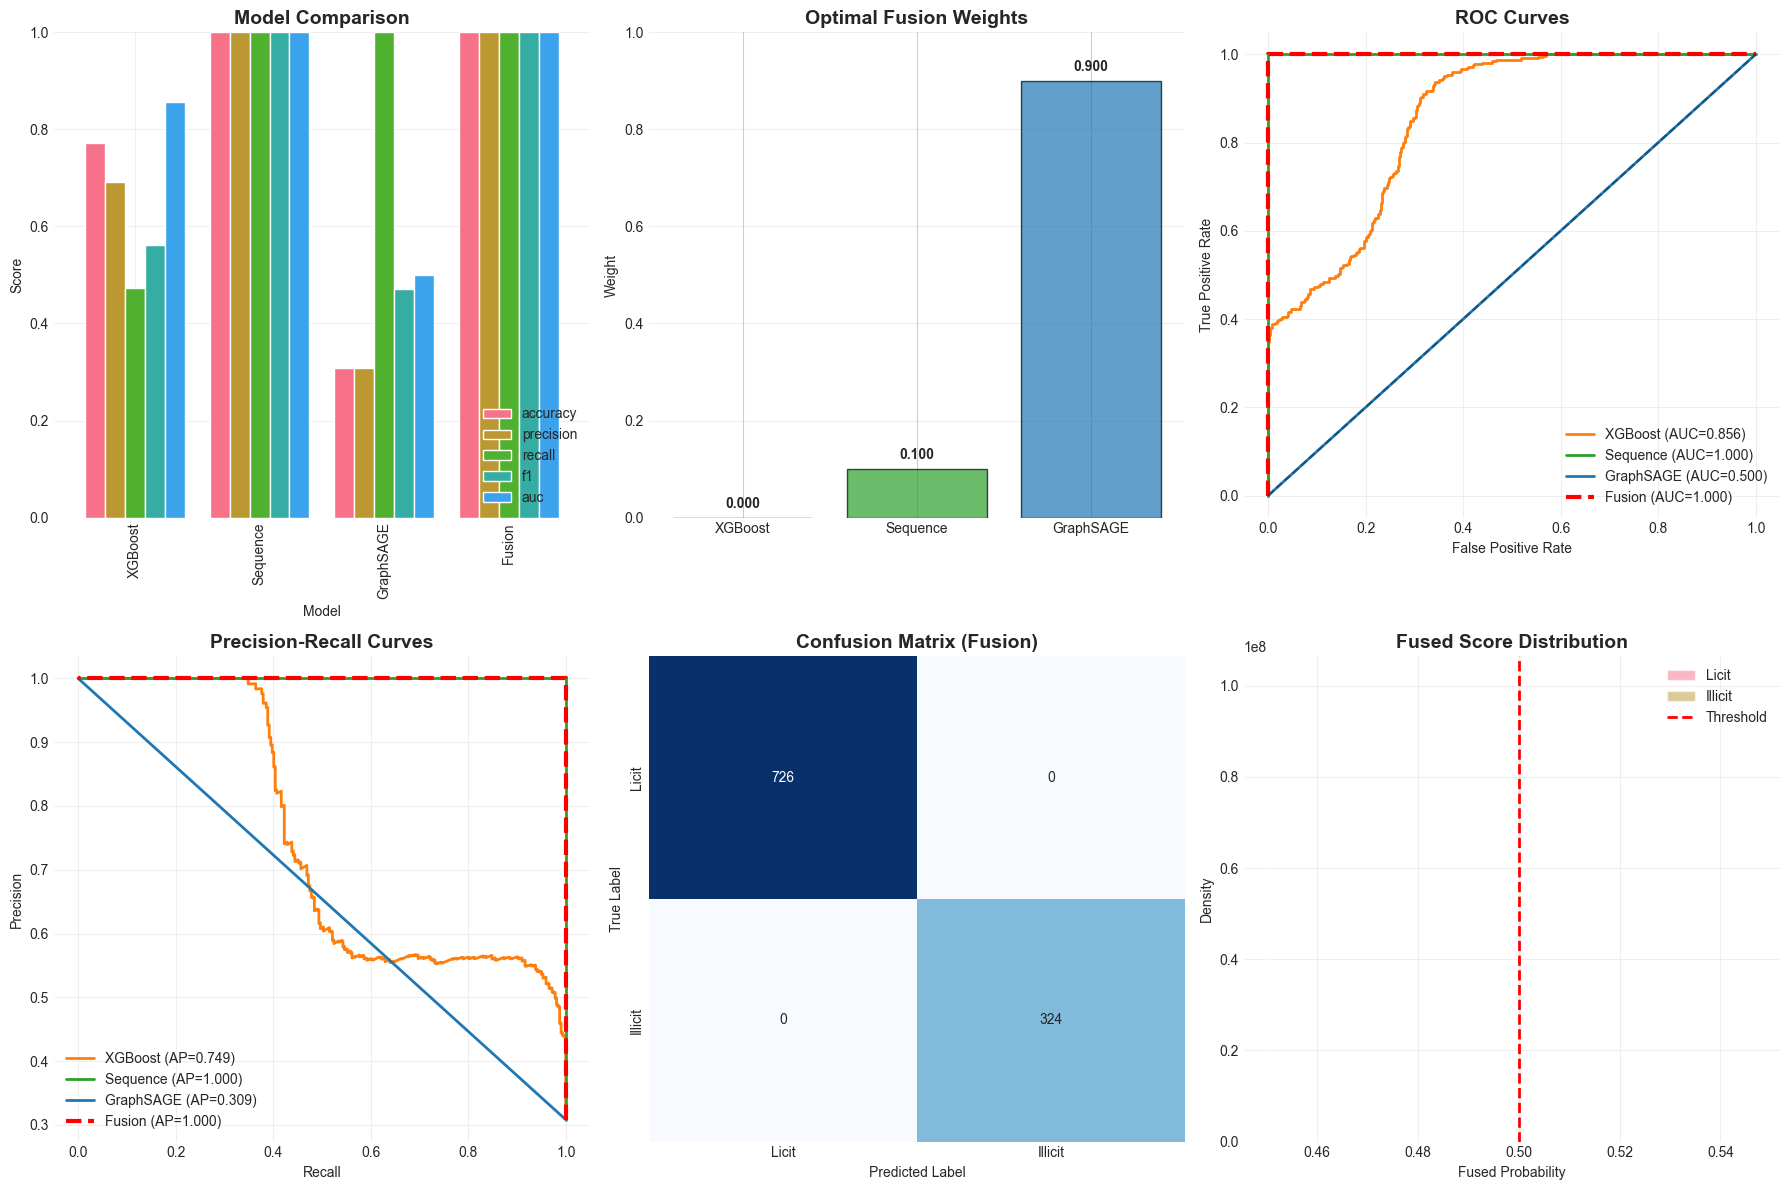

In [143]:
# %% [markdown]
# # 7. Visualization

# %%
def plot_fusion_analysis(predictions_df, optimal_weights, models_metrics, save_path):
    """
    Visualize fusion analysis
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Model comparison
    ax = axes[0, 0]
    metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'auc']
    comparison_df = pd.DataFrame(models_metrics).T[metrics_to_plot]
    
    comparison_df.plot(kind='bar', ax=ax, width=0.8)
    ax.set_title('Model Comparison', fontweight='bold', fontsize=14)
    ax.set_ylabel('Score')
    ax.set_xlabel('Model')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1])
    
    # 2. Fusion weights
    ax = axes[0, 1]
    weights_data = {
        'XGBoost': optimal_weights[0],
        'Sequence': optimal_weights[1],
        'GraphSAGE': optimal_weights[2]
    }
    colors = ['#ff7f0e', '#2ca02c', '#1f77b4']
    ax.bar(weights_data.keys(), weights_data.values(), color=colors, alpha=0.7, edgecolor='black')
    ax.set_title('Optimal Fusion Weights', fontweight='bold', fontsize=14)
    ax.set_ylabel('Weight')
    ax.set_ylim([0, 1])
    ax.grid(alpha=0.3, axis='y')
    
    for i, (name, weight) in enumerate(weights_data.items()):
        ax.text(i, weight + 0.02, f'{weight:.3f}', ha='center', fontweight='bold')
    
    # 3. ROC Curves
    ax = axes[0, 2]
    y_true = predictions_df['true_label'].values
    
    for model_name, prob_col, color in [
        ('XGBoost', 'p_xgb', '#ff7f0e'),
        ('Sequence', 'p_seq', '#2ca02c'),
        ('GraphSAGE', 'p_gnn', '#1f77b4')
    ]:
        fpr, tpr, _ = roc_curve(y_true, predictions_df[prob_col])
        auc = models_metrics[model_name]['auc']
        ax.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})', linewidth=2, color=color)
    
    # Fusion ROC
    p_fused = fuse_predictions(
        predictions_df['p_xgb'].values,
        predictions_df['p_seq'].values,
        predictions_df['p_gnn'].values,
        optimal_weights
    )
    fpr, tpr, _ = roc_curve(y_true, p_fused)
    auc = models_metrics['Fusion']['auc']
    ax.plot(fpr, tpr, label=f'Fusion (AUC={auc:.3f})', linewidth=3, color='red', linestyle='--')
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title('ROC Curves', fontweight='bold', fontsize=14)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # 4. Precision-Recall Curves
    ax = axes[1, 0]
    
    for model_name, prob_col, color in [
        ('XGBoost', 'p_xgb', '#ff7f0e'),
        ('Sequence', 'p_seq', '#2ca02c'),
        ('GraphSAGE', 'p_gnn', '#1f77b4')
    ]:
        precision, recall, _ = precision_recall_curve(y_true, predictions_df[prob_col])
        ap = models_metrics[model_name]['ap']
        ax.plot(recall, precision, label=f'{model_name} (AP={ap:.3f})', linewidth=2, color=color)
    
    # Fusion PR
    precision, recall, _ = precision_recall_curve(y_true, p_fused)
    ap = models_metrics['Fusion']['ap']
    ax.plot(recall, precision, label=f'Fusion (AP={ap:.3f})', linewidth=3, color='red', linestyle='--')
    
    ax.set_title('Precision-Recall Curves', fontweight='bold', fontsize=14)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # 5. Confusion Matrix - Fusion
    ax = axes[1, 1]
    y_pred = (p_fused > 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title('Confusion Matrix (Fusion)', fontweight='bold', fontsize=14)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.set_xticklabels(['Licit', 'Illicit'])
    ax.set_yticklabels(['Licit', 'Illicit'])
    
    # 6. Score Distribution
    ax = axes[1, 2]
    
    # Plot distributions for each class
    for label, label_name in [(0, 'Licit'), (1, 'Illicit')]:
        mask = y_true == label
        ax.hist(p_fused[mask], bins=50, alpha=0.5, label=label_name, density=True)
    
    ax.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Threshold')
    ax.set_title('Fused Score Distribution', fontweight='bold', fontsize=14)
    ax.set_xlabel('Fused Probability')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"\n✓ Saved plot: {save_path}")
    
    plt.show()

# Plot analysis
plot_fusion_analysis(
    predictions_df,
    optimal_weights,
    models_metrics,
    config.FUSION_PLOTS
)

In [144]:
# %% [markdown]
# # 8. Save Fusion Results

# %%
def save_fusion_results(predictions_df, optimal_weights, p_fused, metrics, config):
    """Save fusion predictions and weights"""
    
    print("\n" + "="*60)
    print("SAVING FUSION RESULTS")
    print("="*60)
    
    # 1. Save fused predictions
    print("\n💾 Saving fused predictions...")
    
    results_df = predictions_df.copy()
    results_df['p_fused'] = p_fused
    results_df['pred_fused'] = (p_fused > 0.5).astype(int)
    
    results_df.to_csv(config.FUSION_PRED, index=False)
    print(f"   ✓ Saved: {config.FUSION_PRED}")
    
    # 2. Save weights and metrics
    print("\n💾 Saving weights and metrics...")
    
    with open(config.FUSION_WEIGHTS, 'w') as f:
        f.write("="*60 + "\n")
        f.write("SCORE-LEVEL FUSION RESULTS\n")
        f.write("="*60 + "\n\n")
        
        f.write("Optimal Weights:\n")
        f.write(f"  w1 (XGBoost):  {optimal_weights[0]:.6f}\n")
        f.write(f"  w2 (Sequence): {optimal_weights[1]:.6f}\n")
        f.write(f"  w3 (GraphSAGE): {optimal_weights[2]:.6f}\n")
        f.write(f"  Sum: {sum(optimal_weights):.6f}\n\n")
        
        f.write("Fusion Formula:\n")
        f.write(f"  p_fused(a) = {optimal_weights[0]:.3f} * p_xgb(a)\n")
        f.write(f"             + {optimal_weights[1]:.3f} * p_seq(a)\n")
        f.write(f"             + {optimal_weights[2]:.3f} * p_gnn(a)\n\n")
        
        f.write("Performance Metrics:\n")
        for metric, value in metrics.items():
            f.write(f"  {metric.upper():12s}: {value:.6f}\n")
    
    print(f"   ✓ Saved: {config.FUSION_WEIGHTS}")
    
    print("\n✓ All results saved!")

# Save results
p_fused = fuse_predictions(
    predictions_df['p_xgb'].values,
    predictions_df['p_seq'].values,
    predictions_df['p_gnn'].values,
    optimal_weights
)

save_fusion_results(
    predictions_df,
    optimal_weights,
    p_fused,
    metrics_optimal,
    config
)

# %% [markdown]
# # 9. Summary

# %%
print("\n" + "="*80)
print(" "*25 + "🎯 FUSION COMPLETE! 🎯")
print("="*80)

print("\n📊 Optimal Fusion Weights:")
print(f"  w1 (XGBoost):  {optimal_weights[0]:.4f}")
print(f"  w2 (Sequence): {optimal_weights[1]:.4f}")
print(f"  w3 (GraphSAGE): {optimal_weights[2]:.4f}")

print("\n📊 Final Performance:")
print(f"  Accuracy:  {metrics_optimal['accuracy']:.4f}")
print(f"  Precision: {metrics_optimal['precision']:.4f}")
print(f"  Recall:    {metrics_optimal['recall']:.4f}")
print(f"  F1 Score:  {metrics_optimal['f1']:.4f}")
print(f"  AUC-ROC:   {metrics_optimal['auc']:.4f}")
print(f"  AP:        {metrics_optimal['ap']:.4f}")

print("\n📁 Output Files:")
print(f"  ✓ {config.FUSION_PRED}")
print(f"  ✓ {config.FUSION_WEIGHTS}")
print(f"  ✓ {config.FUSION_PLOTS}")

print("\n💡 The fused model combines the strengths of all three approaches!")


SAVING FUSION RESULTS

💾 Saving fused predictions...
   ✓ Saved: result5\fusion\fusion_predictions_test.csv

💾 Saving weights and metrics...
   ✓ Saved: result5\fusion\fusion_weights.txt

✓ All results saved!

                         🎯 FUSION COMPLETE! 🎯

📊 Optimal Fusion Weights:
  w1 (XGBoost):  0.0000
  w2 (Sequence): 0.1000
  w3 (GraphSAGE): 0.9000

📊 Final Performance:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1 Score:  1.0000
  AUC-ROC:   1.0000
  AP:        1.0000

📁 Output Files:
  ✓ result5\fusion\fusion_predictions_test.csv
  ✓ result5\fusion\fusion_weights.txt
  ✓ result5\fusion\fusion_analysis.png

💡 The fused model combines the strengths of all three approaches!
